## 1. Carga del dataset

In [112]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

In [6]:
df = pd.read_csv("evaluaciones_pacientes_cancer_gastrico_sintetico.csv")
df.head()

,evaluacion_id,paciente_id,fecha_diagnostico,fecha_ingreso_aldimi,fecha_evaluacion,dias_desde_diagnostico,dias_en_albergue,edad,grupo_edad,sexo,...,fatiga,dificultad_alimentarse,comorbilidades,estado_funcional,requiere_cirugia,requiere_quimioterapia,requiere_soporte_nutricional,requiere_cuidados_paliativos,tratamiento_principal,nivel_prioridad
0,E00001,P0001,2025-08-28,2025-10-21,2025-10-30,63,9,70,adulto_mayor,femenino,...,media,no,una,limitado,si,no,si,no,cirugia,bajo
1,E00002,P0002,2025-09-03,2025-09-20,2025-09-29,26,9,72,adulto_mayor,masculino,...,baja,no,ninguna,limitado,si,si,si,no,cirugia_quimioterapia,medio
2,E00003,P0002,2025-09-03,2025-09-20,2025-10-12,39,22,72,adulto_mayor,masculino,...,alta,si,multiples,limitado,no,no,si,no,soporte_nutricional,medio
3,E00004,P0002,2025-09-03,2025-09-20,2025-10-20,47,30,72,adulto_mayor,masculino,...,media,si,una,limitado,si,no,si,no,cirugia,medio
4,E00005,P0003,2026-03-28,2026-05-18,2026-05-18,51,0,27,adulto_joven,femenino,...,baja,no,ninguna,bueno,no,no,no,no,seguimiento,bajo


In [7]:
print("Dataset cargado correctamente.")
print("Número de filas:", df.shape[0])
print("Número de columnas:", df.shape[1])

Dataset cargado correctamente.
Número de filas: 5000
Número de columnas: 41


In [8]:
print("Columnas del dataset:")
for i, col in enumerate(df.columns, start=1):
    print(i, col)

Columnas del dataset:
1 evaluacion_id
2 paciente_id
3 fecha_diagnostico
4 fecha_ingreso_aldimi
5 fecha_evaluacion
6 dias_desde_diagnostico
7 dias_en_albergue
8 edad
9 grupo_edad
10 sexo
11 region_procedencia
12 zona_procedencia
13 viaja_desde_provincia
14 acompanante
15 nivel_vulnerabilidad
16 dificultad_acceso_salud
17 tipo_cancer
18 tipo_histologico
19 estadio
20 grado_histologico
21 profundidad_tumor
22 ganglios_afectados
23 metastasis
24 sitio_metastasis
25 perdida_peso_kg
26 estado_nutricional
27 hemoglobina
28 anemia
29 dolor
30 vomitos_frecuentes
31 sangrado_digestivo
32 fatiga
33 dificultad_alimentarse
34 comorbilidades
35 estado_funcional
36 requiere_cirugia
37 requiere_quimioterapia
38 requiere_soporte_nutricional
39 requiere_cuidados_paliativos
40 tratamiento_principal
41 nivel_prioridad


## 2. Inspección inicial del dataset

In [9]:
print("--- INFORMACIÓN GENERAL DEL DATASET ---")
df.info()

--- INFORMACIÓN GENERAL DEL DATASET ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 41 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   evaluacion_id                 5000 non-null   object 
 1   paciente_id                   5000 non-null   object 
 2   fecha_diagnostico             5000 non-null   object 
 3   fecha_ingreso_aldimi          5000 non-null   object 
 4   fecha_evaluacion              5000 non-null   object 
 5   dias_desde_diagnostico        5000 non-null   int64  
 6   dias_en_albergue              5000 non-null   int64  
 7   edad                          5000 non-null   int64  
 8   grupo_edad                    5000 non-null   object 
 9   sexo                          5000 non-null   object 
 10  region_procedencia            5000 non-null   object 
 11  zona_procedencia              5000 non-null   object 
 12  viaja_desde_provincia 

In [10]:
print("--- TIPOS DE DATOS POR COLUMNA ---")
print(df.dtypes)

--- TIPOS DE DATOS POR COLUMNA ---
evaluacion_id                    object
paciente_id                      object
fecha_diagnostico                object
fecha_ingreso_aldimi             object
fecha_evaluacion                 object
dias_desde_diagnostico            int64
dias_en_albergue                  int64
edad                              int64
grupo_edad                       object
sexo                             object
region_procedencia               object
zona_procedencia                 object
viaja_desde_provincia            object
acompanante                      object
nivel_vulnerabilidad             object
dificultad_acceso_salud          object
tipo_cancer                      object
tipo_histologico                 object
estadio                          object
grado_histologico                object
profundidad_tumor                object
ganglios_afectados                int64
metastasis                       object
sitio_metastasis                 object
perdi

In [11]:
columnas_numericas = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
columnas_categoricas = df.select_dtypes(include=["object"]).columns.tolist()

print("Variables numéricas:", len(columnas_numericas))
print(columnas_numericas)

print("\nVariables categóricas:", len(columnas_categoricas))
print(columnas_categoricas)

Variables numéricas: 6
['dias_desde_diagnostico', 'dias_en_albergue', 'edad', 'ganglios_afectados', 'perdida_peso_kg', 'hemoglobina']

Variables categóricas: 35
['evaluacion_id', 'paciente_id', 'fecha_diagnostico', 'fecha_ingreso_aldimi', 'fecha_evaluacion', 'grupo_edad', 'sexo', 'region_procedencia', 'zona_procedencia', 'viaja_desde_provincia', 'acompanante', 'nivel_vulnerabilidad', 'dificultad_acceso_salud', 'tipo_cancer', 'tipo_histologico', 'estadio', 'grado_histologico', 'profundidad_tumor', 'metastasis', 'sitio_metastasis', 'estado_nutricional', 'anemia', 'dolor', 'vomitos_frecuentes', 'sangrado_digestivo', 'fatiga', 'dificultad_alimentarse', 'comorbilidades', 'estado_funcional', 'requiere_cirugia', 'requiere_quimioterapia', 'requiere_soporte_nutricional', 'requiere_cuidados_paliativos', 'tratamiento_principal', 'nivel_prioridad']


In [12]:
print("--- CANTIDAD DE VALORES ÚNICOS POR COLUMNA ---")
valores_unicos = df.nunique().sort_values(ascending=False)
print(valores_unicos)

--- CANTIDAD DE VALORES ÚNICOS POR COLUMNA ---
evaluacion_id                   5000
paciente_id                     2000
fecha_evaluacion                 629
fecha_ingreso_aldimi             571
fecha_diagnostico                527
perdida_peso_kg                  148
dias_desde_diagnostico           143
edad                              76
dias_en_albergue                  75
hemoglobina                       72
region_procedencia                19
ganglios_afectados                18
tratamiento_principal              6
profundidad_tumor                  6
estadio                            5
sitio_metastasis                   5
grupo_edad                         4
tipo_histologico                   4
grado_histologico                  4
nivel_vulnerabilidad               3
dificultad_acceso_salud            3
estado_nutricional                 3
dolor                              3
zona_procedencia                   3
estado_funcional                   3
comorbilidades              

In [13]:
print("--- RESUMEN ESTADÍSTICO DE VARIABLES NUMÉRICAS ---")
display(df.describe())

--- RESUMEN ESTADÍSTICO DE VARIABLES NUMÉRICAS ---


,dias_desde_diagnostico,dias_en_albergue,edad,ganglios_afectados,perdida_peso_kg,hemoglobina
count,5000.000000,5000.000000,5000.000000,5000.000000,4895.000000,4860.000000
mean,59.632800,22.274200,58.563800,3.608000,5.749806,11.911070
std,26.857979,16.605016,18.422144,4.224441,2.992082,1.151502
min,1.000000,0.000000,15.000000,0.000000,0.000000,7.900000
25%,40.000000,9.000000,45.000000,0.000000,3.600000,11.100000
50%,60.000000,19.000000,63.000000,2.000000,5.700000,12.000000
75%,78.000000,33.000000,72.000000,6.000000,7.900000,12.700000
max,147.000000,74.000000,90.000000,17.000000,16.600000,15.500000


## Análisis de la Etapa 2

El dataset contiene 5000 evaluaciones y 41 variables. Se identificaron 6 variables numéricas y 35 variables categóricas, aunque dentro de las categóricas todavía aparecen las fechas porque aún están en formato object. Eso se corregirá más adelante en la etapa de validación temporal.

Un punto importante es que existen 2000 pacientes únicos y 5000 evaluaciones, lo cual confirma que algunos pacientes tienen más de una evaluación. Esto es coherente con el planteamiento del proyecto, porque cada fila representa una evaluación clínica/social, no necesariamente un paciente único.

También se observa que evaluacion_id tiene 5000 valores únicos, por lo que funciona como identificador de cada registro. En cambio, paciente_id tiene 2000 valores únicos, lo cual permite analizar seguimiento o múltiples evaluaciones por paciente.

La variable tipo_cancer tiene solo 1 valor único, lo cual es esperado porque el dataset está enfocado únicamente en cáncer gástrico. Sin embargo, para el modelado esta variable no aportará poder predictivo, porque no varía entre registros.

Las variables numéricas presentan rangos razonables: la edad va de 15 a 90 años, los días desde diagnóstico van de 1 a 147 días, los días en albergue de 0 a 74 días, la pérdida de peso de 0 a 16.6 kg y la hemoglobina de 7.9 a 15.5 g/dL. En general, no se observan valores imposibles en esta inspección inicial.

## 3. Diccionario y agrupación de variables

In [14]:
variables_identificacion = [
    "evaluacion_id",
    "paciente_id"
]

variables_temporales = [
    "fecha_diagnostico",
    "fecha_ingreso_aldimi",
    "fecha_evaluacion",
    "dias_desde_diagnostico",
    "dias_en_albergue"
]

variables_demograficas_sociales = [
    "edad",
    "grupo_edad",
    "sexo",
    "region_procedencia",
    "zona_procedencia",
    "viaja_desde_provincia",
    "acompanante",
    "nivel_vulnerabilidad",
    "dificultad_acceso_salud"
]

variables_clinico_oncologicas = [
    "tipo_cancer",
    "tipo_histologico",
    "estadio",
    "grado_histologico",
    "profundidad_tumor",
    "ganglios_afectados",
    "metastasis",
    "sitio_metastasis"
]

variables_sintomas_estado = [
    "perdida_peso_kg",
    "estado_nutricional",
    "hemoglobina",
    "anemia",
    "dolor",
    "vomitos_frecuentes",
    "sangrado_digestivo",
    "fatiga",
    "dificultad_alimentarse",
    "comorbilidades",
    "estado_funcional"
]

variables_tratamiento = [
    "requiere_cirugia",
    "requiere_quimioterapia",
    "requiere_soporte_nutricional",
    "requiere_cuidados_paliativos",
    "tratamiento_principal"
]

variable_objetivo = [
    "nivel_prioridad"
]

grupos_variables = {
    "Identificación": variables_identificacion,
    "Temporales": variables_temporales,
    "Demográficas y sociales": variables_demograficas_sociales,
    "Clínico-oncológicas": variables_clinico_oncologicas,
    "Síntomas y estado del paciente": variables_sintomas_estado,
    "Tratamiento": variables_tratamiento,
    "Variable objetivo": variable_objetivo
}

resumen_grupos = []

for grupo, columnas in grupos_variables.items():
    for columna in columnas:
        resumen_grupos.append({
            "grupo": grupo,
            "variable": columna,
            "tipo_dato": df[columna].dtype,
            "valores_unicos": df[columna].nunique(),
            "nulos": df[columna].isnull().sum(),
            "porcentaje_nulos": round(df[columna].isnull().mean() * 100, 2)
        })

diccionario_variables = pd.DataFrame(resumen_grupos)

display(diccionario_variables)

,grupo,variable,tipo_dato,valores_unicos,nulos,porcentaje_nulos
0,Identificación,evaluacion_id,object,5000,0,0.00
1,Identificación,paciente_id,object,2000,0,0.00
2,Temporales,fecha_diagnostico,object,527,0,0.00
3,Temporales,fecha_ingreso_aldimi,object,571,0,0.00
4,Temporales,fecha_evaluacion,object,629,0,0.00
5,Temporales,dias_desde_diagnostico,int64,143,0,0.00
6,Temporales,dias_en_albergue,int64,75,0,0.00
7,Demográficas y sociales,edad,int64,76,0,0.00
8,Demográficas y sociales,grupo_edad,object,4,0,0.00
9,Demográficas y sociales,sexo,object,2,0,0.00


In [15]:
columnas_agrupadas = []
for columnas in grupos_variables.values():
    columnas_agrupadas.extend(columnas)

columnas_dataset = df.columns.tolist()

columnas_no_clasificadas = set(columnas_dataset) - set(columnas_agrupadas)
columnas_repetidas = pd.Series(columnas_agrupadas).value_counts()
columnas_repetidas = columnas_repetidas[columnas_repetidas > 1]

print("Total de columnas del dataset:", len(columnas_dataset))
print("Total de columnas agrupadas:", len(columnas_agrupadas))

print("\nColumnas no clasificadas:")
print(columnas_no_clasificadas)

print("\nColumnas repetidas en los grupos:")
print(columnas_repetidas)

print("\nCantidad de variables por grupo:")
for grupo, columnas in grupos_variables.items():
    print(grupo, ":", len(columnas))

Total de columnas del dataset: 41
Total de columnas agrupadas: 41

Columnas no clasificadas:
set()

Columnas repetidas en los grupos:
Series([], Name: count, dtype: int64)

Cantidad de variables por grupo:
Identificación : 2
Temporales : 5
Demográficas y sociales : 9
Clínico-oncológicas : 8
Síntomas y estado del paciente : 11
Tratamiento : 5
Variable objetivo : 1


## Análisis de la Etapa 3

El dataset quedó organizado en grupos coherentes con el problema de Machine Learning. Esta agrupación es importante porque permite analizar las variables de forma ordenada y no como columnas aisladas.

La distribución por grupos muestra que el dataset tiene:

| Grupo                          | Cantidad de variables |
| ------------------------------ | --------------------: |
| Identificación                 |                     2 |
| Temporales                     |                     5 |
| Demográficas y sociales        |                     9 |
| Clínico-oncológicas            |                     8 |
| Síntomas y estado del paciente |                    11 |
| Tratamiento                    |                     5 |
| Variable objetivo              |                     1 |

Esto confirma que el dataset tiene una estructura adecuada para predecir el `nivel_prioridad`, porque incluye información clínica, social, sintomática y de tratamiento.

También se observa que la mayoría de variables no tienen valores nulos. Los nulos aparecen solo en variables clínicas específicas como `grado_histologico`, `sitio_metastasis`, `perdida_peso_kg`, `hemoglobina` y `estado_funcional`, todas con porcentajes bajos. Eso se revisará con más detalle en la etapa de valores nulos.



## 4. Revisión de calidad de datos

In [16]:
print("--- DIMENSIONES DEL DATASET ---")
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

print("\n--- VARIABLES CONSTANTES ---")
variables_constantes = [col for col in df.columns if df[col].nunique(dropna=False) == 1]
print(variables_constantes)

print("\n--- REVISIÓN DE ESPACIOS EN VARIABLES CATEGÓRICAS ---")
columnas_object = df.select_dtypes(include=["object"]).columns

columnas_con_espacios = []

for col in columnas_object:
    tiene_espacios = df[col].dropna().astype(str).str.contains(r"^\s|\s$", regex=True).any()
    if tiene_espacios:
        columnas_con_espacios.append(col)

print("Columnas con posibles espacios al inicio o final:")
print(columnas_con_espacios)

print("\n--- VALORES ÚNICOS EN VARIABLES CATEGÓRICAS PRINCIPALES ---")

variables_categoricas_clave = [
    "grupo_edad",
    "sexo",
    "zona_procedencia",
    "viaja_desde_provincia",
    "acompanante",
    "nivel_vulnerabilidad",
    "dificultad_acceso_salud",
    "tipo_cancer",
    "tipo_histologico",
    "estadio",
    "grado_histologico",
    "profundidad_tumor",
    "metastasis",
    "sitio_metastasis",
    "estado_nutricional",
    "anemia",
    "dolor",
    "vomitos_frecuentes",
    "sangrado_digestivo",
    "fatiga",
    "dificultad_alimentarse",
    "comorbilidades",
    "estado_funcional",
    "requiere_cirugia",
    "requiere_quimioterapia",
    "requiere_soporte_nutricional",
    "requiere_cuidados_paliativos",
    "tratamiento_principal",
    "nivel_prioridad"
]

for col in variables_categoricas_clave:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False))

--- DIMENSIONES DEL DATASET ---
Filas: 5000
Columnas: 41

--- VARIABLES CONSTANTES ---
['tipo_cancer']

--- REVISIÓN DE ESPACIOS EN VARIABLES CATEGÓRICAS ---
Columnas con posibles espacios al inicio o final:
[]

--- VALORES ÚNICOS EN VARIABLES CATEGÓRICAS PRINCIPALES ---

grupo_edad:
grupo_edad
adulto_mayor        2931
adulto              1126
adulto_joven         861
nino_adolescente      82
Name: count, dtype: int64

sexo:
sexo
masculino    2617
femenino     2383
Name: count, dtype: int64

zona_procedencia:
zona_procedencia
sierra    2149
costa     2038
selva      813
Name: count, dtype: int64

viaja_desde_provincia:
viaja_desde_provincia
si    4395
no     605
Name: count, dtype: int64

acompanante:
acompanante
si    4227
no     773
Name: count, dtype: int64

nivel_vulnerabilidad:
nivel_vulnerabilidad
alto        2517
muy_alto    1270
medio       1213
Name: count, dtype: int64

dificultad_acceso_salud:
dificultad_acceso_salud
alta     2231
media    2081
baja      688
Name: count, dty

In [17]:
print("--- VALIDACIÓN DE RANGOS NUMÉRICOS ---")

validaciones = {
    "edad_menor_0": (df["edad"] < 0).sum(),
    "edad_mayor_100": (df["edad"] > 100).sum(),
    "dias_desde_diagnostico_negativo": (df["dias_desde_diagnostico"] < 0).sum(),
    "dias_en_albergue_negativo": (df["dias_en_albergue"] < 0).sum(),
    "ganglios_afectados_negativo": (df["ganglios_afectados"] < 0).sum(),
    "perdida_peso_negativa": (df["perdida_peso_kg"] < 0).sum(),
    "hemoglobina_menor_5": (df["hemoglobina"] < 5).sum(),
    "hemoglobina_mayor_20": (df["hemoglobina"] > 20).sum()
}

for validacion, cantidad in validaciones.items():
    print(validacion, ":", cantidad)

--- VALIDACIÓN DE RANGOS NUMÉRICOS ---
edad_menor_0 : 0
edad_mayor_100 : 0
dias_desde_diagnostico_negativo : 0
dias_en_albergue_negativo : 0
ganglios_afectados_negativo : 0
perdida_peso_negativa : 0
hemoglobina_menor_5 : 0
hemoglobina_mayor_20 : 0


In [18]:
print("--- REGISTROS COMPLETAMENTE DUPLICADOS ---")
print("Duplicados completos:", df.duplicated().sum())

--- REGISTROS COMPLETAMENTE DUPLICADOS ---
Duplicados completos: 0


## Análisis de la Etapa 4

El dataset mantiene sus dimensiones esperadas: **5000 evaluaciones** y **41 variables**. No se encontraron registros completamente duplicados, lo cual confirma que cada fila representa una evaluación única.

También se verificó que no existen espacios extra al inicio o al final en las variables categóricas. Esto es importante porque evita errores posteriores al contar categorías, codificar variables o entrenar modelos.

La única variable constante encontrada fue:

```text
tipo_cancer
```

Esto es esperado porque todo el dataset está enfocado en **cáncer gástrico**. Sin embargo, para el modelado esta variable no aportará información predictiva, ya que tiene el mismo valor en todas las filas. Por eso, más adelante se debe excluir de las variables de entrada.

Las variables categóricas presentan valores coherentes. Por ejemplo, `nivel_prioridad` tiene tres clases: bajo, medio y alto; `estadio` presenta las categorías 0, I, II, III y IV; y las variables clínicas como `dolor`, `fatiga`, `estado_nutricional`, `metastasis`, `anemia` y `tratamiento_principal` tienen categorías consistentes con el problema clínico.

En las variables numéricas tampoco se detectaron valores imposibles. No existen edades negativas ni mayores a 100 años, tampoco días negativos, ganglios negativos, pérdida de peso negativa ni valores extremos imposibles de hemoglobina. Esto indica que los rangos básicos son adecuados para continuar con el análisis.

Un punto importante para revisar más adelante es la relación entre `metastasis` y `sitio_metastasis`, porque `sitio_metastasis` contiene valores nulos y también la categoría `ninguno`. Esto no necesariamente es un error, pero debe analizarse en la etapa de valores nulos y coherencia clínica.





## 5. Análisis de valores nulos

In [19]:
nulos = df.isnull().sum()
porcentaje_nulos = (df.isnull().mean() * 100).round(2)

resumen_nulos = pd.DataFrame({
    "valores_nulos": nulos,
    "porcentaje_nulos": porcentaje_nulos
})

resumen_nulos = resumen_nulos[resumen_nulos["valores_nulos"] > 0].sort_values(
    by="porcentaje_nulos",
    ascending=False
)

print("--- RESUMEN DE VALORES NULOS ---")
display(resumen_nulos)

--- RESUMEN DE VALORES NULOS ---


,valores_nulos,porcentaje_nulos
hemoglobina,140,2.80
perdida_peso_kg,105,2.10
grado_histologico,73,1.46
sitio_metastasis,61,1.22
estado_funcional,60,1.20


In [20]:
variables_con_nulos = resumen_nulos.index.tolist()

for col in variables_con_nulos:
    print(f"\n--- NULOS EN {col} SEGÚN nivel_prioridad ---")
    tabla = pd.crosstab(
        df["nivel_prioridad"],
        df[col].isnull(),
        margins=True
    )
    tabla.columns = ["no_nulo", "nulo", "total"]
    display(tabla)

    porcentaje = pd.crosstab(
        df["nivel_prioridad"],
        df[col].isnull(),
        normalize="index"
    ) * 100

    porcentaje.columns = ["% no_nulo", "% nulo"]
    display(porcentaje.round(2))


--- NULOS EN hemoglobina SEGÚN nivel_prioridad ---


,no_nulo,nulo,total
nivel_prioridad,,,
alto,1641,49,1690
bajo,1479,41,1520
medio,1740,50,1790
All,4860,140,5000


,% no_nulo,% nulo
nivel_prioridad,,
alto,97.10,2.90
bajo,97.30,2.70
medio,97.21,2.79



--- NULOS EN perdida_peso_kg SEGÚN nivel_prioridad ---


,no_nulo,nulo,total
nivel_prioridad,,,
alto,1660,30,1690
bajo,1483,37,1520
medio,1752,38,1790
All,4895,105,5000


...

,no_nulo,nulo,total
nivel_prioridad,,,
alto,1673,17,1690
bajo,1504,16,1520
medio,1762,28,1790
All,4939,61,5000


,% no_nulo,% nulo
nivel_prioridad,,
alto,98.99,1.01
bajo,98.95,1.05
medio,98.44,1.56



--- NULOS EN estado_funcional SEGÚN nivel_prioridad ---


,no_nulo,nulo,total
nivel_prioridad,,,
alto,1667,23,1690
bajo,1503,17,1520
medio,1770,20,1790
All,4940,60,5000


,% no_nulo,% nulo
nivel_prioridad,,
alto,98.64,1.36
bajo,98.88,1.12
medio,98.88,1.12


In [21]:
print("--- RELACIÓN ENTRE metastasis Y sitio_metastasis ---")
display(pd.crosstab(
    df["metastasis"],
    df["sitio_metastasis"].fillna("nulo"),
    margins=True
))

--- RELACIÓN ENTRE metastasis Y sitio_metastasis ---


sitio_metastasis,higado,multiple,ninguno,nulo,peritoneo,pulmon,All
metastasis,,,,,,,
no,0,0,4394,53,0,0,4447
si,190,107,0,8,186,62,553
All,190,107,4394,61,186,62,5000


In [22]:
print("--- FILAS CON ALGÚN VALOR NULO ---")

filas_con_nulos = df[df[variables_con_nulos].isnull().any(axis=1)]

print("Cantidad de filas con al menos un valor nulo:", filas_con_nulos.shape[0])
print("Porcentaje:", round(filas_con_nulos.shape[0] / df.shape[0] * 100, 2), "%")

display(filas_con_nulos[
    [
        "paciente_id",
        "fecha_evaluacion",
        "estadio",
        "metastasis",
        "sitio_metastasis",
        "grado_histologico",
        "perdida_peso_kg",
        "hemoglobina",
        "estado_funcional",
        "nivel_prioridad"
    ]
].head(20))

--- FILAS CON ALGÚN VALOR NULO ---
Cantidad de filas con al menos un valor nulo: 429
Porcentaje: 8.58 %


,paciente_id,fecha_evaluacion,estadio,metastasis,sitio_metastasis,grado_histologico,perdida_peso_kg,hemoglobina,estado_funcional,nivel_prioridad
1,P0002,2025-09-29,II,no,NaN,G3,6.9,13.3,limitado,medio
2,P0002,2025-10-12,II,no,ninguno,G2,3.7,NaN,limitado,medio
9,P0004,2025-09-06,II,no,ninguno,G3,NaN,12.8,limitado,medio
16,P0007,2026-03-22,I,no,ninguno,G1,NaN,11.9,limitado,bajo
24,P0009,2025-11-07,I,no,NaN,G1,4.2,13.2,bueno,bajo
28,P0010,2025-08-10,0,no,ninguno,G1,0.0,NaN,bueno,bajo
39,P0014,2025-11-27,II,no,ninguno,G3,4.4,NaN,bueno,medio
67,P0023,2026-06-03,I,no,ninguno,NaN,1.4,10.7,limitado,bajo
73,P0025,2025-07-27,I,no,ninguno,NaN,5.3,13.5,bueno,bajo
77,P0027,2025-09-01,II,no,ninguno,G3,6.2,NaN,limitado,medio


## Análisis de la Etapa 5

El dataset presenta valores nulos solo en **5 variables**:

| Variable            | Nulos | Porcentaje |
| ------------------- | ----: | ---------: |
| `hemoglobina`       |   140 |      2.80% |
| `perdida_peso_kg`   |   105 |      2.10% |
| `grado_histologico` |    73 |      1.46% |
| `sitio_metastasis`  |    61 |      1.22% |
| `estado_funcional`  |    60 |      1.20% |

Estos porcentajes son bajos, por lo que no se justifica eliminar columnas. Además, las filas con al menos un valor nulo son **429**, equivalente al **8.58%** del dataset. Esto significa que la mayoría de los registros están completos.

Al revisar los nulos según `nivel_prioridad`, se observa que están distribuidos de forma bastante similar entre las clases bajo, medio y alto. Por ejemplo, en `hemoglobina`, los nulos representan aproximadamente **2.70% en bajo**, **2.79% en medio** y **2.90% en alto**. Esto es positivo, porque no parece haber un sesgo fuerte de datos faltantes hacia una sola clase de prioridad.

En la relación entre `metastasis` y `sitio_metastasis`, se observa una coherencia general: cuando `metastasis = no`, la mayoría tiene `sitio_metastasis = ninguno`; cuando `metastasis = si`, aparecen sitios como hígado, peritoneo, pulmón o múltiples. Sin embargo, hay **53 casos sin metástasis con sitio nulo** y **8 casos con metástasis con sitio nulo**. Esto no invalida el dataset, pero sí indica que en la etapa de preparación de datos se debe tratar esta variable con una regla lógica.



## 6. Análisis de duplicados y registros únicos

In [23]:
print("--- DUPLICADOS GENERALES ---")
print("Registros completamente duplicados:", df.duplicated().sum())

print("\n--- DUPLICADOS EN IDENTIFICADORES ---")
print("evaluacion_id duplicados:", df["evaluacion_id"].duplicated().sum())
print("paciente_id duplicados:", df["paciente_id"].duplicated().sum())

print("\n--- CANTIDAD DE IDENTIFICADORES ÚNICOS ---")
print("Evaluaciones únicas:", df["evaluacion_id"].nunique())
print("Pacientes únicos:", df["paciente_id"].nunique())

--- DUPLICADOS GENERALES ---
Registros completamente duplicados: 0

--- DUPLICADOS EN IDENTIFICADORES ---
evaluacion_id duplicados: 0
paciente_id duplicados: 3000

--- CANTIDAD DE IDENTIFICADORES ÚNICOS ---
Evaluaciones únicas: 5000
Pacientes únicos: 2000


In [24]:
evaluaciones_por_paciente = df["paciente_id"].value_counts()

print("--- EVALUACIONES POR PACIENTE ---")
print(evaluaciones_por_paciente.describe())

print("\nPacientes con 1 evaluación:", (evaluaciones_por_paciente == 1).sum())
print("Pacientes con más de 1 evaluación:", (evaluaciones_por_paciente > 1).sum())
print("Máximo de evaluaciones en un paciente:", evaluaciones_por_paciente.max())

print("\nDistribución de cantidad de evaluaciones por paciente:")
print(evaluaciones_por_paciente.value_counts().sort_index())

--- EVALUACIONES POR PACIENTE ---
count    2000.000000
mean        2.500000
std         1.164336
min         1.000000
25%         2.000000
50%         2.000000
75%         3.000000
max         5.000000
Name: count, dtype: float64

Pacientes con 1 evaluación: 432
Pacientes con más de 1 evaluación: 1568
Máximo de evaluaciones en un paciente: 5

Distribución de cantidad de evaluaciones por paciente:
count
1    432
2    680
3    473
4    286
5    129
Name: count, dtype: int64


In [25]:
print("--- EJEMPLOS DE PACIENTES CON MÁS EVALUACIONES ---")

pacientes_mas_evaluaciones = evaluaciones_por_paciente.head(10).index

display(
    df[df["paciente_id"].isin(pacientes_mas_evaluaciones)]
    .sort_values(["paciente_id", "fecha_evaluacion"])
    [
        [
            "paciente_id",
            "evaluacion_id",
            "fecha_evaluacion",
            "estadio",
            "grado_histologico",
            "dolor",
            "estado_nutricional",
            "tratamiento_principal",
            "nivel_prioridad"
        ]
    ]
)

--- EJEMPLOS DE PACIENTES CON MÁS EVALUACIONES ---


,paciente_id,evaluacion_id,fecha_evaluacion,estadio,grado_histologico,dolor,estado_nutricional,tratamiento_principal,nivel_prioridad
171,P0065,E00172,2026-07-14,I,G2,bajo,adecuado,seguimiento,bajo
172,P0065,E00173,2026-07-22,I,G1,medio,desnutricion,soporte_nutricional,bajo
173,P0065,E00174,2026-08-05,I,G2,bajo,adecuado,soporte_nutricional,bajo
174,P0065,E00175,2026-08-26,I,G1,bajo,adecuado,cirugia,bajo
175,P0065,E00176,2026-09-03,I,G1,bajo,adecuado,cirugia,bajo
1075,P0426,E01076,2025-07-25,II,G2,medio,riesgo,cirugia_quimioterapia,medio
1076,P0426,E01077,2025-08-07,II,G4,medio,riesgo,cuidados_paliativos,medio
1077,P0426,E01078,2025-08-29,II,G1,alto,riesgo,cirugia_quimioterapia,medio
1078,P0426,E01079,2025-09-10,III,G3,alto,riesgo,quimioterapia,alto
1079,P0426,E01080,2025-09-27,III,G3,medio,adecuado,quimioterapia,medio


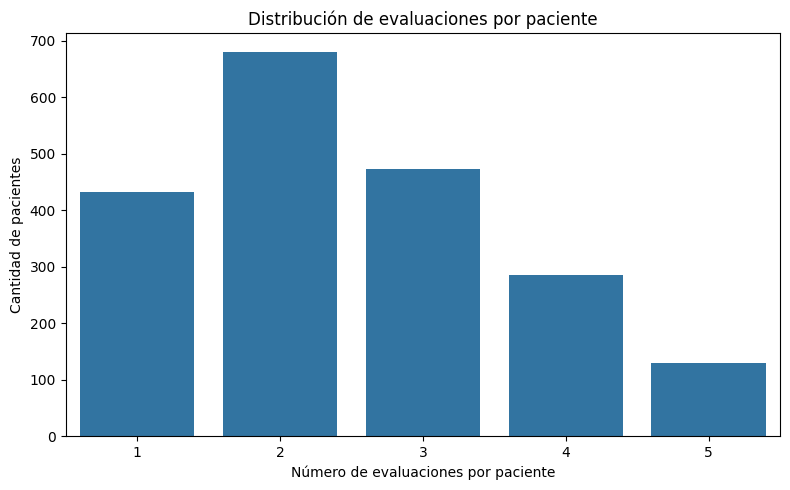

In [26]:
evaluaciones_por_paciente = df["paciente_id"].value_counts()

plt.figure(figsize=(8, 5))
sns.countplot(x=evaluaciones_por_paciente.values)
plt.title("Distribución de evaluaciones por paciente")
plt.xlabel("Número de evaluaciones por paciente")
plt.ylabel("Cantidad de pacientes")
plt.tight_layout()
plt.savefig("grafico_evaluaciones_por_paciente.png", dpi=300, bbox_inches="tight")
plt.show()

## Análisis de la Etapa 6

La revisión de duplicados y registros únicos muestra que el dataset no presenta registros completamente duplicados. Además, `evaluacion_id` no tiene duplicados, lo cual confirma que cada fila corresponde a una evaluación única.

En cambio, `paciente_id` sí aparece repetido en **3000 registros**, pero esto **no es un error**. Es coherente con la estructura del dataset, porque existen **2000 pacientes únicos** y **5000 evaluaciones**. Es decir, algunos pacientes fueron evaluados más de una vez.

La distribución de evaluaciones por paciente muestra que cada paciente tiene entre **1 y 5 evaluaciones**, con un promedio de **2.5 evaluaciones por paciente**. Además, **432 pacientes** tienen una sola evaluación, mientras que **1568 pacientes** tienen más de una evaluación. Esto confirma que el dataset permite representar seguimiento clínico en el tiempo.

Los ejemplos de pacientes con más evaluaciones muestran cambios en variables como `estadio`, `dolor`, `estado_nutricional`, `tratamiento_principal` y `nivel_prioridad`. Esto es importante porque demuestra que la prioridad de atención no es una variable fija, sino que puede cambiar según la evolución clínica y social del paciente.

Un punto importante para el modelado: como un mismo paciente puede aparecer varias veces, más adelante se debe tener cuidado al dividir los datos en entrenamiento y prueba. Si se hace una división aleatoria simple, el mismo paciente podría aparecer en ambos conjuntos y eso podría inflar artificialmente las métricas. Para una evaluación más estricta, se puede considerar una división por `paciente_id`.


## 7. Conversión y validación de fechas

In [27]:
df_eda = df.copy()

In [28]:
columnas_fechas = [
    "fecha_diagnostico",
    "fecha_ingreso_aldimi",
    "fecha_evaluacion"
]

# Convertir fechas SOLO en la copia
for col in columnas_fechas:
    df_eda[col] = pd.to_datetime(df_eda[col], errors="coerce")

print("--- TIPOS DE DATOS DESPUÉS DE CONVERTIR FECHAS EN df_eda ---")
print(df_eda[columnas_fechas].dtypes)

print("\n--- VALORES NULOS EN FECHAS DESPUÉS DE LA CONVERSIÓN ---")
print(df_eda[columnas_fechas].isnull().sum())

--- TIPOS DE DATOS DESPUÉS DE CONVERTIR FECHAS EN df_eda ---
fecha_diagnostico       datetime64[ns]
fecha_ingreso_aldimi    datetime64[ns]
fecha_evaluacion        datetime64[ns]
dtype: object

--- VALORES NULOS EN FECHAS DESPUÉS DE LA CONVERSIÓN ---
fecha_diagnostico       0
fecha_ingreso_aldimi    0
fecha_evaluacion        0
dtype: int64


In [29]:
print("--- RANGO TEMPORAL DE LAS FECHAS ---")

for_col = []

for col in columnas_fechas:
    print(f"{col}: {df_eda[col].min()} → {df_eda[col].max()}")

print("\n--- CANTIDAD DE FECHAS ÚNICAS ---")
for col in columnas_fechas:
    print(f"{col}: {df_eda[col].nunique()} fechas únicas")

--- RANGO TEMPORAL DE LAS FECHAS ---
fecha_diagnostico: 2025-01-01 00:00:00 → 2026-06-29 00:00:00
fecha_ingreso_aldimi: 2025-01-09 00:00:00 → 2026-09-05 00:00:00
fecha_evaluacion: 2025-01-13 00:00:00 → 2026-11-02 00:00:00

--- CANTIDAD DE FECHAS ÚNICAS ---
fecha_diagnostico: 527 fechas únicas
fecha_ingreso_aldimi: 571 fechas únicas
fecha_evaluacion: 629 fechas únicas


In [30]:
print("--- VALIDACIÓN DE ORDEN LÓGICO DE FECHAS ---")

eval_antes_diagnostico = (
    df_eda["fecha_evaluacion"] < df_eda["fecha_diagnostico"]
).sum()

ingreso_antes_diagnostico = (
    df_eda["fecha_ingreso_aldimi"] < df_eda["fecha_diagnostico"]
).sum()

eval_antes_ingreso = (
    df_eda["fecha_evaluacion"] < df_eda["fecha_ingreso_aldimi"]
).sum()

print("Evaluaciones antes del diagnóstico:", eval_antes_diagnostico)
print("Ingresos a ALDIMI antes del diagnóstico:", ingreso_antes_diagnostico)
print("Evaluaciones antes del ingreso a ALDIMI:", eval_antes_ingreso)

--- VALIDACIÓN DE ORDEN LÓGICO DE FECHAS ---
Evaluaciones antes del diagnóstico: 0
Ingresos a ALDIMI antes del diagnóstico: 0
Evaluaciones antes del ingreso a ALDIMI: 0


In [31]:
df_eda["dias_desde_diagnostico_calculado"] = (
    df_eda["fecha_evaluacion"] - df_eda["fecha_diagnostico"]
).dt.days

df_eda["dias_en_albergue_calculado"] = (
    df_eda["fecha_evaluacion"] - df_eda["fecha_ingreso_aldimi"]
).dt.days

print("--- VALIDACIÓN DE VARIABLES TEMPORALES DERIVADAS ---")

diff_diagnostico = (
    df_eda["dias_desde_diagnostico"] != df_eda["dias_desde_diagnostico_calculado"]
).sum()

diff_albergue = (
    df_eda["dias_en_albergue"] != df_eda["dias_en_albergue_calculado"]
).sum()

print("Diferencias en dias_desde_diagnostico:", diff_diagnostico)
print("Diferencias en dias_en_albergue:", diff_albergue)

--- VALIDACIÓN DE VARIABLES TEMPORALES DERIVADAS ---
Diferencias en dias_desde_diagnostico: 0
Diferencias en dias_en_albergue: 0


In [32]:
print("--- EJEMPLOS DE DIFERENCIAS SI EXISTEN ---")

diferencias_fechas = df_eda[
    (df_eda["dias_desde_diagnostico"] != df_eda["dias_desde_diagnostico_calculado"]) |
    (df_eda["dias_en_albergue"] != df_eda["dias_en_albergue_calculado"])
]

display(
    diferencias_fechas[
        [
            "paciente_id",
            "fecha_diagnostico",
            "fecha_ingreso_aldimi",
            "fecha_evaluacion",
            "dias_desde_diagnostico",
            "dias_desde_diagnostico_calculado",
            "dias_en_albergue",
            "dias_en_albergue_calculado"
        ]
    ].head(20)
)

--- EJEMPLOS DE DIFERENCIAS SI EXISTEN ---


,paciente_id,fecha_diagnostico,fecha_ingreso_aldimi,fecha_evaluacion,dias_desde_diagnostico,dias_desde_diagnostico_calculado,dias_en_albergue,dias_en_albergue_calculado


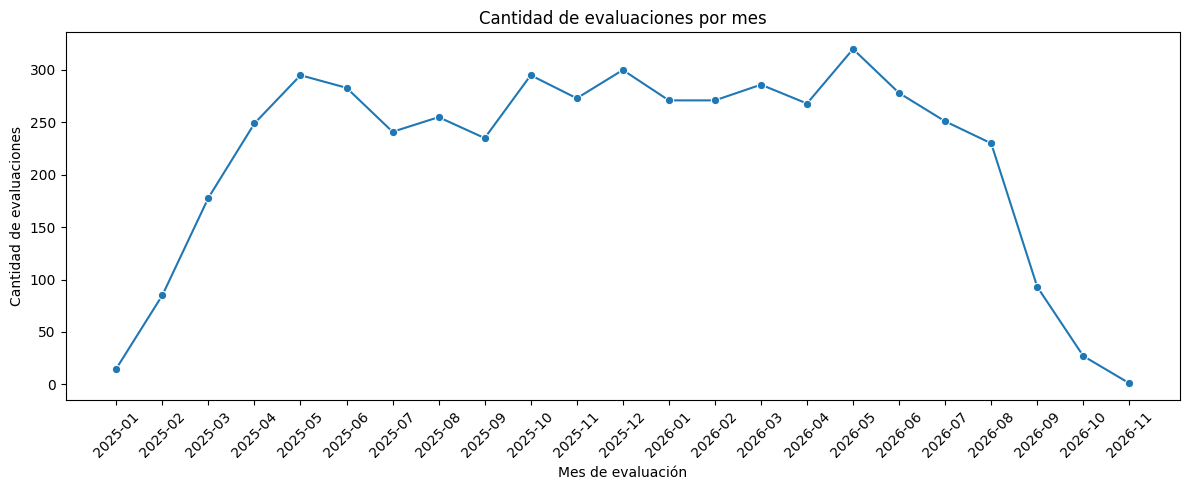

In [33]:
# Crear columna de mes SOLO en df_eda
df_eda["mes_evaluacion"] = df_eda["fecha_evaluacion"].dt.to_period("M").astype(str)

evaluaciones_por_mes = (
    df_eda.groupby("mes_evaluacion")
    .size()
    .reset_index(name="cantidad_evaluaciones")
)

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=evaluaciones_por_mes,
    x="mes_evaluacion",
    y="cantidad_evaluaciones",
    marker="o"
)
plt.title("Cantidad de evaluaciones por mes")
plt.xlabel("Mes de evaluación")
plt.ylabel("Cantidad de evaluaciones")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("grafico_evaluaciones_por_mes.png", dpi=300, bbox_inches="tight")
plt.show()

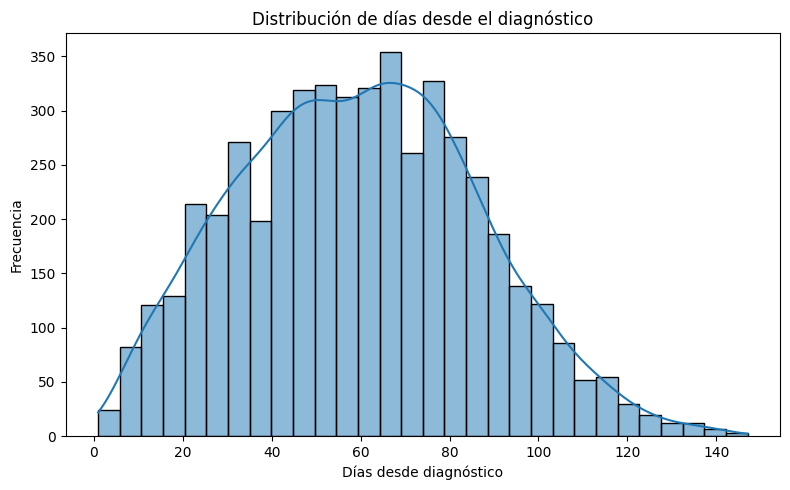

In [34]:
plt.figure(figsize=(8, 5))
sns.histplot(df_eda["dias_desde_diagnostico"], bins=30, kde=True)
plt.title("Distribución de días desde el diagnóstico")
plt.xlabel("Días desde diagnóstico")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.savefig("grafico_dias_desde_diagnostico.png", dpi=300, bbox_inches="tight")
plt.show()

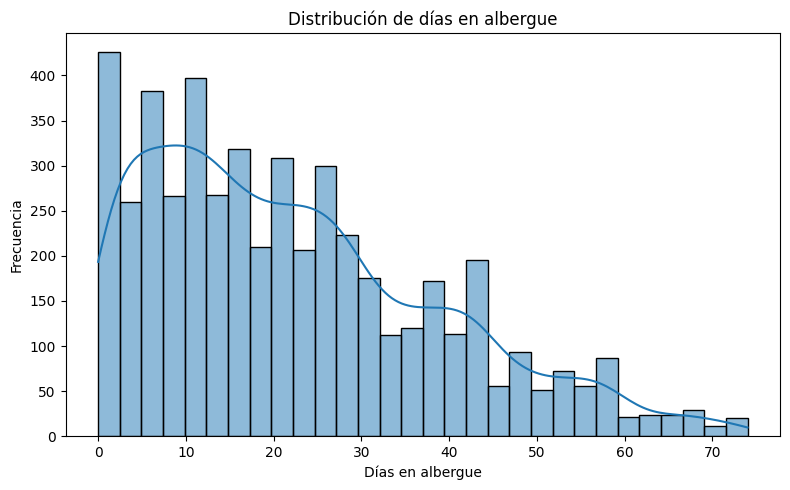

In [35]:
plt.figure(figsize=(8, 5))
sns.histplot(df_eda["dias_en_albergue"], bins=30, kde=True)
plt.title("Distribución de días en albergue")
plt.xlabel("Días en albergue")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.savefig("grafico_dias_en_albergue.png", dpi=300, bbox_inches="tight")
plt.show()

## Análisis de la Etapa 7

Las tres columnas de fecha fueron convertidas correctamente a formato `datetime64[ns]` y no se generaron valores nulos después de la conversión. Esto confirma que las fechas estaban bien registradas y que pueden usarse para análisis temporal.

El rango temporal es coherente:

| Fecha                  | Rango                   |
| ---------------------- | ----------------------- |
| `fecha_diagnostico`    | 2025-01-01 → 2026-06-29 |
| `fecha_ingreso_aldimi` | 2025-01-09 → 2026-09-05 |
| `fecha_evaluacion`     | 2025-01-13 → 2026-11-02 |

También se validó el orden lógico de las fechas. No existen evaluaciones antes del diagnóstico, ingresos a ALDIMI antes del diagnóstico ni evaluaciones antes del ingreso a ALDIMI. Eso es muy importante porque demuestra consistencia temporal.

Además, las variables calculadas `dias_desde_diagnostico` y `dias_en_albergue` coinciden exactamente con las diferencias entre fechas. No hubo ninguna diferencia, por lo que esas variables derivadas son confiables.

Sobre los gráficos:

El gráfico de **evaluaciones por mes** muestra una cobertura temporal amplia desde enero de 2025 hasta noviembre de 2026. La parte central del periodo presenta mayor estabilidad, mientras que los primeros y últimos meses tienen menos evaluaciones porque corresponden al inicio y cierre del rango de simulación.

El histograma de **días desde diagnóstico** muestra que la mayoría de evaluaciones ocurren aproximadamente entre 40 y 80 días después del diagnóstico, con una distribución razonable y sin valores negativos.

El histograma de **días en albergue** muestra una mayor concentración en los primeros días de estancia, especialmente entre 0 y 30 días, con una disminución progresiva hacia estancias más largas. Esto es coherente con un contexto de alojamiento temporal y seguimiento de pacientes.



## 8. Análisis univariado de variables de identificación y tiempo

In [36]:
columnas_fechas = [
    "fecha_diagnostico",
    "fecha_ingreso_aldimi",
    "fecha_evaluacion"
]

for col in columnas_fechas:
    df_eda[col] = pd.to_datetime(df_eda[col], errors="coerce")

print("--- IDENTIFICADORES ---")
print("Total de evaluaciones:", df_eda["evaluacion_id"].nunique())
print("Total de pacientes:", df_eda["paciente_id"].nunique())
print("Registros totales:", df_eda.shape[0])

print("\n--- EVALUACIONES POR PACIENTE ---")
evaluaciones_por_paciente = df_eda["paciente_id"].value_counts()
print(evaluaciones_por_paciente.describe())

print("\nDistribución de evaluaciones por paciente:")
print(evaluaciones_por_paciente.value_counts().sort_index())

print("\n--- VARIABLES TEMPORALES NUMÉRICAS ---")
variables_tiempo = ["dias_desde_diagnostico", "dias_en_albergue"]
display(df_eda[variables_tiempo].describe())

--- IDENTIFICADORES ---
Total de evaluaciones: 5000
Total de pacientes: 2000
Registros totales: 5000

--- EVALUACIONES POR PACIENTE ---
count    2000.000000
mean        2.500000
std         1.164336
min         1.000000
25%         2.000000
50%         2.000000
75%         3.000000
max         5.000000
Name: count, dtype: float64

Distribución de evaluaciones por paciente:
count
1    432
2    680
3    473
4    286
5    129
Name: count, dtype: int64

--- VARIABLES TEMPORALES NUMÉRICAS ---


,dias_desde_diagnostico,dias_en_albergue
count,5000.000000,5000.000000
mean,59.632800,22.274200
std,26.857979,16.605016
min,1.000000,0.000000
25%,40.000000,9.000000
50%,60.000000,19.000000
75%,78.000000,33.000000
max,147.000000,74.000000


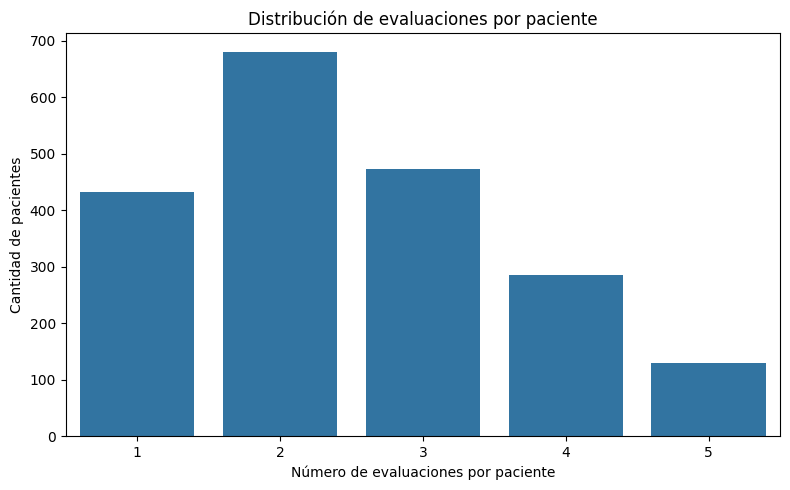

In [37]:
plt.figure(figsize=(8, 5))
sns.countplot(x=evaluaciones_por_paciente.values)
plt.title("Distribución de evaluaciones por paciente")
plt.xlabel("Número de evaluaciones por paciente")
plt.ylabel("Cantidad de pacientes")
plt.tight_layout()
plt.savefig("eda_08_evaluaciones_por_paciente.png", dpi=300, bbox_inches="tight")
plt.show()

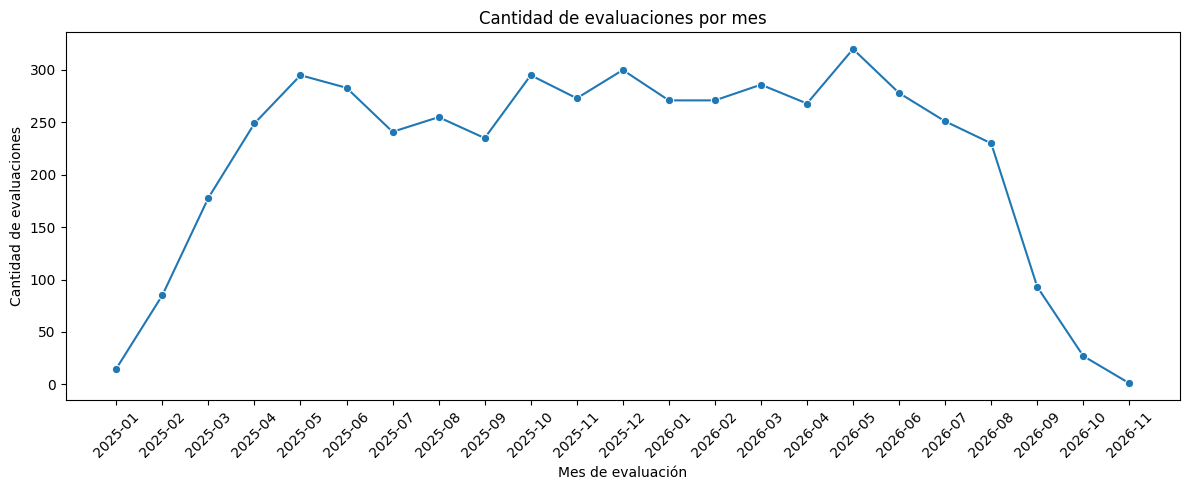

In [38]:
df_eda["mes_evaluacion"] = df_eda["fecha_evaluacion"].dt.to_period("M").astype(str)

evaluaciones_por_mes = (
    df_eda.groupby("mes_evaluacion")
    .size()
    .reset_index(name="cantidad_evaluaciones")
)

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=evaluaciones_por_mes,
    x="mes_evaluacion",
    y="cantidad_evaluaciones",
    marker="o"
)
plt.title("Cantidad de evaluaciones por mes")
plt.xlabel("Mes de evaluación")
plt.ylabel("Cantidad de evaluaciones")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("eda_08_evaluaciones_por_mes.png", dpi=300, bbox_inches="tight")
plt.show()

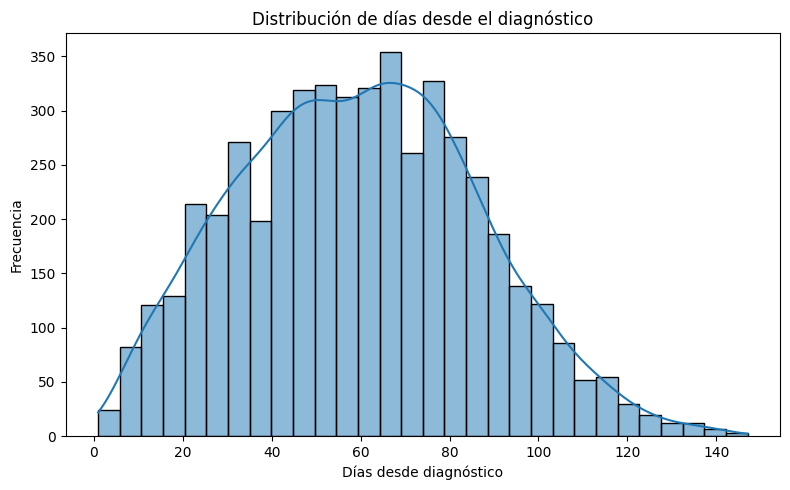

In [39]:
plt.figure(figsize=(8, 5))
sns.histplot(df_eda["dias_desde_diagnostico"], bins=30, kde=True)
plt.title("Distribución de días desde el diagnóstico")
plt.xlabel("Días desde diagnóstico")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.savefig("eda_08_dias_desde_diagnostico.png", dpi=300, bbox_inches="tight")
plt.show()

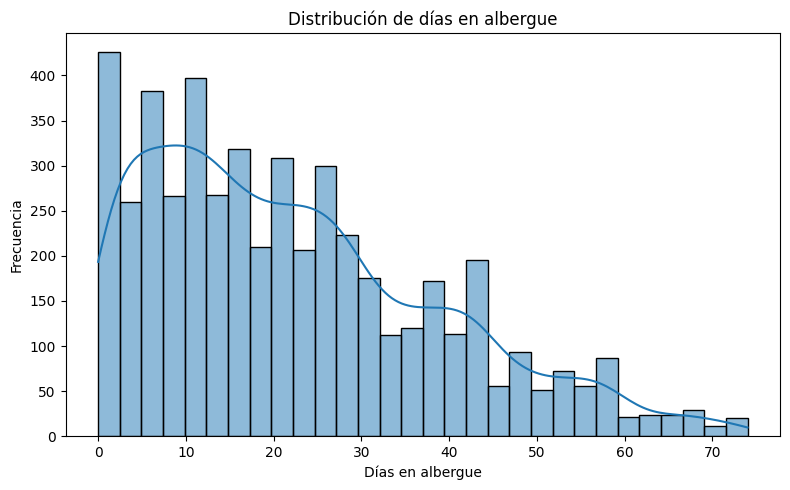

In [40]:
plt.figure(figsize=(8, 5))
sns.histplot(df_eda["dias_en_albergue"], bins=30, kde=True)
plt.title("Distribución de días en albergue")
plt.xlabel("Días en albergue")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.savefig("eda_08_dias_en_albergue.png", dpi=300, bbox_inches="tight")
plt.show()

## Análisis de la Etapa 8

El dataset contiene 5000 evaluaciones correspondientes a 2000 pacientes únicos, lo cual confirma que la unidad de análisis principal es la evaluación clínica/social, no el paciente individual. Esto es importante porque un mismo paciente puede aparecer varias veces a lo largo del tiempo.

La distribución de evaluaciones por paciente muestra que la mayoría tiene entre 1 y 3 evaluaciones. En promedio, cada paciente tiene 2.5 evaluaciones, con un máximo de 5 evaluaciones por paciente. Esto permite representar seguimiento clínico, cambios en síntomas, tratamientos y nivel de prioridad.

Respecto a las variables temporales, dias_desde_diagnostico tiene una media de 59.63 días, con valores entre 1 y 147 días. Esto indica que las evaluaciones se concentran principalmente en los primeros meses posteriores al diagnóstico. Por otro lado, dias_en_albergue tiene una media de 22.27 días, con valores entre 0 y 74 días, lo cual es coherente con una dinámica de acompañamiento temporal en ALDIMI.

El gráfico de evaluaciones por mes muestra una cobertura amplia desde enero de 2025 hasta noviembre de 2026. Se observa una menor cantidad de evaluaciones al inicio y al final del periodo, lo cual es esperable por tratarse de los extremos del rango temporal del dataset.

## 9. Análisis univariado de variables demográficas y sociales

In [41]:
variables_demograficas_sociales = [
    "edad",
    "grupo_edad",
    "sexo",
    "region_procedencia",
    "zona_procedencia",
    "viaja_desde_provincia",
    "acompanante",
    "nivel_vulnerabilidad",
    "dificultad_acceso_salud"
]

print("--- VARIABLES DEMOGRÁFICAS Y SOCIALES ---")
print(variables_demograficas_sociales)

--- VARIABLES DEMOGRÁFICAS Y SOCIALES ---
['edad', 'grupo_edad', 'sexo', 'region_procedencia', 'zona_procedencia', 'viaja_desde_provincia', 'acompanante', 'nivel_vulnerabilidad', 'dificultad_acceso_salud']


In [42]:
print("--- RESUMEN DE EDAD ---")
display(df_eda[["edad"]].describe())

--- RESUMEN DE EDAD ---


,edad
count,5000.000000
mean,58.563800
std,18.422144
min,15.000000
25%,45.000000
50%,63.000000
75%,72.000000
max,90.000000


In [43]:
def tabla_frecuencia(df, columna):
    tabla = df[columna].value_counts(dropna=False).reset_index()
    tabla.columns = [columna, "frecuencia"]
    tabla["porcentaje"] = (tabla["frecuencia"] / len(df) * 100).round(2)
    return tabla

variables_sociales_categoricas = [
    "grupo_edad",
    "sexo",
    "region_procedencia",
    "zona_procedencia",
    "viaja_desde_provincia",
    "acompanante",
    "nivel_vulnerabilidad",
    "dificultad_acceso_salud"
]

for col in variables_sociales_categoricas:
    print(f"\n--- Frecuencia de {col} ---")
    display(tabla_frecuencia(df_eda, col))


--- Frecuencia de grupo_edad ---


,grupo_edad,frecuencia,porcentaje
0,adulto_mayor,2931,58.62
1,adulto,1126,22.52
2,adulto_joven,861,17.22
3,nino_adolescente,82,1.64



--- Frecuencia de sexo ---


,sexo,frecuencia,porcentaje
0,masculino,2617,52.34
1,femenino,2383,47.66



--- Frecuencia de region_procedencia ---


...

,acompanante,frecuencia,porcentaje
0,si,4227,84.54
1,no,773,15.46



--- Frecuencia de nivel_vulnerabilidad ---


,nivel_vulnerabilidad,frecuencia,porcentaje
0,alto,2517,50.34
1,muy_alto,1270,25.40
2,medio,1213,24.26



--- Frecuencia de dificultad_acceso_salud ---


,dificultad_acceso_salud,frecuencia,porcentaje
0,alta,2231,44.62
1,media,2081,41.62
2,baja,688,13.76


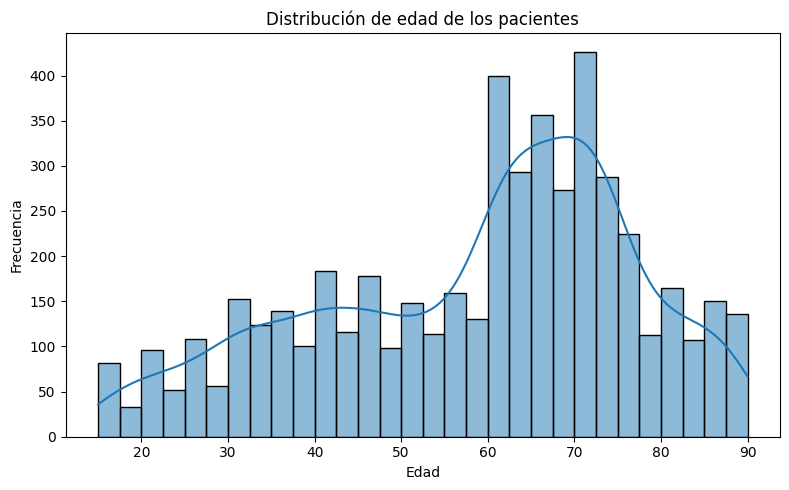

In [44]:
plt.figure(figsize=(8, 5))
sns.histplot(df_eda["edad"], bins=30, kde=True)
plt.title("Distribución de edad de los pacientes")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.savefig("eda_09_distribucion_edad.png", dpi=300, bbox_inches="tight")
plt.show()

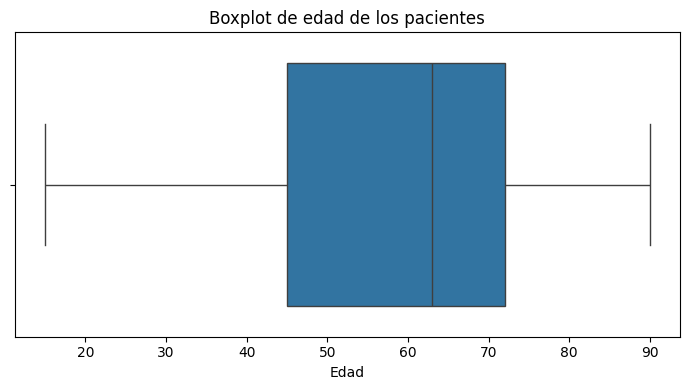

In [45]:
plt.figure(figsize=(7, 4))
sns.boxplot(x=df_eda["edad"])
plt.title("Boxplot de edad de los pacientes")
plt.xlabel("Edad")
plt.tight_layout()
plt.savefig("eda_09_boxplot_edad.png", dpi=300, bbox_inches="tight")
plt.show()

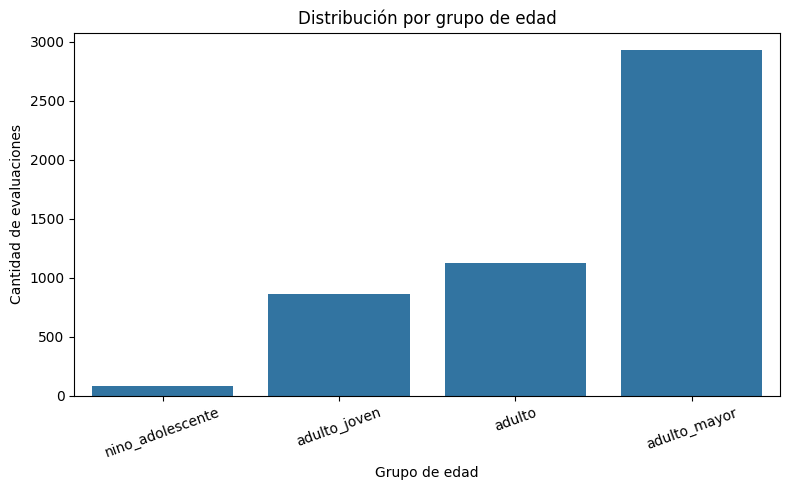

In [46]:
orden_grupo_edad = ["nino_adolescente", "adulto_joven", "adulto", "adulto_mayor"]

plt.figure(figsize=(8, 5))
sns.countplot(
    data=df_eda,
    x="grupo_edad",
    order=orden_grupo_edad
)
plt.title("Distribución por grupo de edad")
plt.xlabel("Grupo de edad")
plt.ylabel("Cantidad de evaluaciones")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("eda_09_grupo_edad.png", dpi=300, bbox_inches="tight")
plt.show()

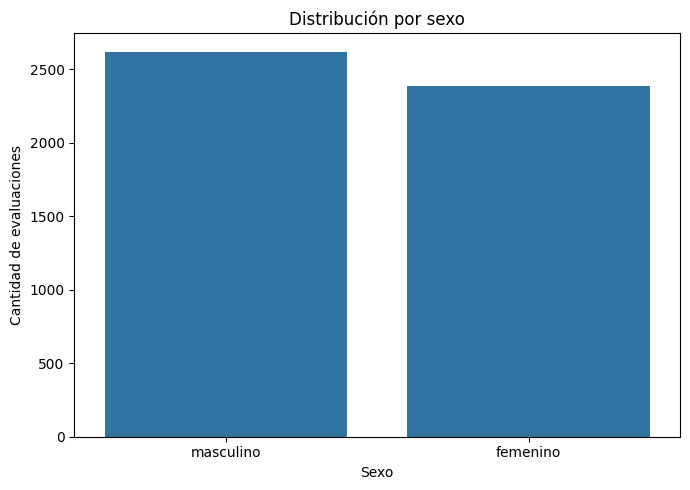

In [47]:
plt.figure(figsize=(7, 5))
sns.countplot(
    data=df_eda,
    x="sexo",
    order=df_eda["sexo"].value_counts().index
)
plt.title("Distribución por sexo")
plt.xlabel("Sexo")
plt.ylabel("Cantidad de evaluaciones")
plt.tight_layout()
plt.savefig("eda_09_sexo.png", dpi=300, bbox_inches="tight")
plt.show()

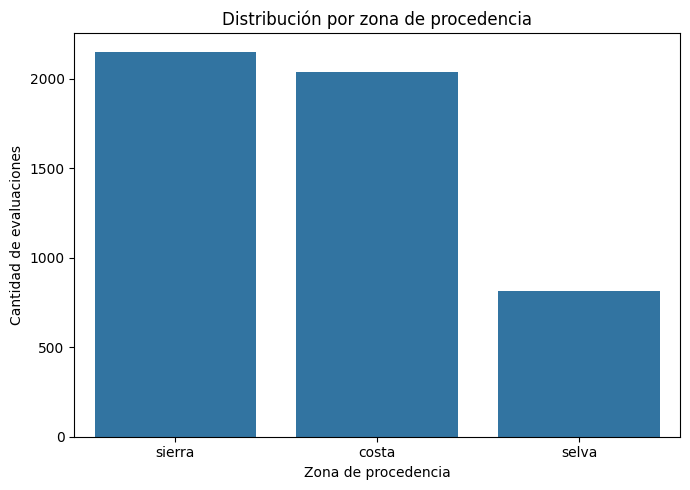

In [48]:
plt.figure(figsize=(7, 5))
sns.countplot(
    data=df_eda,
    x="zona_procedencia",
    order=df_eda["zona_procedencia"].value_counts().index
)
plt.title("Distribución por zona de procedencia")
plt.xlabel("Zona de procedencia")
plt.ylabel("Cantidad de evaluaciones")
plt.tight_layout()
plt.savefig("eda_09_zona_procedencia.png", dpi=300, bbox_inches="tight")
plt.show()

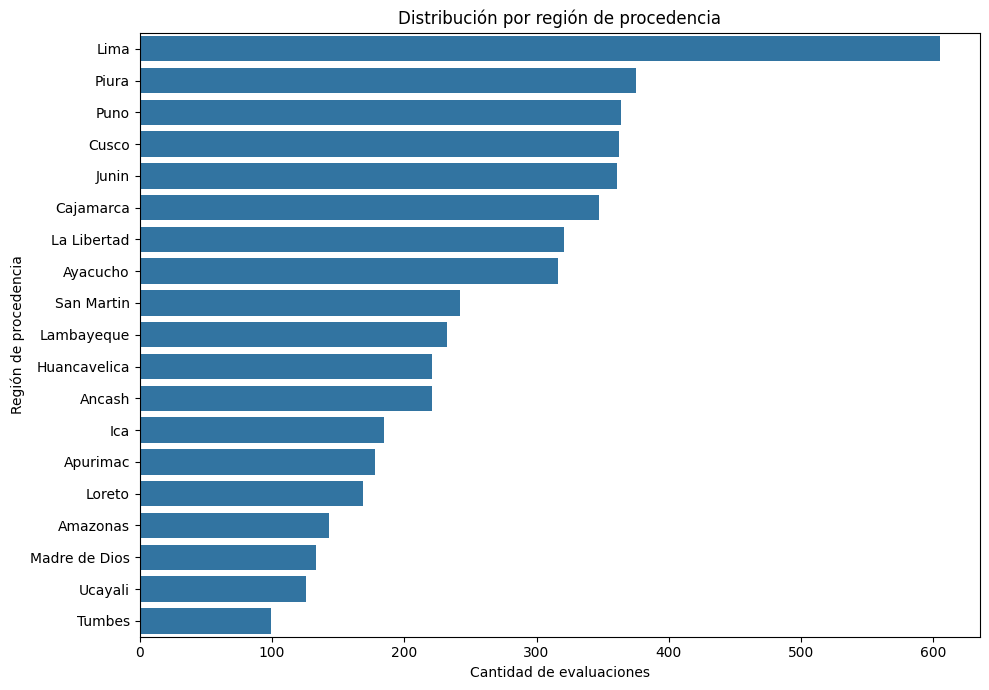

In [49]:
region_counts = df_eda["region_procedencia"].value_counts().reset_index()
region_counts.columns = ["region_procedencia", "frecuencia"]

plt.figure(figsize=(10, 7))
sns.barplot(
    data=region_counts,
    y="region_procedencia",
    x="frecuencia"
)
plt.title("Distribución por región de procedencia")
plt.xlabel("Cantidad de evaluaciones")
plt.ylabel("Región de procedencia")
plt.tight_layout()
plt.savefig("eda_09_region_procedencia.png", dpi=300, bbox_inches="tight")
plt.show()

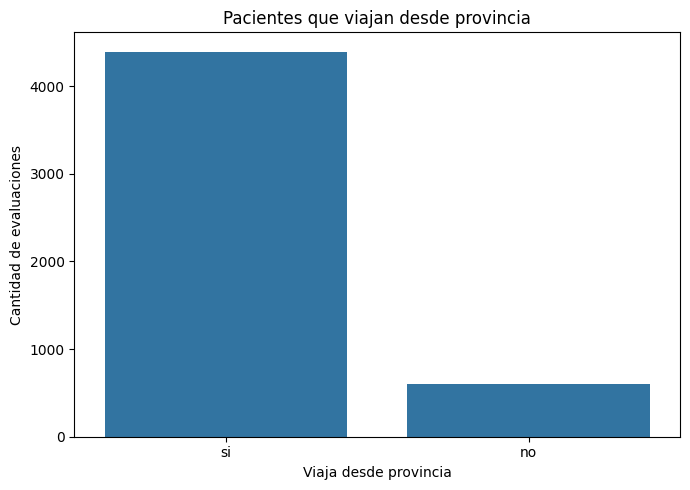

In [50]:
plt.figure(figsize=(7, 5))
sns.countplot(
    data=df_eda,
    x="viaja_desde_provincia",
    order=df_eda["viaja_desde_provincia"].value_counts().index
)
plt.title("Pacientes que viajan desde provincia")
plt.xlabel("Viaja desde provincia")
plt.ylabel("Cantidad de evaluaciones")
plt.tight_layout()
plt.savefig("eda_09_viaja_desde_provincia.png", dpi=300, bbox_inches="tight")
plt.show()

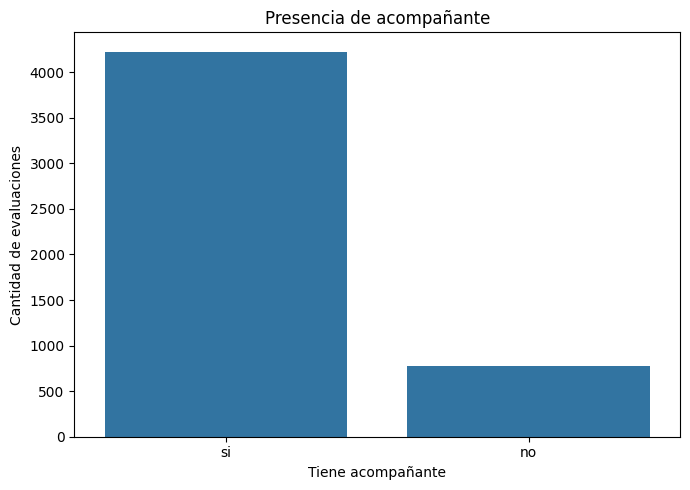

In [51]:
plt.figure(figsize=(7, 5))
sns.countplot(
    data=df_eda,
    x="acompanante",
    order=df_eda["acompanante"].value_counts().index
)
plt.title("Presencia de acompañante")
plt.xlabel("Tiene acompañante")
plt.ylabel("Cantidad de evaluaciones")
plt.tight_layout()
plt.savefig("eda_09_acompanante.png", dpi=300, bbox_inches="tight")
plt.show()

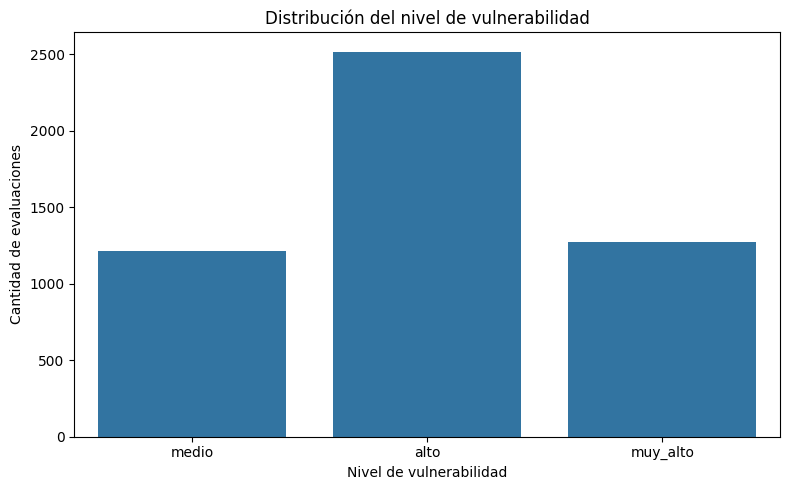

In [52]:
orden_vulnerabilidad = ["medio", "alto", "muy_alto"]

plt.figure(figsize=(8, 5))
sns.countplot(
    data=df_eda,
    x="nivel_vulnerabilidad",
    order=orden_vulnerabilidad
)
plt.title("Distribución del nivel de vulnerabilidad")
plt.xlabel("Nivel de vulnerabilidad")
plt.ylabel("Cantidad de evaluaciones")
plt.tight_layout()
plt.savefig("eda_09_nivel_vulnerabilidad.png", dpi=300, bbox_inches="tight")
plt.show()

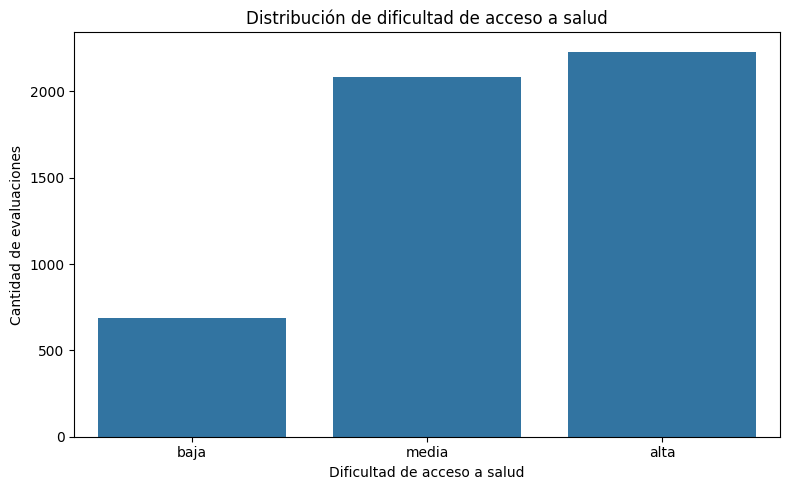

In [53]:
orden_acceso = ["baja", "media", "alta"]

plt.figure(figsize=(8, 5))
sns.countplot(
    data=df_eda,
    x="dificultad_acceso_salud",
    order=orden_acceso
)
plt.title("Distribución de dificultad de acceso a salud")
plt.xlabel("Dificultad de acceso a salud")
plt.ylabel("Cantidad de evaluaciones")
plt.tight_layout()
plt.savefig("eda_09_dificultad_acceso_salud.png", dpi=300, bbox_inches="tight")
plt.show()

## Análisis de la Etapa 9

El análisis univariado de las variables demográficas y sociales muestra que el dataset está compuesto principalmente por pacientes adultos y adultos mayores. La edad promedio es de 58.56 años, con una mediana de 63 años, un mínimo de 15 y un máximo de 90 años. Esto es coherente con el contexto del cáncer gástrico, ya que suele presentarse con mayor frecuencia en población adulta y adulta mayor.

En la variable grupo_edad, predomina el grupo adulto_mayor, con 2931 evaluaciones, equivalente al 58.62% del dataset. Luego aparecen los adultos con 22.52%, adultos jóvenes con 17.22% y niños/adolescentes con 1.64%. Esto confirma que la mayor parte de las evaluaciones corresponde a pacientes de edad avanzada.

Respecto al sexo, la distribución es relativamente equilibrada, aunque con ligera mayoría masculina: 52.34% masculino y 47.66% femenino. Esta distribución permite que el modelo no dependa de una sola categoría dominante en la variable sexo.

En cuanto a procedencia, la mayoría de evaluaciones corresponde a pacientes de la sierra con 42.98%, seguida por la costa con 40.76% y la selva con 16.26%. A nivel regional, Lima aparece con la mayor frecuencia individual (12.10%), seguida por regiones como Piura, Puno, Cusco, Junín, Cajamarca, La Libertad y Ayacucho. Esto refleja una población diversa a nivel territorial.

Un hallazgo importante es que el 87.9% de las evaluaciones corresponde a pacientes que viajan desde provincia. Esto es muy relevante para el proyecto, porque refuerza la necesidad de ALDIMI como organización de apoyo para pacientes que deben desplazarse hacia Lima para recibir atención oncológica.

También se observa que el 84.54% de las evaluaciones corresponde a pacientes con acompañante. Esto tiene sentido en un contexto oncológico, ya que muchos pacientes requieren apoyo familiar o asistencia durante el tratamiento y la estancia en el albergue.

En relación con las variables sociales, el nivel de vulnerabilidad es predominantemente alto: 50.34% presenta vulnerabilidad alto y 25.40% vulnerabilidad muy_alto. Es decir, más del 75% del dataset se concentra en niveles elevados de vulnerabilidad. De forma similar, la dificultad de acceso a salud se concentra en categorías alta y media, con 44.62% y 41.62%, respectivamente. Esto confirma que el dataset representa una población con barreras importantes de acceso y condiciones sociales complejas.


## 10. Análisis univariado de variables clínico-oncológicas

In [54]:
variables_clinico_oncologicas = [
    "tipo_cancer",
    "tipo_histologico",
    "estadio",
    "grado_histologico",
    "profundidad_tumor",
    "ganglios_afectados",
    "metastasis",
    "sitio_metastasis"
]

print("--- VARIABLES CLÍNICO-ONCOLÓGICAS ---")
print(variables_clinico_oncologicas)

--- VARIABLES CLÍNICO-ONCOLÓGICAS ---
['tipo_cancer', 'tipo_histologico', 'estadio', 'grado_histologico', 'profundidad_tumor', 'ganglios_afectados', 'metastasis', 'sitio_metastasis']


In [55]:
def tabla_frecuencia(df, columna):
    tabla = df[columna].value_counts(dropna=False).reset_index()
    tabla.columns = [columna, "frecuencia"]
    tabla["porcentaje"] = (tabla["frecuencia"] / len(df) * 100).round(2)
    return tabla

variables_clinicas_categoricas = [
    "tipo_cancer",
    "tipo_histologico",
    "estadio",
    "grado_histologico",
    "profundidad_tumor",
    "metastasis",
    "sitio_metastasis"
]

for col in variables_clinicas_categoricas:
    print(f"\n--- Frecuencia de {col} ---")
    display(tabla_frecuencia(df_eda, col))


--- Frecuencia de tipo_cancer ---


,tipo_cancer,frecuencia,porcentaje
0,cancer_gastrico,5000,100.0



--- Frecuencia de tipo_histologico ---


,tipo_histologico,frecuencia,porcentaje
0,adenocarcinoma_intestinal,2467,49.34
1,adenocarcinoma_difuso,1753,35.06
2,adenocarcinoma_mixto,538,10.76
3,otro,242,4.84



--- Frecuencia de estadio ---


...

,profundidad_tumor,frecuencia,porcentaje
0,muscular,1335,26.70
1,serosa,1282,25.64
2,submucosa,756,15.12
3,mucosa,738,14.76
4,invasion_local,637,12.74
5,enfermedad_diseminada,252,5.04



--- Frecuencia de metastasis ---


,metastasis,frecuencia,porcentaje
0,no,4447,88.94
1,si,553,11.06



--- Frecuencia de sitio_metastasis ---


,sitio_metastasis,frecuencia,porcentaje
0,ninguno,4394,87.88
1,higado,190,3.80
2,peritoneo,186,3.72
3,multiple,107,2.14
4,pulmon,62,1.24
5,NaN,61,1.22


In [56]:
print("--- RESUMEN DE GANGLIOS AFECTADOS ---")
display(df_eda[["ganglios_afectados"]].describe())

--- RESUMEN DE GANGLIOS AFECTADOS ---


,ganglios_afectados
count,5000.000000
mean,3.608000
std,4.224441
min,0.000000
25%,0.000000
50%,2.000000
75%,6.000000
max,17.000000


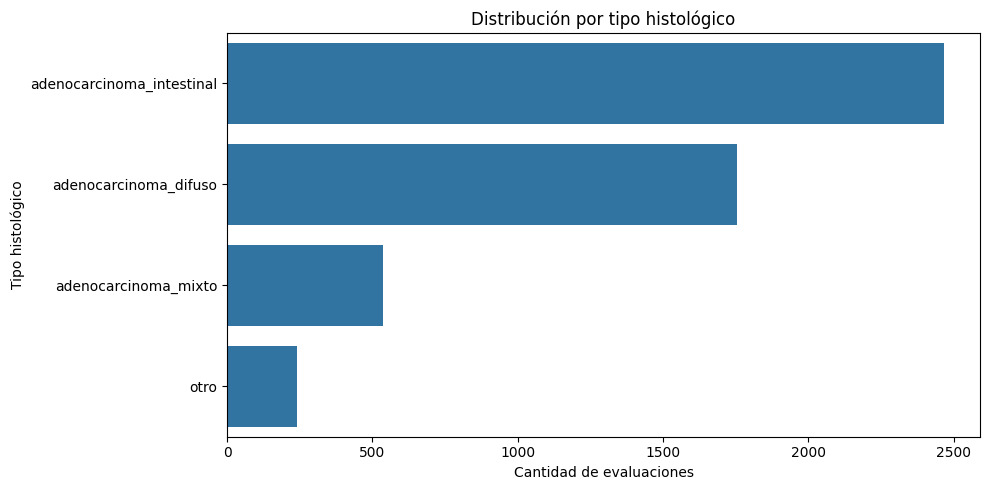

In [57]:
plt.figure(figsize=(10, 5))
sns.countplot(
    data=df_eda,
    y="tipo_histologico",
    order=df_eda["tipo_histologico"].value_counts().index
)
plt.title("Distribución por tipo histológico")
plt.xlabel("Cantidad de evaluaciones")
plt.ylabel("Tipo histológico")
plt.tight_layout()
plt.savefig("eda_10_tipo_histologico.png", dpi=300, bbox_inches="tight")
plt.show()

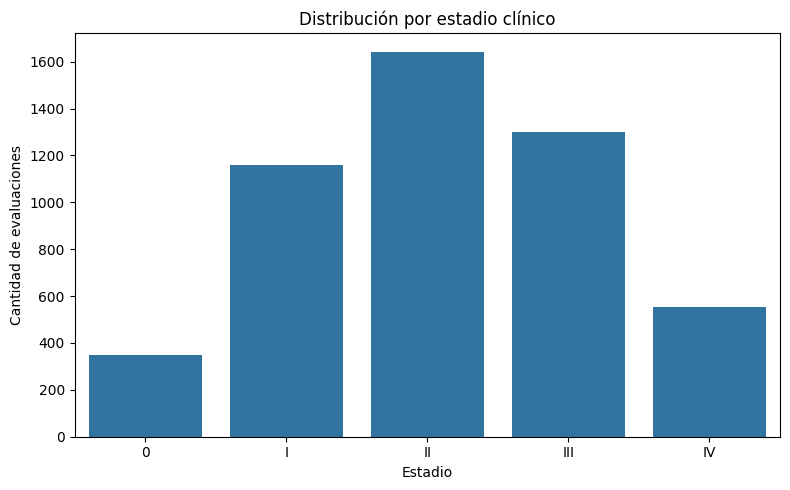

In [58]:
orden_estadio = ["0", "I", "II", "III", "IV"]

plt.figure(figsize=(8, 5))
sns.countplot(
    data=df_eda,
    x="estadio",
    order=orden_estadio
)
plt.title("Distribución por estadio clínico")
plt.xlabel("Estadio")
plt.ylabel("Cantidad de evaluaciones")
plt.tight_layout()
plt.savefig("eda_10_estadio.png", dpi=300, bbox_inches="tight")
plt.show()

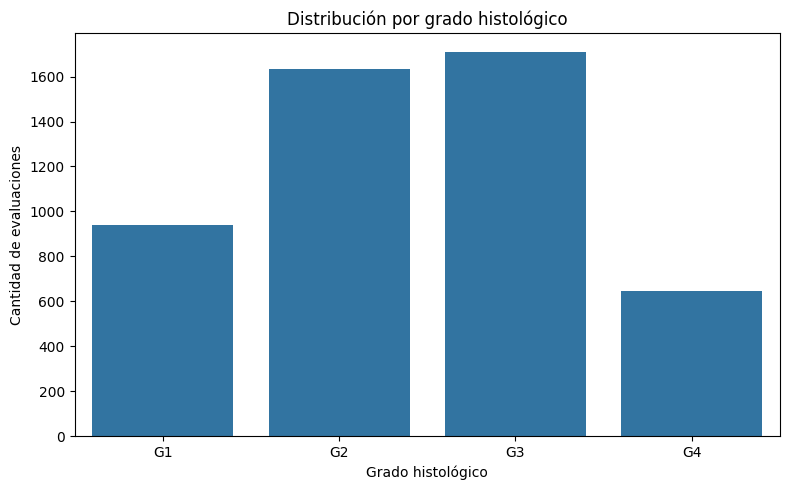

In [59]:
orden_grado = ["G1", "G2", "G3", "G4"]

plt.figure(figsize=(8, 5))
sns.countplot(
    data=df_eda,
    x="grado_histologico",
    order=orden_grado
)
plt.title("Distribución por grado histológico")
plt.xlabel("Grado histológico")
plt.ylabel("Cantidad de evaluaciones")
plt.tight_layout()
plt.savefig("eda_10_grado_histologico.png", dpi=300, bbox_inches="tight")
plt.show()

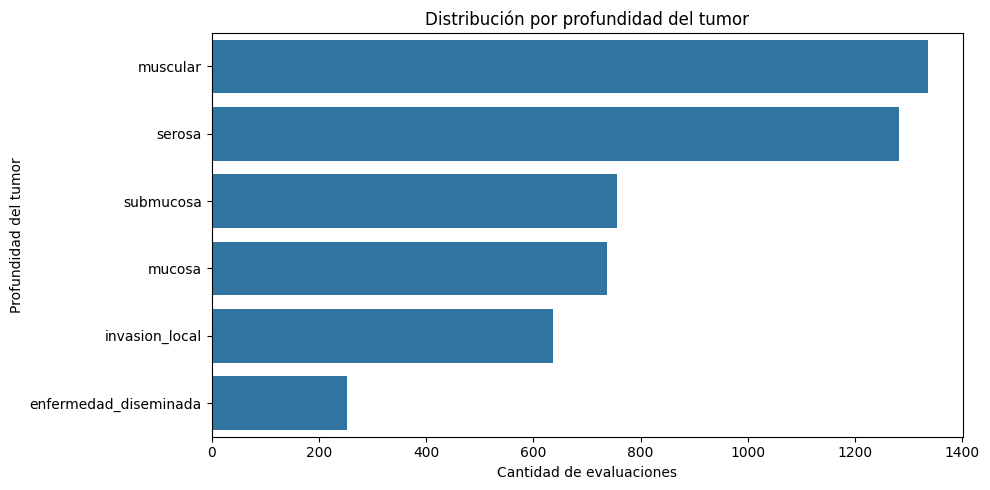

In [60]:
plt.figure(figsize=(10, 5))
sns.countplot(
    data=df_eda,
    y="profundidad_tumor",
    order=df_eda["profundidad_tumor"].value_counts().index
)
plt.title("Distribución por profundidad del tumor")
plt.xlabel("Cantidad de evaluaciones")
plt.ylabel("Profundidad del tumor")
plt.tight_layout()
plt.savefig("eda_10_profundidad_tumor.png", dpi=300, bbox_inches="tight")
plt.show()

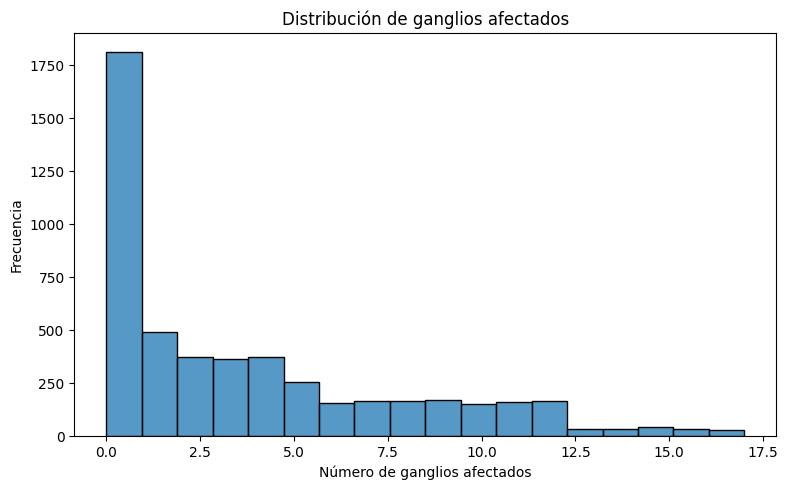

In [61]:
plt.figure(figsize=(8, 5))
sns.histplot(df_eda["ganglios_afectados"], bins=18, kde=False)
plt.title("Distribución de ganglios afectados")
plt.xlabel("Número de ganglios afectados")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.savefig("eda_10_ganglios_afectados.png", dpi=300, bbox_inches="tight")
plt.show()

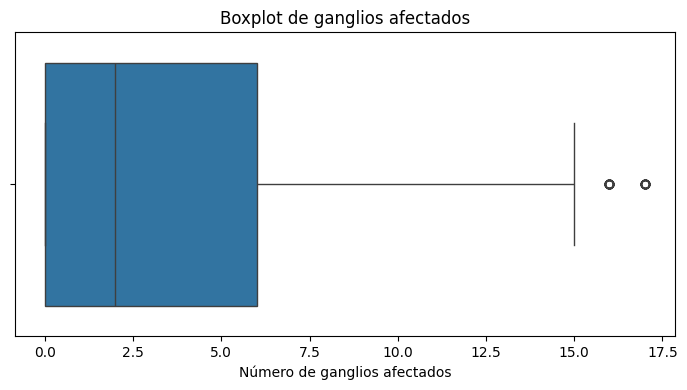

In [62]:
plt.figure(figsize=(7, 4))
sns.boxplot(x=df_eda["ganglios_afectados"])
plt.title("Boxplot de ganglios afectados")
plt.xlabel("Número de ganglios afectados")
plt.tight_layout()
plt.savefig("eda_10_boxplot_ganglios_afectados.png", dpi=300, bbox_inches="tight")
plt.show()

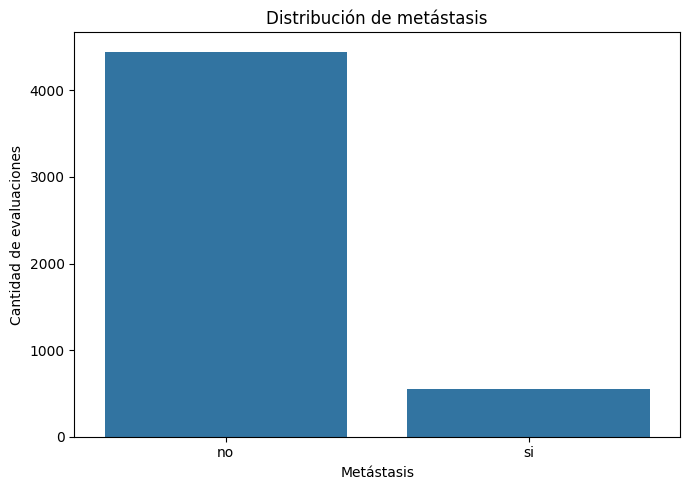

In [63]:
plt.figure(figsize=(7, 5))
sns.countplot(
    data=df_eda,
    x="metastasis",
    order=df_eda["metastasis"].value_counts().index
)
plt.title("Distribución de metástasis")
plt.xlabel("Metástasis")
plt.ylabel("Cantidad de evaluaciones")
plt.tight_layout()
plt.savefig("eda_10_metastasis.png", dpi=300, bbox_inches="tight")
plt.show()

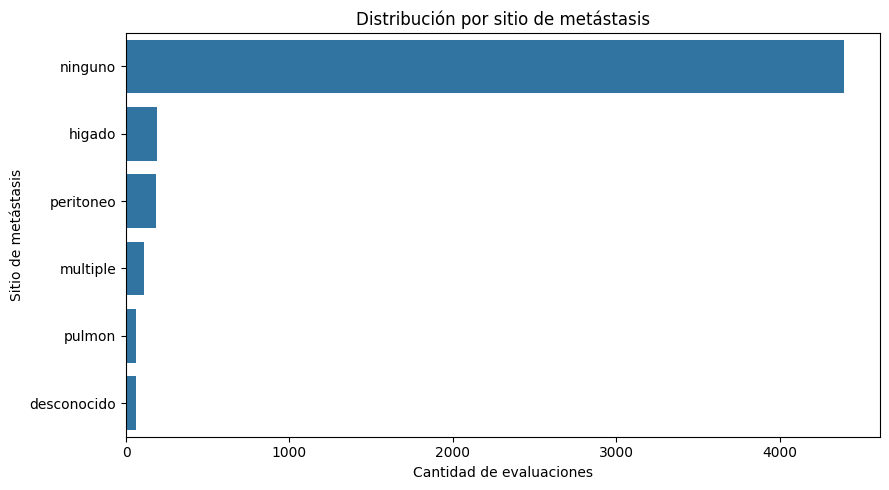

In [64]:
df_eda["sitio_metastasis_grafico"] = df_eda["sitio_metastasis"].fillna("desconocido")

plt.figure(figsize=(9, 5))
sns.countplot(
    data=df_eda,
    y="sitio_metastasis_grafico",
    order=df_eda["sitio_metastasis_grafico"].value_counts().index
)
plt.title("Distribución por sitio de metástasis")
plt.xlabel("Cantidad de evaluaciones")
plt.ylabel("Sitio de metástasis")
plt.tight_layout()
plt.savefig("eda_10_sitio_metastasis.png", dpi=300, bbox_inches="tight")
plt.show()

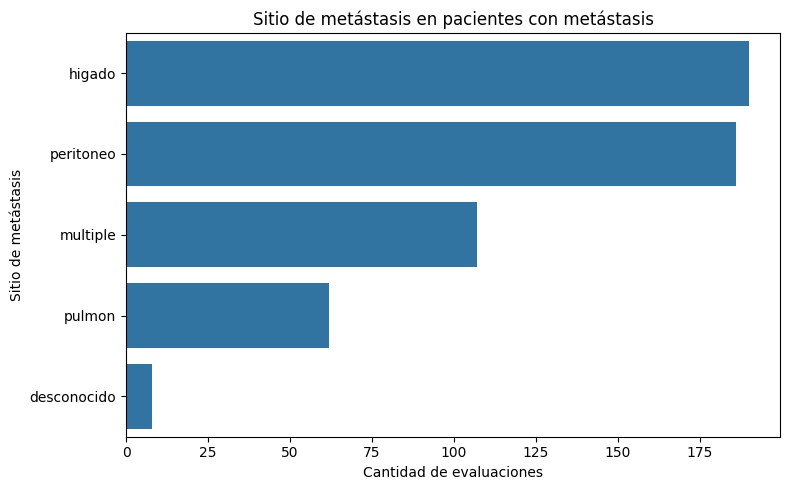

In [65]:
df_metastasis_si = df_eda[df_eda["metastasis"] == "si"].copy()
df_metastasis_si["sitio_metastasis_grafico"] = df_metastasis_si["sitio_metastasis"].fillna("desconocido")

plt.figure(figsize=(8, 5))
sns.countplot(
    data=df_metastasis_si,
    y="sitio_metastasis_grafico",
    order=df_metastasis_si["sitio_metastasis_grafico"].value_counts().index
)
plt.title("Sitio de metástasis en pacientes con metástasis")
plt.xlabel("Cantidad de evaluaciones")
plt.ylabel("Sitio de metástasis")
plt.tight_layout()
plt.savefig("eda_10_sitio_metastasis_solo_metastasis_si.png", dpi=300, bbox_inches="tight")
plt.show()

## Análisis de la Etapa 10

El dataset está compuesto únicamente por casos de cancer_gastrico, por lo que tipo_cancer aparece con 5000 registros, equivalente al 100%. Esto es correcto para el proyecto, pero en modelado esta variable deberá excluirse porque no aporta variabilidad predictiva.

En cuanto al tipo_histologico, predomina el adenocarcinoma_intestinal con 49.34%, seguido de adenocarcinoma_difuso con 35.06%, adenocarcinoma_mixto con 10.76% y otro con 4.84%. Esto permite representar diferentes variantes histológicas dentro del cáncer gástrico.

La variable estadio muestra mayor concentración en estadios intermedios y avanzados. El estadio II representa 32.82%, el estadio III 25.96%, el estadio I 23.22%, el estadio IV 11.06% y el estadio 0 6.94%. Esto es relevante para el modelo porque el estadio clínico debería tener una relación importante con el nivel_prioridad.

Respecto al grado_histologico, predominan los grados G3 y G2, con 34.18% y 32.70%, respectivamente. El grado G1 representa 18.78% y G4 12.88%. Esto indica que existe una presencia importante de tumores con comportamiento más agresivo, especialmente en los grados altos.

La variable profundidad_tumor también presenta una distribución coherente con la progresión clínica. Las categorías más frecuentes son muscular con 26.70% y serosa con 25.64%, seguidas por submucosa, mucosa, invasion_local y enfermedad_diseminada.

En ganglios_afectados, la media es de 3.61 ganglios, con una mediana de 2 y un máximo de 17. El histograma muestra que muchos pacientes tienen pocos o ningún ganglio afectado, pero también existe un grupo con afectación ganglionar elevada. El boxplot identifica valores altos, pero estos no deben considerarse errores automáticamente porque pueden representar casos clínicamente más avanzados.

La variable metastasis muestra que el 88.94% de las evaluaciones no presenta metástasis y el 11.06% sí la presenta. Esto coincide con la presencia de estadio IV en el dataset. En sitio_metastasis, la mayoría corresponde a ninguno con 87.88%, seguido de hígado, peritoneo, múltiples sitios y pulmón. Los valores NaN representan solo 1.22%, por lo que no afectan de forma severa la calidad del dataset.

El análisis univariado clínico-oncológico muestra que el dataset contiene variables relevantes para explicar la prioridad de atención, especialmente estadio, grado_histologico, profundidad_tumor, ganglios_afectados, metastasis y sitio_metastasis. Estas variables reflejan la severidad y progresión del cáncer gástrico, por lo que serán fundamentales en el análisis bivariado y en la etapa de modelado supervisado.

## 11. Análisis univariado de síntomas y estado del paciente

In [66]:
variables_sintomas_estado = [
    "perdida_peso_kg",
    "estado_nutricional",
    "hemoglobina",
    "anemia",
    "dolor",
    "vomitos_frecuentes",
    "sangrado_digestivo",
    "fatiga",
    "dificultad_alimentarse",
    "comorbilidades",
    "estado_funcional"
]

print("--- VARIABLES DE SÍNTOMAS Y ESTADO DEL PACIENTE ---")
print(variables_sintomas_estado)

--- VARIABLES DE SÍNTOMAS Y ESTADO DEL PACIENTE ---
['perdida_peso_kg', 'estado_nutricional', 'hemoglobina', 'anemia', 'dolor', 'vomitos_frecuentes', 'sangrado_digestivo', 'fatiga', 'dificultad_alimentarse', 'comorbilidades', 'estado_funcional']


In [67]:
print("--- RESUMEN DE VARIABLES NUMÉRICAS DE SÍNTOMAS ---")

variables_sintomas_numericas = [
    "perdida_peso_kg",
    "hemoglobina"
]

display(df_eda[variables_sintomas_numericas].describe())

--- RESUMEN DE VARIABLES NUMÉRICAS DE SÍNTOMAS ---


,perdida_peso_kg,hemoglobina
count,4895.000000,4860.000000
mean,5.749806,11.911070
std,2.992082,1.151502
min,0.000000,7.900000
25%,3.600000,11.100000
50%,5.700000,12.000000
75%,7.900000,12.700000
max,16.600000,15.500000


In [68]:
def tabla_frecuencia(df, columna):
    tabla = df[columna].value_counts(dropna=False).reset_index()
    tabla.columns = [columna, "frecuencia"]
    tabla["porcentaje"] = (tabla["frecuencia"] / len(df) * 100).round(2)
    return tabla

variables_sintomas_categoricas = [
    "estado_nutricional",
    "anemia",
    "dolor",
    "vomitos_frecuentes",
    "sangrado_digestivo",
    "fatiga",
    "dificultad_alimentarse",
    "comorbilidades",
    "estado_funcional"
]

for col in variables_sintomas_categoricas:
    print(f"\n--- Frecuencia de {col} ---")
    display(tabla_frecuencia(df_eda, col))


--- Frecuencia de estado_nutricional ---


,estado_nutricional,frecuencia,porcentaje
0,riesgo,2264,45.28
1,adecuado,1725,34.50
2,desnutricion,1011,20.22



--- Frecuencia de anemia ---


,anemia,frecuencia,porcentaje
0,si,3378,67.56
1,no,1622,32.44



--- Frecuencia de dolor ---


...

,dificultad_alimentarse,frecuencia,porcentaje
0,no,3023,60.46
1,si,1977,39.54



--- Frecuencia de comorbilidades ---


,comorbilidades,frecuencia,porcentaje
0,ninguna,2191,43.82
1,una,1828,36.56
2,multiples,981,19.62



--- Frecuencia de estado_funcional ---


,estado_funcional,frecuencia,porcentaje
0,limitado,2415,48.30
1,bueno,1867,37.34
2,dependiente,658,13.16
3,NaN,60,1.20


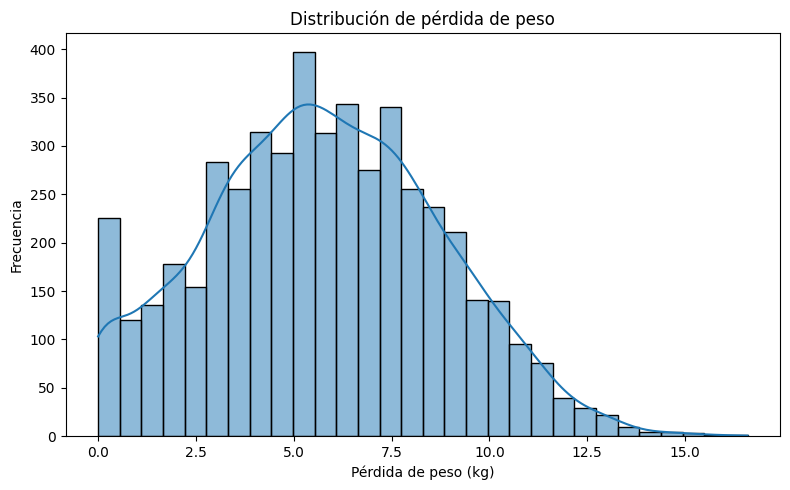

In [69]:
plt.figure(figsize=(8, 5))
sns.histplot(df_eda["perdida_peso_kg"], bins=30, kde=True)
plt.title("Distribución de pérdida de peso")
plt.xlabel("Pérdida de peso (kg)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.savefig("eda_11_perdida_peso.png", dpi=300, bbox_inches="tight")
plt.show()

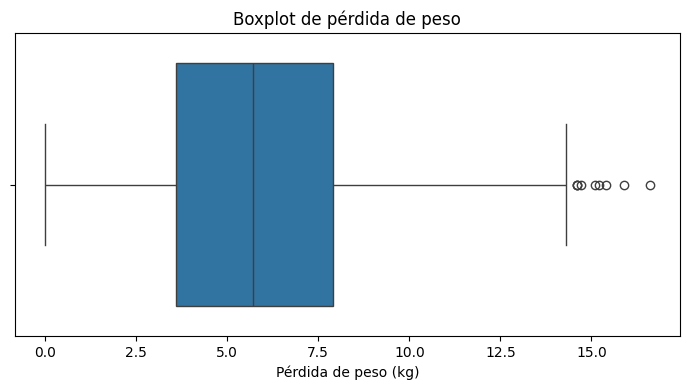

In [70]:
plt.figure(figsize=(7, 4))
sns.boxplot(x=df_eda["perdida_peso_kg"])
plt.title("Boxplot de pérdida de peso")
plt.xlabel("Pérdida de peso (kg)")
plt.tight_layout()
plt.savefig("eda_11_boxplot_perdida_peso.png", dpi=300, bbox_inches="tight")
plt.show()

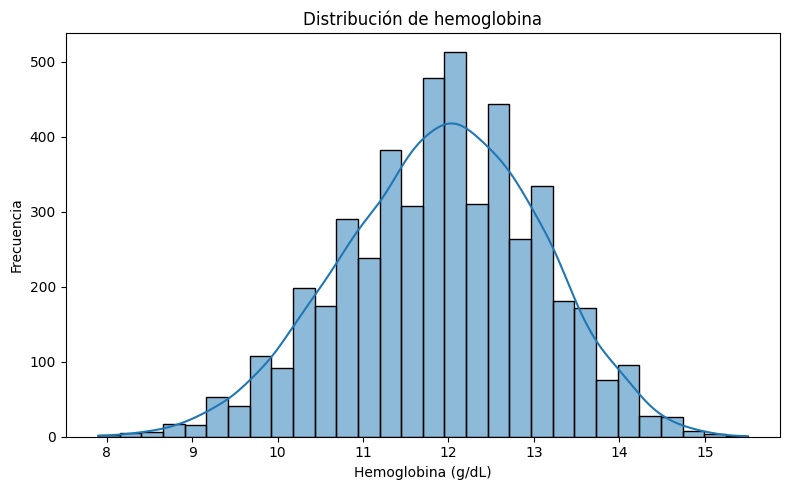

In [71]:
plt.figure(figsize=(8, 5))
sns.histplot(df_eda["hemoglobina"], bins=30, kde=True)
plt.title("Distribución de hemoglobina")
plt.xlabel("Hemoglobina (g/dL)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.savefig("eda_11_hemoglobina.png", dpi=300, bbox_inches="tight")
plt.show()

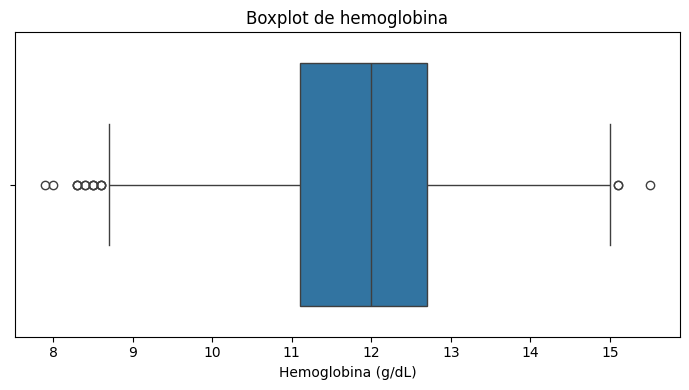

In [72]:
plt.figure(figsize=(7, 4))
sns.boxplot(x=df_eda["hemoglobina"])
plt.title("Boxplot de hemoglobina")
plt.xlabel("Hemoglobina (g/dL)")
plt.tight_layout()
plt.savefig("eda_11_boxplot_hemoglobina.png", dpi=300, bbox_inches="tight")
plt.show()

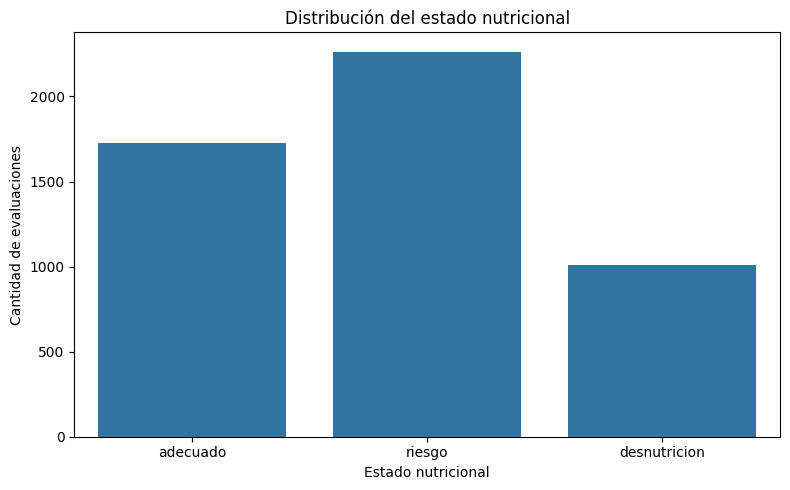

In [73]:
orden_nutricional = ["adecuado", "riesgo", "desnutricion"]

plt.figure(figsize=(8, 5))
sns.countplot(
    data=df_eda,
    x="estado_nutricional",
    order=orden_nutricional
)
plt.title("Distribución del estado nutricional")
plt.xlabel("Estado nutricional")
plt.ylabel("Cantidad de evaluaciones")
plt.tight_layout()
plt.savefig("eda_11_estado_nutricional.png", dpi=300, bbox_inches="tight")
plt.show()

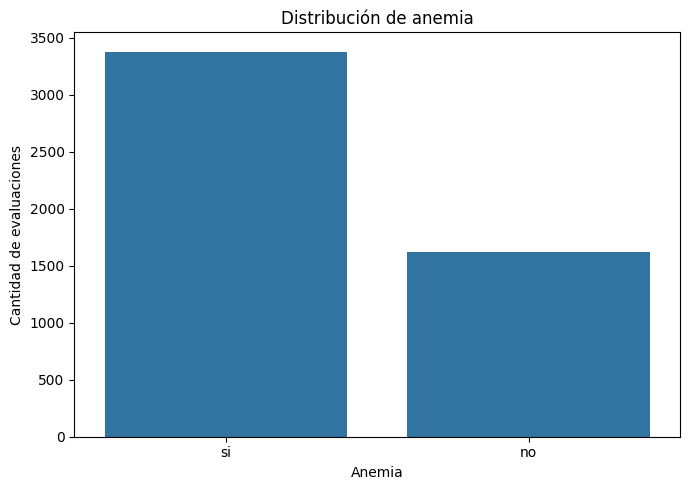

In [74]:
plt.figure(figsize=(7, 5))
sns.countplot(
    data=df_eda,
    x="anemia",
    order=df_eda["anemia"].value_counts().index
)
plt.title("Distribución de anemia")
plt.xlabel("Anemia")
plt.ylabel("Cantidad de evaluaciones")
plt.tight_layout()
plt.savefig("eda_11_anemia.png", dpi=300, bbox_inches="tight")
plt.show()

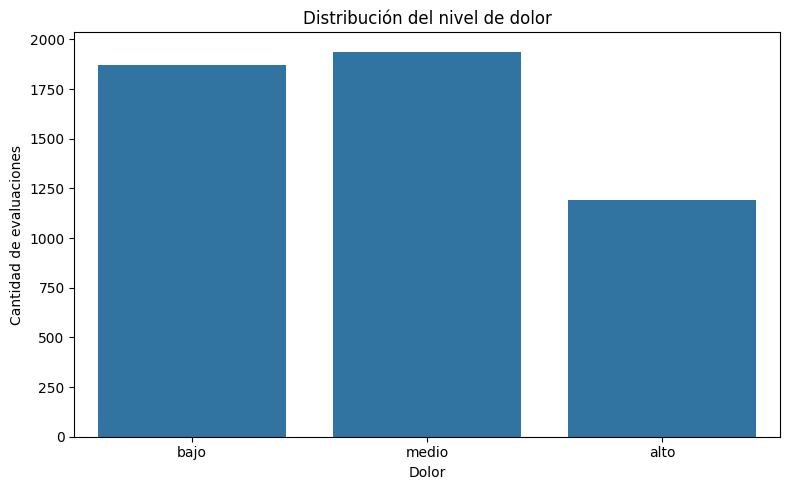

In [75]:
orden_dolor = ["bajo", "medio", "alto"]

plt.figure(figsize=(8, 5))
sns.countplot(
    data=df_eda,
    x="dolor",
    order=orden_dolor
)
plt.title("Distribución del nivel de dolor")
plt.xlabel("Dolor")
plt.ylabel("Cantidad de evaluaciones")
plt.tight_layout()
plt.savefig("eda_11_dolor.png", dpi=300, bbox_inches="tight")
plt.show()

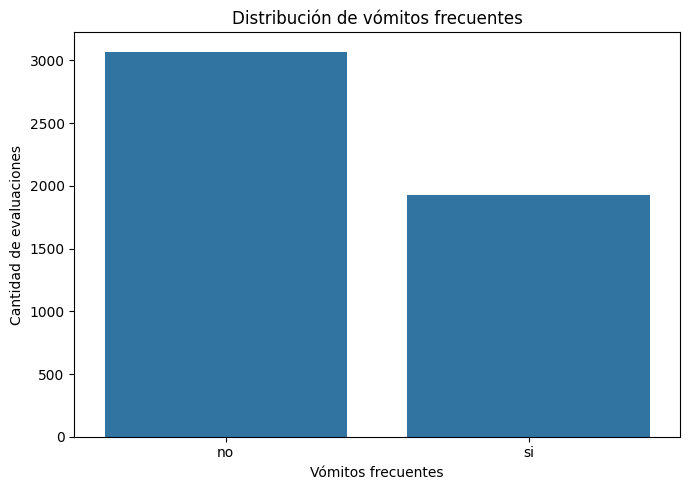

In [76]:
plt.figure(figsize=(7, 5))
sns.countplot(
    data=df_eda,
    x="vomitos_frecuentes",
    order=df_eda["vomitos_frecuentes"].value_counts().index
)
plt.title("Distribución de vómitos frecuentes")
plt.xlabel("Vómitos frecuentes")
plt.ylabel("Cantidad de evaluaciones")
plt.tight_layout()
plt.savefig("eda_11_vomitos_frecuentes.png", dpi=300, bbox_inches="tight")
plt.show()

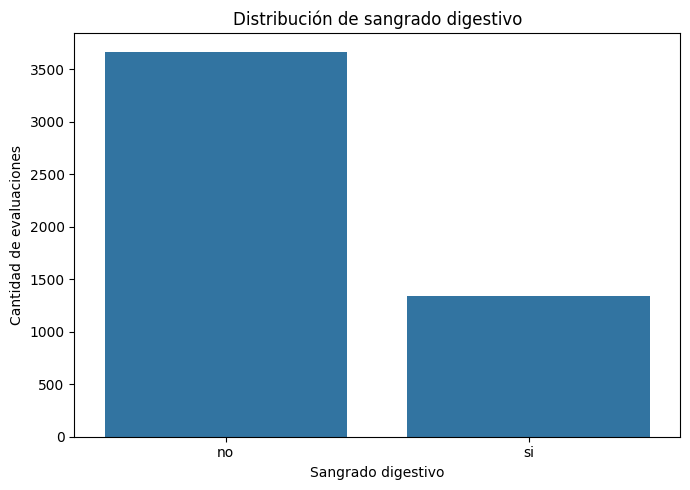

In [77]:
plt.figure(figsize=(7, 5))
sns.countplot(
    data=df_eda,
    x="sangrado_digestivo",
    order=df_eda["sangrado_digestivo"].value_counts().index
)
plt.title("Distribución de sangrado digestivo")
plt.xlabel("Sangrado digestivo")
plt.ylabel("Cantidad de evaluaciones")
plt.tight_layout()
plt.savefig("eda_11_sangrado_digestivo.png", dpi=300, bbox_inches="tight")
plt.show()

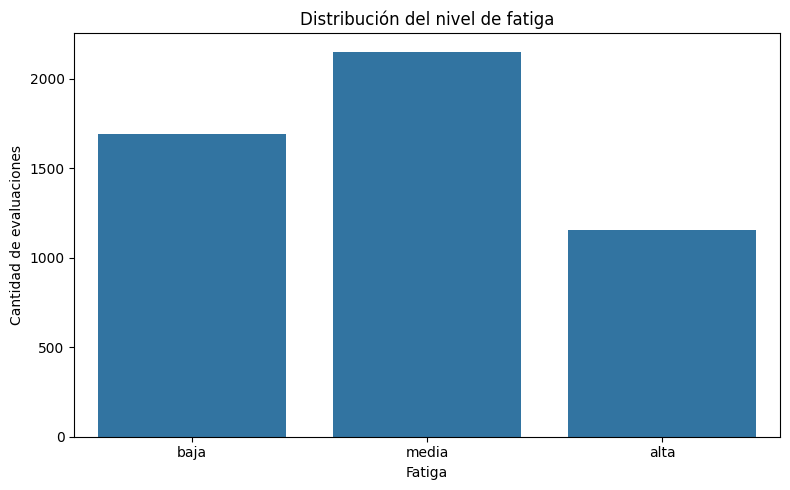

In [78]:
orden_fatiga = ["baja", "media", "alta"]

plt.figure(figsize=(8, 5))
sns.countplot(
    data=df_eda,
    x="fatiga",
    order=orden_fatiga
)
plt.title("Distribución del nivel de fatiga")
plt.xlabel("Fatiga")
plt.ylabel("Cantidad de evaluaciones")
plt.tight_layout()
plt.savefig("eda_11_fatiga.png", dpi=300, bbox_inches="tight")
plt.show()

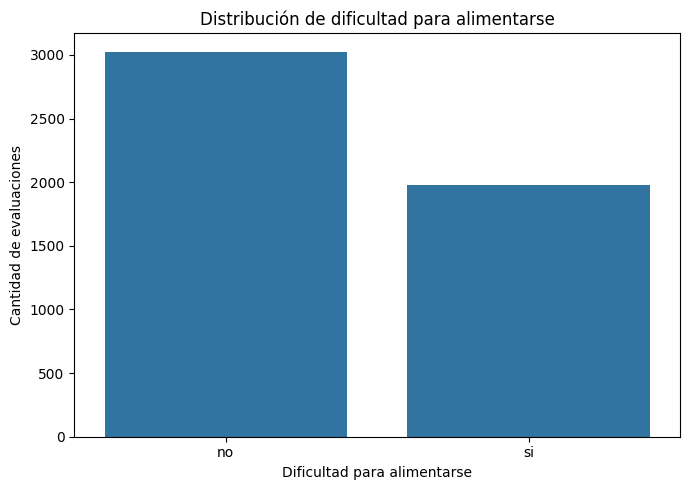

In [79]:
plt.figure(figsize=(7, 5))
sns.countplot(
    data=df_eda,
    x="dificultad_alimentarse",
    order=df_eda["dificultad_alimentarse"].value_counts().index
)
plt.title("Distribución de dificultad para alimentarse")
plt.xlabel("Dificultad para alimentarse")
plt.ylabel("Cantidad de evaluaciones")
plt.tight_layout()
plt.savefig("eda_11_dificultad_alimentarse.png", dpi=300, bbox_inches="tight")
plt.show()

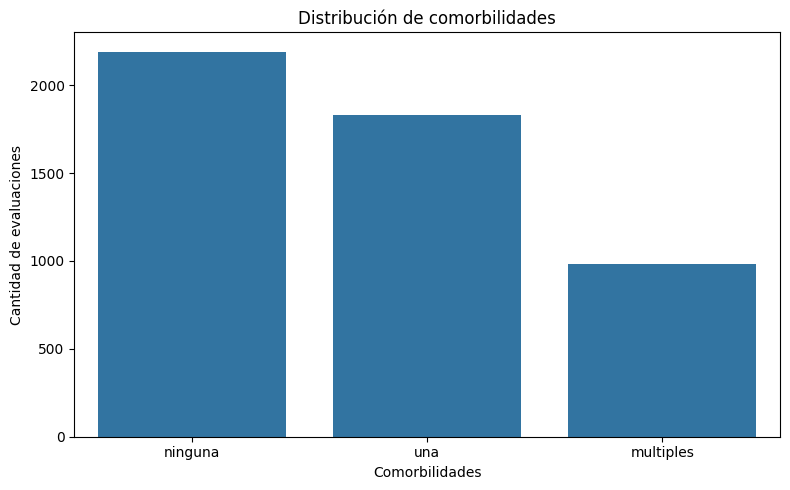

In [80]:
orden_comorbilidades = ["ninguna", "una", "multiples"]

plt.figure(figsize=(8, 5))
sns.countplot(
    data=df_eda,
    x="comorbilidades",
    order=orden_comorbilidades
)
plt.title("Distribución de comorbilidades")
plt.xlabel("Comorbilidades")
plt.ylabel("Cantidad de evaluaciones")
plt.tight_layout()
plt.savefig("eda_11_comorbilidades.png", dpi=300, bbox_inches="tight")
plt.show()

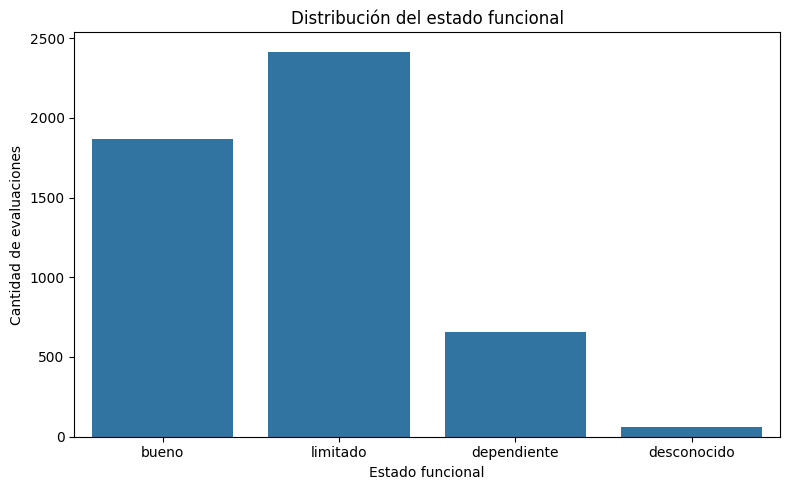

In [81]:
df_eda["estado_funcional_grafico"] = df_eda["estado_funcional"].fillna("desconocido")

orden_estado_funcional = ["bueno", "limitado", "dependiente", "desconocido"]

plt.figure(figsize=(8, 5))
sns.countplot(
    data=df_eda,
    x="estado_funcional_grafico",
    order=orden_estado_funcional
)
plt.title("Distribución del estado funcional")
plt.xlabel("Estado funcional")
plt.ylabel("Cantidad de evaluaciones")
plt.tight_layout()
plt.savefig("eda_11_estado_funcional.png", dpi=300, bbox_inches="tight")
plt.show()

## Análisis de la Etapa 11

El análisis univariado de síntomas y estado del paciente muestra que las variables clínicas generales tienen bastante relación con el contexto del cáncer gástrico.

En las variables numéricas, perdida_peso_kg presenta una media de 5.75 kg, una mediana de 5.7 kg y un máximo de 16.6 kg. Esto indica que una parte importante de los pacientes presenta pérdida de peso relevante, lo cual es coherente con un cáncer digestivo como el cáncer gástrico. El boxplot muestra algunos valores altos, pero no deben eliminarse automáticamente porque pueden representar casos clínicamente más complejos.

La variable hemoglobina tiene una media de 11.91 g/dL, con valores entre 7.9 y 15.5 g/dL. La distribución se concentra alrededor de 12 g/dL, pero existen valores bajos que podrían estar relacionados con anemia o sangrado digestivo. Estos valores bajos tampoco deben eliminarse, porque pueden ser clínicamente significativos.

En estado_nutricional, la categoría más frecuente es riesgo, con 45.28%, seguida de adecuado con 34.50% y desnutricion con 20.22%. Esto confirma que una proporción importante de pacientes presenta compromiso nutricional o riesgo de deterioro.

La variable anemia muestra que 67.56% de las evaluaciones presentan anemia, frente a 32.44% sin anemia. Este hallazgo es importante porque la anemia puede reflejar deterioro clínico, sangrado digestivo o afectación nutricional.

En cuanto a dolor, predominan los niveles medio con 38.78% y bajo con 37.40%, mientras que el dolor alto aparece en 23.82%. Esta variable será importante en el análisis bivariado porque se espera que el dolor alto se relacione con mayor prioridad.

Los vomitos_frecuentes aparecen en 38.58% de las evaluaciones, mientras que el sangrado_digestivo aparece en 26.76%. Ambas variables son clínicamente relevantes en cáncer gástrico, especialmente para evaluar riesgo, deterioro y necesidad de soporte.

La fatiga se concentra principalmente en nivel media con 43.00%, seguida de baja con 33.88% y alta con 23.12%. Además, 39.54% presenta dificultad para alimentarse, lo que refuerza la importancia del soporte nutricional.

En comorbilidades, el 43.82% no presenta comorbilidades, el 36.56% tiene una y el 19.62% presenta múltiples. Finalmente, el estado_funcional muestra que 48.30% está limitado, 37.34% está en buen estado y 13.16% es dependiente. Esto indica que una parte considerable de los pacientes tiene limitaciones funcionales.

El análisis univariado de síntomas y estado clínico evidencia que el dataset representa pacientes con signos relevantes de deterioro físico, nutricional y funcional. Variables como perdida_peso_kg, hemoglobina, anemia, estado_nutricional, dolor, vomitos_frecuentes, dificultad_alimentarse y estado_funcional serán importantes para explicar el nivel_prioridad. Estas variables deberán analizarse posteriormente de forma bivariada para identificar cuáles se asocian con mayor fuerza a la prioridad alta.

## 12. Análisis univariado de variables de tratamiento

In [82]:

variables_tratamiento = [
    "requiere_cirugia",
    "requiere_quimioterapia",
    "requiere_soporte_nutricional",
    "requiere_cuidados_paliativos",
    "tratamiento_principal"
]

print("--- VARIABLES DE TRATAMIENTO ---")
print(variables_tratamiento)

--- VARIABLES DE TRATAMIENTO ---
['requiere_cirugia', 'requiere_quimioterapia', 'requiere_soporte_nutricional', 'requiere_cuidados_paliativos', 'tratamiento_principal']


In [83]:
def tabla_frecuencia(df, columna):
    tabla = df[columna].value_counts(dropna=False).reset_index()
    tabla.columns = [columna, "frecuencia"]
    tabla["porcentaje"] = (tabla["frecuencia"] / len(df) * 100).round(2)
    return tabla

for col in variables_tratamiento:
    print(f"\n--- Frecuencia de {col} ---")
    display(tabla_frecuencia(df_eda, col))


--- Frecuencia de requiere_cirugia ---


,requiere_cirugia,frecuencia,porcentaje
0,si,2983,59.66
1,no,2017,40.34



--- Frecuencia de requiere_quimioterapia ---


,requiere_quimioterapia,frecuencia,porcentaje
0,no,2590,51.8
1,si,2410,48.2



--- Frecuencia de requiere_soporte_nutricional ---


,requiere_soporte_nutricional,frecuencia,porcentaje
0,si,3464,69.28
1,no,1536,30.72



--- Frecuencia de requiere_cuidados_paliativos ---


,requiere_cuidados_paliativos,frecuencia,porcentaje
0,no,4323,86.46
1,si,677,13.54



--- Frecuencia de tratamiento_principal ---


,tratamiento_principal,frecuencia,porcentaje
0,cirugia,1738,34.76
1,cirugia_quimioterapia,1028,20.56
2,quimioterapia,911,18.22
3,cuidados_paliativos,677,13.54
4,soporte_nutricional,423,8.46
5,seguimiento,223,4.46


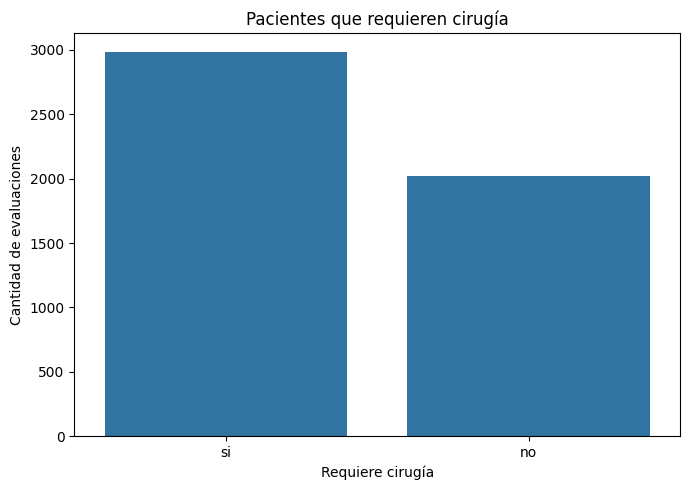

In [84]:
plt.figure(figsize=(7, 5))
sns.countplot(
    data=df_eda,
    x="requiere_cirugia",
    order=df_eda["requiere_cirugia"].value_counts().index
)
plt.title("Pacientes que requieren cirugía")
plt.xlabel("Requiere cirugía")
plt.ylabel("Cantidad de evaluaciones")
plt.tight_layout()
plt.savefig("eda_12_requiere_cirugia.png", dpi=300, bbox_inches="tight")
plt.show()

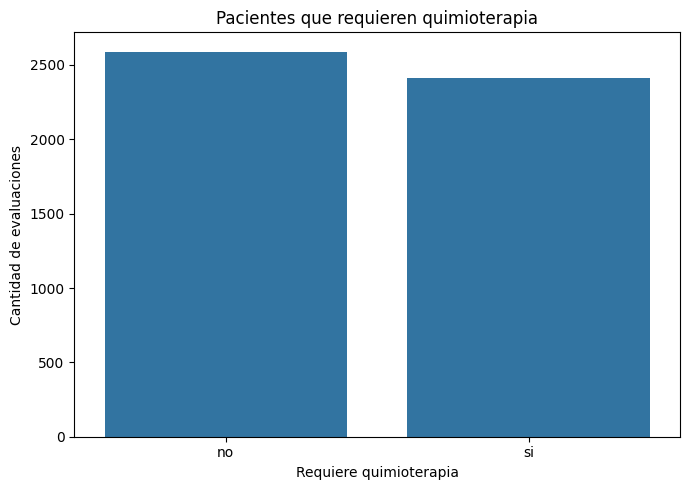

In [85]:
plt.figure(figsize=(7, 5))
sns.countplot(
    data=df_eda,
    x="requiere_quimioterapia",
    order=df_eda["requiere_quimioterapia"].value_counts().index
)
plt.title("Pacientes que requieren quimioterapia")
plt.xlabel("Requiere quimioterapia")
plt.ylabel("Cantidad de evaluaciones")
plt.tight_layout()
plt.savefig("eda_12_requiere_quimioterapia.png", dpi=300, bbox_inches="tight")
plt.show()

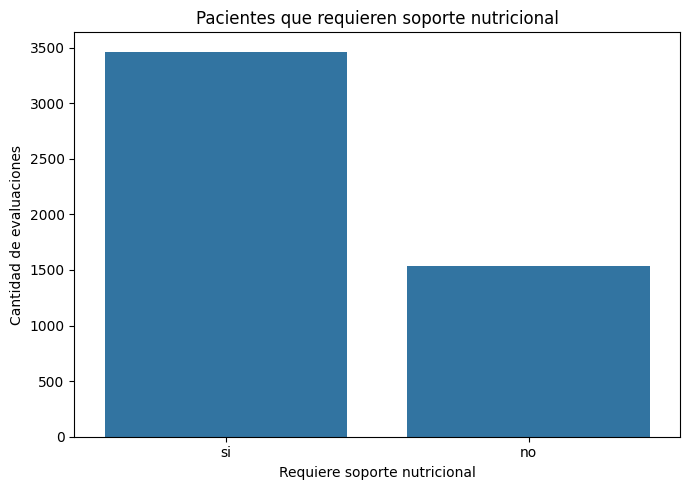

In [86]:
plt.figure(figsize=(7, 5))
sns.countplot(
    data=df_eda,
    x="requiere_soporte_nutricional",
    order=df_eda["requiere_soporte_nutricional"].value_counts().index
)
plt.title("Pacientes que requieren soporte nutricional")
plt.xlabel("Requiere soporte nutricional")
plt.ylabel("Cantidad de evaluaciones")
plt.tight_layout()
plt.savefig("eda_12_requiere_soporte_nutricional.png", dpi=300, bbox_inches="tight")
plt.show()

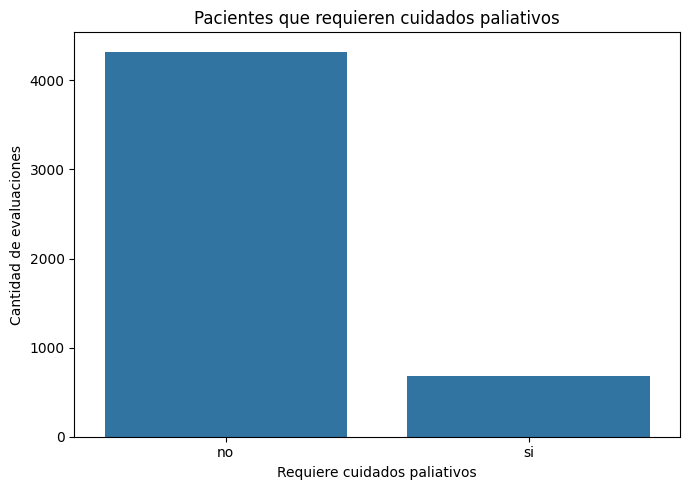

In [87]:
plt.figure(figsize=(7, 5))
sns.countplot(
    data=df_eda,
    x="requiere_cuidados_paliativos",
    order=df_eda["requiere_cuidados_paliativos"].value_counts().index
)
plt.title("Pacientes que requieren cuidados paliativos")
plt.xlabel("Requiere cuidados paliativos")
plt.ylabel("Cantidad de evaluaciones")
plt.tight_layout()
plt.savefig("eda_12_requiere_cuidados_paliativos.png", dpi=300, bbox_inches="tight")
plt.show()

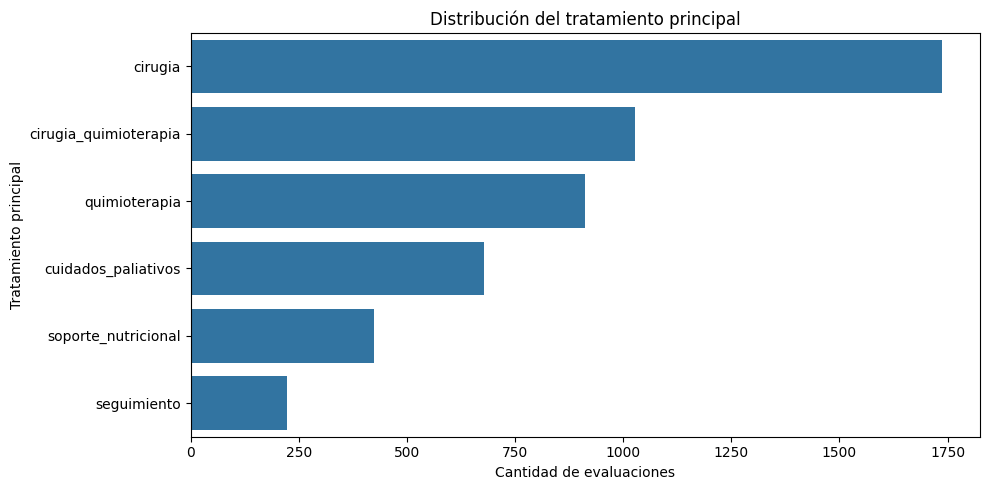

In [88]:
plt.figure(figsize=(10, 5))
sns.countplot(
    data=df_eda,
    y="tratamiento_principal",
    order=df_eda["tratamiento_principal"].value_counts().index
)
plt.title("Distribución del tratamiento principal")
plt.xlabel("Cantidad de evaluaciones")
plt.ylabel("Tratamiento principal")
plt.tight_layout()
plt.savefig("eda_12_tratamiento_principal.png", dpi=300, bbox_inches="tight")
plt.show()

,tratamiento,cantidad_si,porcentaje_si
0,cirugia,2983,59.66
1,quimioterapia,2410,48.20
2,soporte nutricional,3464,69.28
3,cuidados paliativos,677,13.54


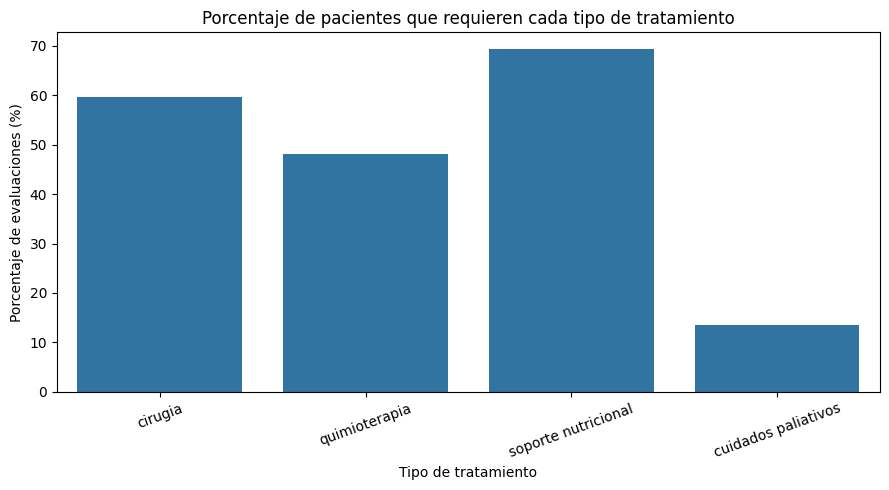

In [89]:
tratamientos_binarios = [
    "requiere_cirugia",
    "requiere_quimioterapia",
    "requiere_soporte_nutricional",
    "requiere_cuidados_paliativos"
]

resumen_tratamientos = []

for col in tratamientos_binarios:
    cantidad_si = (df_eda[col] == "si").sum()
    porcentaje_si = round(cantidad_si / len(df_eda) * 100, 2)
    resumen_tratamientos.append({
        "tratamiento": col.replace("requiere_", "").replace("_", " "),
        "cantidad_si": cantidad_si,
        "porcentaje_si": porcentaje_si
    })

resumen_tratamientos = pd.DataFrame(resumen_tratamientos)

display(resumen_tratamientos)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=resumen_tratamientos,
    x="tratamiento",
    y="porcentaje_si"
)
plt.title("Porcentaje de pacientes que requieren cada tipo de tratamiento")
plt.xlabel("Tipo de tratamiento")
plt.ylabel("Porcentaje de evaluaciones (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("eda_12_resumen_tratamientos.png", dpi=300, bbox_inches="tight")
plt.show()

## Análisis de la Etapa 12

El análisis univariado de tratamiento muestra que una proporción importante de pacientes requiere intervenciones clínicas activas. La variable requiere_cirugia indica que 2983 evaluaciones, equivalentes al 59.66%, corresponden a pacientes que requieren cirugía. Esto refleja que una parte considerable del dataset está asociada a manejo quirúrgico.

En cuanto a requiere_quimioterapia, el 48.20% de las evaluaciones requiere quimioterapia, mientras que el 51.80% no la requiere. Esta distribución es relativamente equilibrada, por lo que la variable puede aportar información útil al modelo.

La variable requiere_soporte_nutricional presenta el porcentaje más alto entre los tratamientos binarios: 69.28% de las evaluaciones requieren soporte nutricional. Esto es coherente con lo observado en la etapa anterior, donde una parte importante de pacientes tenía riesgo nutricional, desnutrición o dificultad para alimentarse.

Por otro lado, requiere_cuidados_paliativos aparece en 13.54% de las evaluaciones. Aunque es una proporción menor, esta variable es clínicamente muy relevante, porque probablemente estará asociada a pacientes de mayor gravedad o prioridad alta.

En tratamiento_principal, el tratamiento más frecuente es cirugia, con 34.76%, seguido de cirugia_quimioterapia con 20.56%, quimioterapia con 18.22%, cuidados_paliativos con 13.54%, soporte_nutricional con 8.46% y seguimiento con 4.46%. Esto indica que el dataset combina pacientes en seguimiento, tratamiento activo y manejo paliativo.

El análisis de tratamiento evidencia que el dataset contiene pacientes con diferentes necesidades clínicas, desde seguimiento hasta cirugía, quimioterapia, soporte nutricional y cuidados paliativos. Las variables requiere_quimioterapia, requiere_soporte_nutricional,requiere_cuidados_paliativos y tratamiento_principal serán relevantes para el análisis bivariado, ya que pueden ayudar a explicar el nivel_prioridad de atención.

## 13. Análisis univariado de la variable objetivo nivel_prioridad

In [90]:
variable_objetivo = "nivel_prioridad"

print("--- VARIABLE OBJETIVO ---")
print(variable_objetivo)

print("\n--- FRECUENCIA DE nivel_prioridad ---")
frecuencia_prioridad = df_eda[variable_objetivo].value_counts().reset_index()
frecuencia_prioridad.columns = ["nivel_prioridad", "frecuencia"]
frecuencia_prioridad["porcentaje"] = (
    frecuencia_prioridad["frecuencia"] / len(df_eda) * 100
).round(2)

display(frecuencia_prioridad)

print("\n--- VALIDACIÓN DE CLASES ---")
print(df_eda[variable_objetivo].unique())

print("\n--- CANTIDAD DE CLASES ---")
print(df_eda[variable_objetivo].nunique())

--- VARIABLE OBJETIVO ---
nivel_prioridad

--- FRECUENCIA DE nivel_prioridad ---


,nivel_prioridad,frecuencia,porcentaje
0,medio,1790,35.8
1,alto,1690,33.8
2,bajo,1520,30.4



--- VALIDACIÓN DE CLASES ---
['bajo' 'medio' 'alto']

--- CANTIDAD DE CLASES ---
3


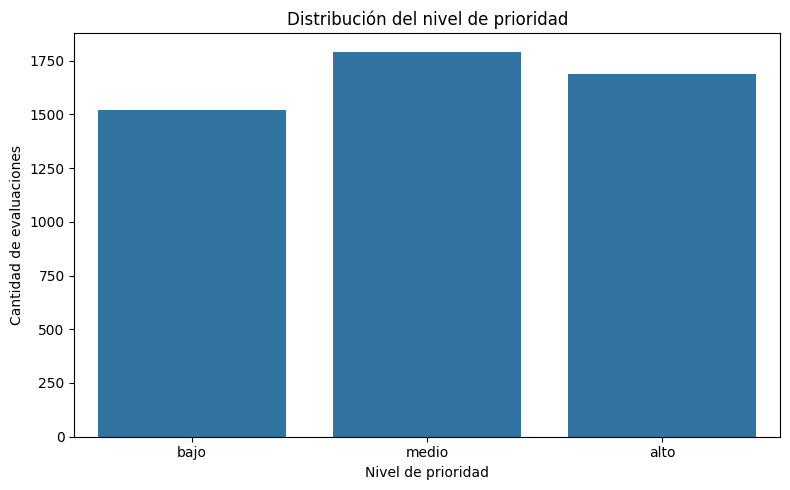

In [91]:
orden_prioridad = ["bajo", "medio", "alto"]

plt.figure(figsize=(8, 5))
sns.countplot(
    data=df_eda,
    x="nivel_prioridad",
    order=orden_prioridad
)
plt.title("Distribución del nivel de prioridad")
plt.xlabel("Nivel de prioridad")
plt.ylabel("Cantidad de evaluaciones")
plt.tight_layout()
plt.savefig("eda_13_nivel_prioridad.png", dpi=300, bbox_inches="tight")
plt.show()

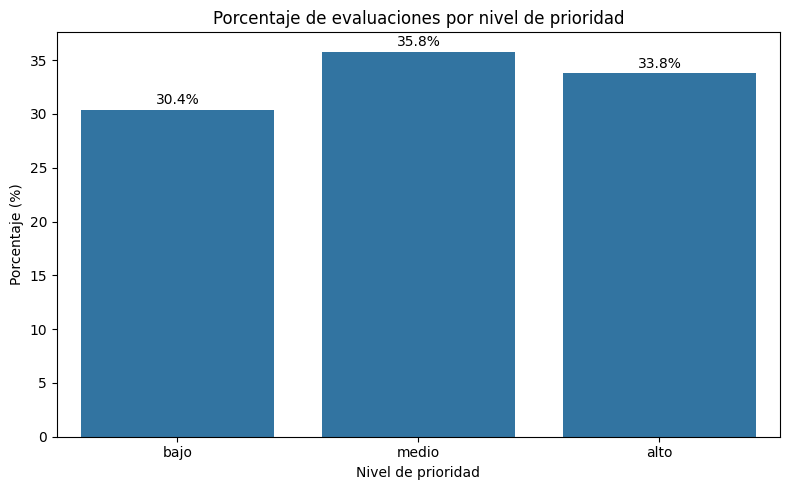

In [92]:
frecuencia_prioridad_ordenada = frecuencia_prioridad.set_index("nivel_prioridad").loc[orden_prioridad].reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(
    data=frecuencia_prioridad_ordenada,
    x="nivel_prioridad",
    y="porcentaje"
)

plt.title("Porcentaje de evaluaciones por nivel de prioridad")
plt.xlabel("Nivel de prioridad")
plt.ylabel("Porcentaje (%)")

for index, row in frecuencia_prioridad_ordenada.iterrows():
    plt.text(
        index,
        row["porcentaje"] + 0.5,
        f'{row["porcentaje"]}%',
        ha="center"
    )

plt.tight_layout()
plt.savefig("eda_13_porcentaje_nivel_prioridad.png", dpi=300, bbox_inches="tight")
plt.show()

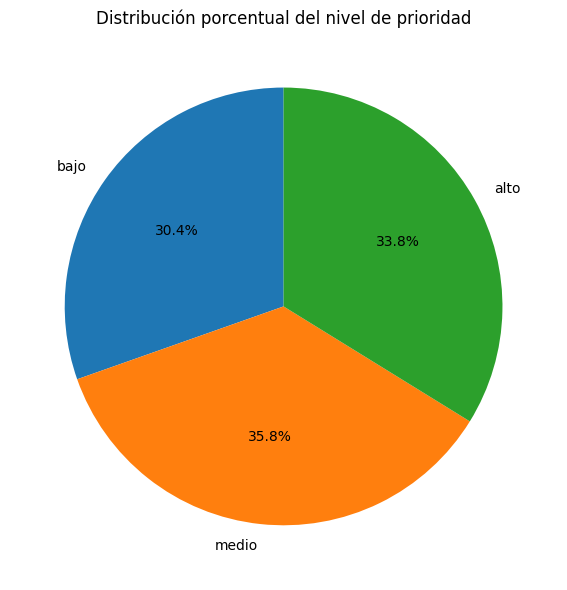

In [93]:
plt.figure(figsize=(6, 6))
plt.pie(
    frecuencia_prioridad_ordenada["frecuencia"],
    labels=frecuencia_prioridad_ordenada["nivel_prioridad"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Distribución porcentual del nivel de prioridad")
plt.tight_layout()
plt.savefig("eda_13_pie_nivel_prioridad.png", dpi=300, bbox_inches="tight")
plt.show()

## Análisis de la Etapa 13

La variable objetivo `nivel_prioridad` tiene **3 clases**: `bajo`, `medio` y `alto`. La distribución es:

| Nivel de prioridad | Frecuencia | Porcentaje |
| ------------------ | ---------: | ---------: |
| bajo               |       1520 |      30.4% |
| medio              |       1790 |      35.8% |
| alto               |       1690 |      33.8% |

La distribución es bastante equilibrada. No existe una clase extremadamente dominante, lo cual es positivo para el entrenamiento del modelo de clasificación. La clase más frecuente es `medio`, con **35.8%**, pero la diferencia frente a `alto` y `bajo` no es grande.

Esto significa que, para el modelado, no sería necesario aplicar técnicas fuertes de balanceo como sobremuestreo o submuestreo desde el inicio. Sin embargo, sí será importante usar métricas como **macro-F1**, **recall por clase** y **matriz de confusión**, porque el objetivo no solo será acertar en general, sino identificar correctamente a los pacientes de prioridad alta.

Además, este resultado permite calcular un baseline simple: si un modelo siempre predijera la clase mayoritaria (`medio`), tendría una exactitud aproximada de **35.8%**. Por lo tanto, cualquier modelo útil deberá superar claramente ese valor.

La variable objetivo `nivel_prioridad` presenta una distribución balanceada entre las tres categorías de atención. Esto favorece el entrenamiento de modelos supervisados de clasificación multiclase y reduce el riesgo de que el modelo aprenda únicamente una clase dominante. La distribución obtenida permite continuar hacia el análisis bivariado, donde se evaluará qué variables clínicas, sociales y de tratamiento se relacionan más con la prioridad de atención.

## 14. Análisis bivariado de variables clínicas vs nivel_prioridad

In [94]:
orden_prioridad = ["bajo", "medio", "alto"]

variables_clinicas_bivariadas = [
    "tipo_histologico",
    "estadio",
    "grado_histologico",
    "profundidad_tumor",
    "metastasis",
    "sitio_metastasis",
    "ganglios_afectados"
]

print("--- VARIABLES CLÍNICAS PARA ANÁLISIS BIVARIADO ---")
print(variables_clinicas_bivariadas)

--- VARIABLES CLÍNICAS PARA ANÁLISIS BIVARIADO ---
['tipo_histologico', 'estadio', 'grado_histologico', 'profundidad_tumor', 'metastasis', 'sitio_metastasis', 'ganglios_afectados']


In [100]:
def tabla_cruzada_porcentual(df, variable, objetivo="nivel_prioridad", orden_filas=None):
    serie_variable = df[variable].astype("object").fillna("desconocido")

    tabla = pd.crosstab(
        serie_variable,
        df[objetivo],
        normalize="index"
    ) * 100

    tabla = tabla.reindex(columns=orden_prioridad)

    if orden_filas is not None:
        filas_existentes = [fila for fila in orden_filas if fila in tabla.index]
        tabla = tabla.reindex(filas_existentes)

    return tabla.round(2)

In [101]:
ordenes_clinicas = {
    "estadio": ["0", "I", "II", "III", "IV"],
    "grado_histologico": ["G1", "G2", "G3", "G4", "desconocido"],
    "profundidad_tumor": [
        "mucosa",
        "submucosa",
        "muscular",
        "serosa",
        "invasion_local",
        "enfermedad_diseminada"
    ],
    "metastasis": ["no", "si"],
    "sitio_metastasis": [
        "ninguno",
        "higado",
        "peritoneo",
        "multiple",
        "pulmon",
        "desconocido"
    ]
}

for col in variables_clinicas_categoricas_bivariadas:
    print(f"\n--- Distribución porcentual de nivel_prioridad según {col} ---")

    orden = ordenes_clinicas.get(col, None)

    display(
        tabla_cruzada_porcentual(
            df=df_eda,
            variable=col,
            objetivo="nivel_prioridad",
            orden_filas=orden
        )
    )


--- Distribución porcentual de nivel_prioridad según tipo_histologico ---


nivel_prioridad,bajo,medio,alto
tipo_histologico,,,
adenocarcinoma_difuso,29.44,35.88,34.68
adenocarcinoma_intestinal,30.85,34.74,34.41
adenocarcinoma_mixto,31.04,40.33,28.62
otro,31.40,35.95,32.64



--- Distribución porcentual de nivel_prioridad según estadio ---


nivel_prioridad,bajo,medio,alto
estadio,,,
0,97.41,0.86,1.73
I,91.90,6.37,1.72
II,7.01,89.58,3.41
III,0.00,18.72,81.28
IV,0.00,0.00,100.00



--- Distribución porcentual de nivel_prioridad según grado_histologico ---


...

nivel_prioridad,bajo,medio,alto
profundidad_tumor,,,
mucosa,94.44,4.07,1.49
submucosa,64.55,32.67,2.78
muscular,22.55,63.22,14.23
serosa,2.65,46.33,51.01
invasion_local,0.00,11.77,88.23
enfermedad_diseminada,0.00,0.00,100.00



--- Distribución porcentual de nivel_prioridad según metastasis ---


nivel_prioridad,bajo,medio,alto
metastasis,,,
no,34.18,40.25,25.57
si,0.00,0.00,100.00



--- Distribución porcentual de nivel_prioridad según sitio_metastasis ---


nivel_prioridad,bajo,medio,alto
sitio_metastasis,,,
ninguno,34.23,40.1,25.67
higado,0.00,0.0,100.00
peritoneo,0.00,0.0,100.00
multiple,0.00,0.0,100.00
pulmon,0.00,0.0,100.00
desconocido,26.23,45.9,27.87


In [102]:
def grafico_bivariado_apilado(df, variable, titulo, nombre_archivo, orden_filas=None):
    serie_variable = df[variable].astype("object").fillna("desconocido")

    tabla = pd.crosstab(
        serie_variable,
        df["nivel_prioridad"],
        normalize="index"
    ) * 100

    tabla = tabla.reindex(columns=orden_prioridad)

    if orden_filas is not None:
        filas_existentes = [fila for fila in orden_filas if fila in tabla.index]
        tabla = tabla.reindex(filas_existentes)

    ax = tabla.plot(
        kind="bar",
        stacked=True,
        figsize=(10, 6)
    )

    plt.title(titulo)
    plt.xlabel(variable)
    plt.ylabel("Porcentaje (%)")
    plt.legend(title="Nivel de prioridad")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig(nombre_archivo, dpi=300, bbox_inches="tight")
    plt.show()

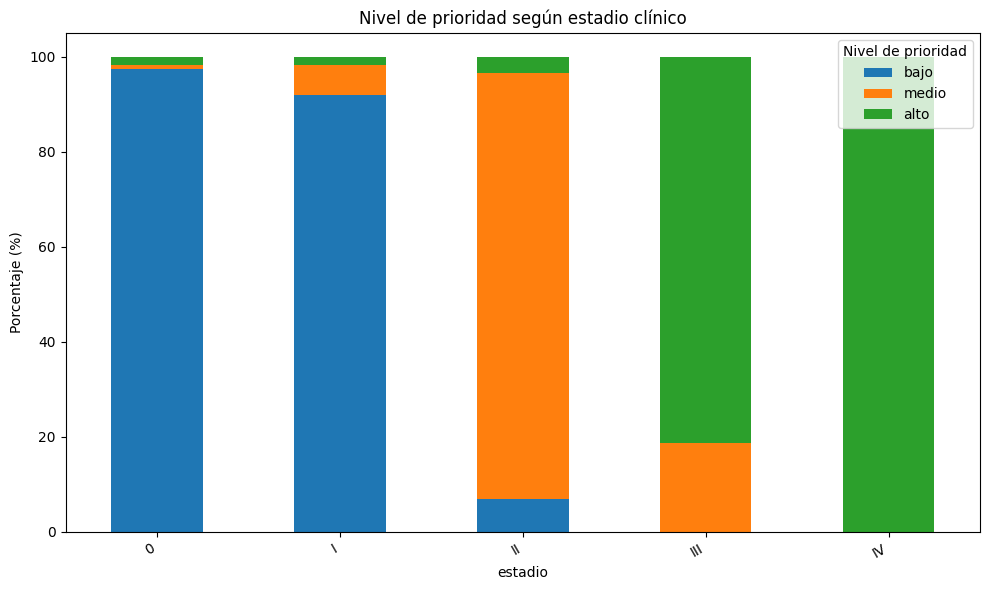

In [103]:
grafico_bivariado_apilado(
    df=df_eda,
    variable="estadio",
    titulo="Nivel de prioridad según estadio clínico",
    nombre_archivo="eda_14_estadio_vs_prioridad.png",
    orden_filas=["0", "I", "II", "III", "IV"]
)

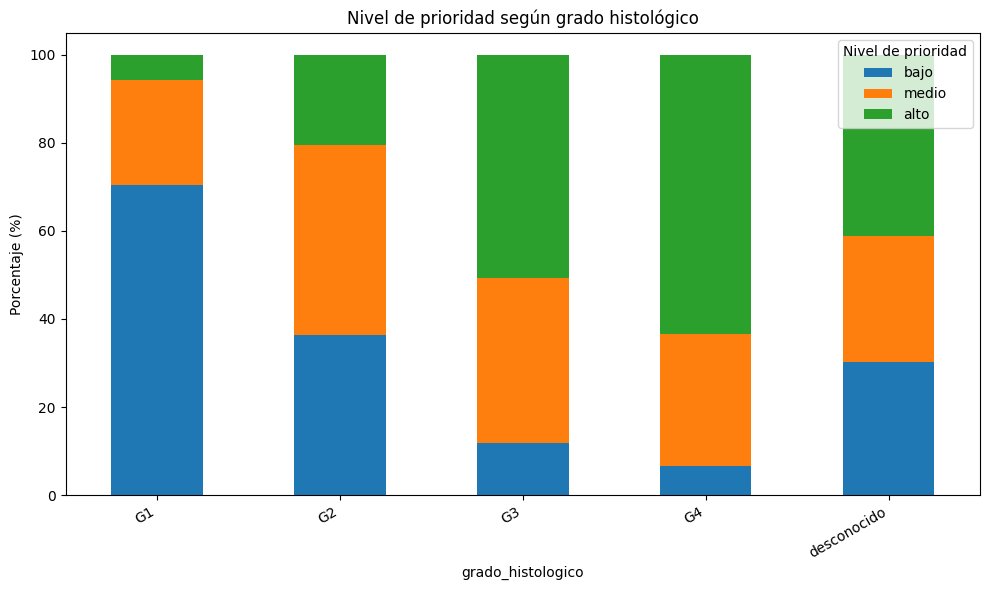

In [104]:
grafico_bivariado_apilado(
    df=df_eda,
    variable="grado_histologico",
    titulo="Nivel de prioridad según grado histológico",
    nombre_archivo="eda_14_grado_histologico_vs_prioridad.png",
    orden_filas=["G1", "G2", "G3", "G4", "desconocido"]
)

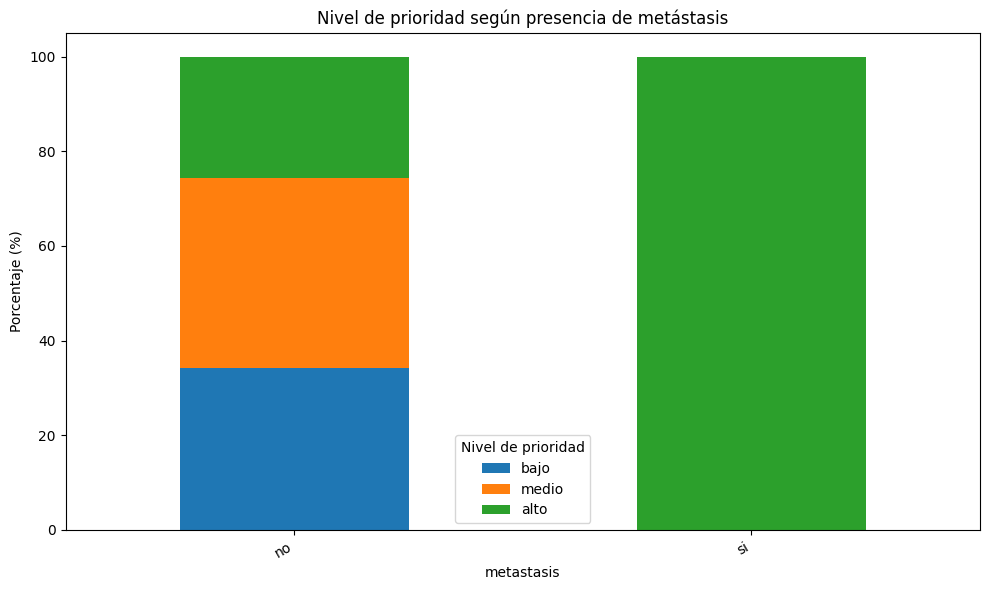

In [105]:
grafico_bivariado_apilado(
    df=df_eda,
    variable="metastasis",
    titulo="Nivel de prioridad según presencia de metástasis",
    nombre_archivo="eda_14_metastasis_vs_prioridad.png",
    orden_filas=["no", "si"]
)

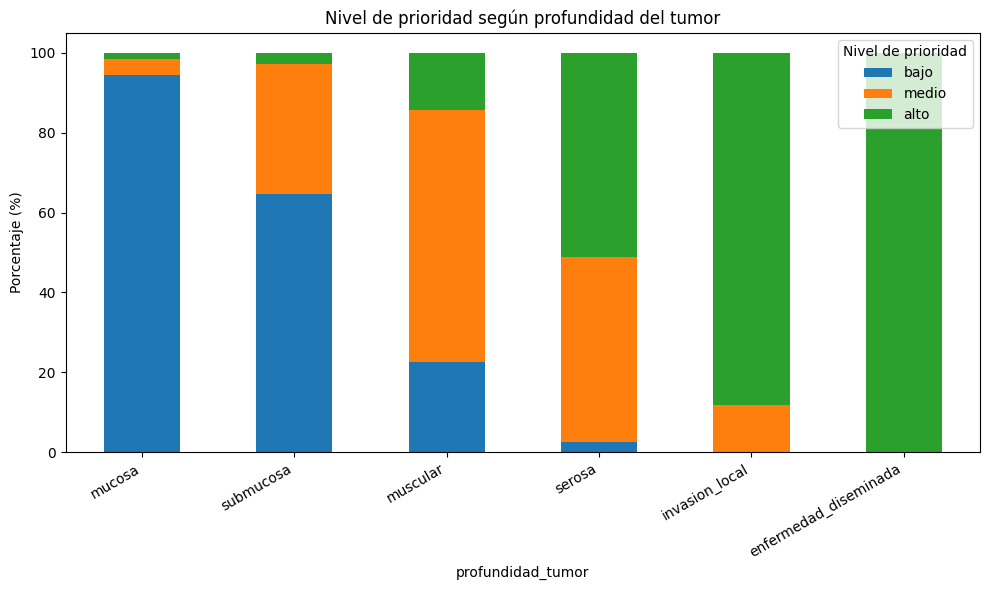

In [106]:
grafico_bivariado_apilado(
    df=df_eda,
    variable="profundidad_tumor",
    titulo="Nivel de prioridad según profundidad del tumor",
    nombre_archivo="eda_14_profundidad_tumor_vs_prioridad.png",
    orden_filas=[
        "mucosa",
        "submucosa",
        "muscular",
        "serosa",
        "invasion_local",
        "enfermedad_diseminada"
    ]
)

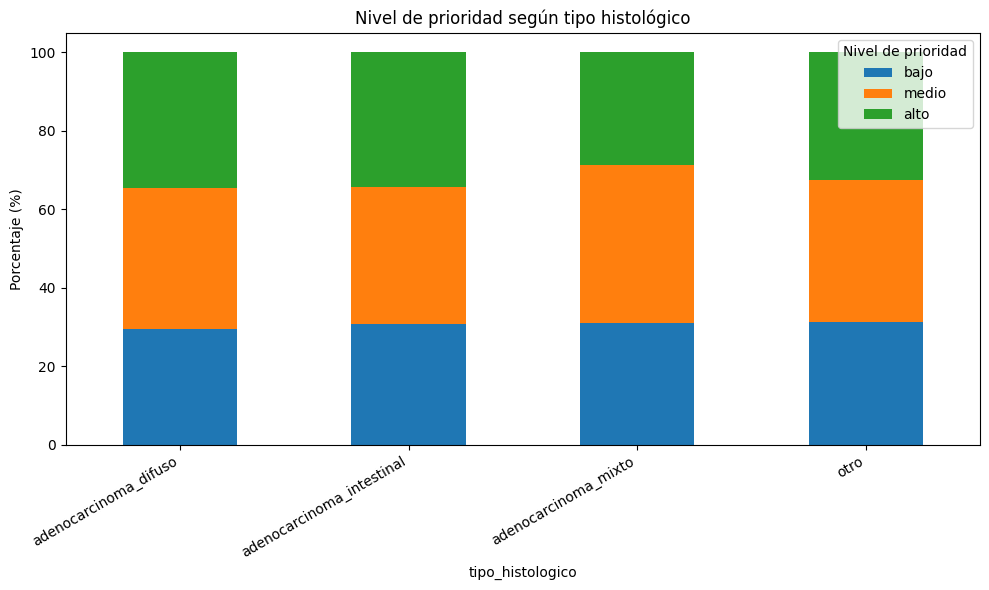

In [107]:
grafico_bivariado_apilado(
    df=df_eda,
    variable="tipo_histologico",
    titulo="Nivel de prioridad según tipo histológico",
    nombre_archivo="eda_14_tipo_histologico_vs_prioridad.png"
)

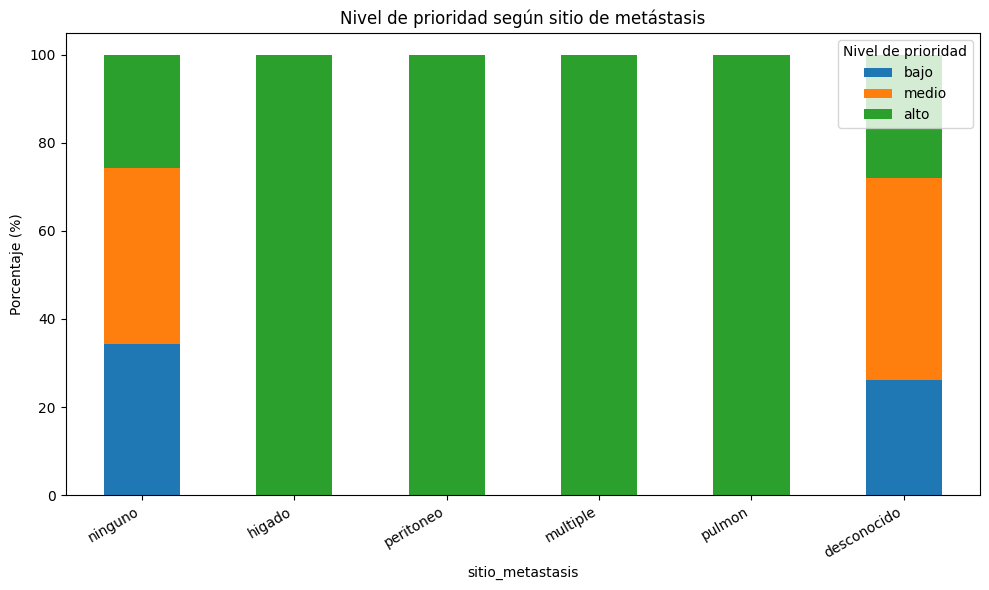

In [108]:
grafico_bivariado_apilado(
    df=df_eda,
    variable="sitio_metastasis",
    titulo="Nivel de prioridad según sitio de metástasis",
    nombre_archivo="eda_14_sitio_metastasis_vs_prioridad.png",
    orden_filas=[
        "ninguno",
        "higado",
        "peritoneo",
        "multiple",
        "pulmon",
        "desconocido"
    ]
)

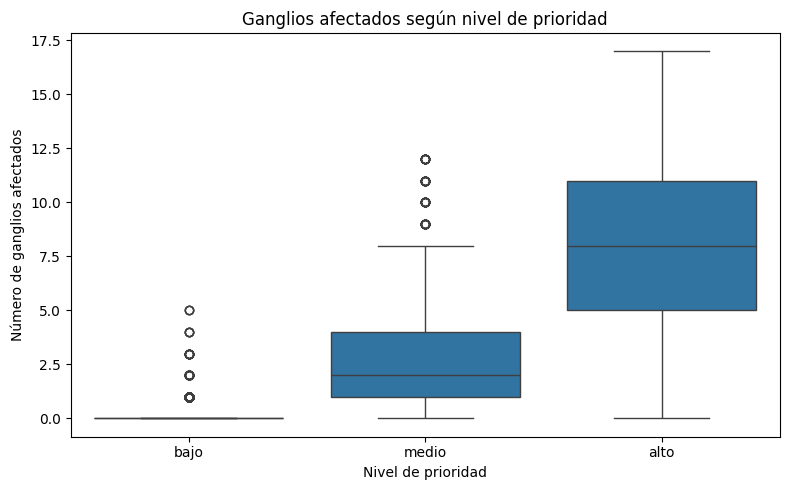

In [109]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_eda,
    x="nivel_prioridad",
    y="ganglios_afectados",
    order=orden_prioridad
)
plt.title("Ganglios afectados según nivel de prioridad")
plt.xlabel("Nivel de prioridad")
plt.ylabel("Número de ganglios afectados")
plt.tight_layout()
plt.savefig("eda_14_ganglios_vs_prioridad_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

In [110]:
print("--- Ganglios afectados según nivel de prioridad ---")

resumen_ganglios_prioridad = (
    df_eda
    .groupby("nivel_prioridad")["ganglios_afectados"]
    .describe()
    .loc[orden_prioridad]
)

display(resumen_ganglios_prioridad)

--- Ganglios afectados según nivel de prioridad ---


,count,mean,std,min,25%,50%,75%,max
nivel_prioridad,,,,,,,,
bajo,1520.0,0.188816,0.554359,0.0,0.0,0.0,0.0,5.0
medio,1790.0,2.520112,2.485821,0.0,1.0,2.0,4.0,12.0
alto,1690.0,7.835503,4.042277,0.0,5.0,8.0,11.0,17.0


In [113]:
def cramers_v(x, y):
    tabla = pd.crosstab(x, y)
    chi2 = chi2_contingency(tabla)[0]
    n = tabla.sum().sum()
    r, k = tabla.shape

    if n == 0 or min(k - 1, r - 1) == 0:
        return np.nan

    return np.sqrt((chi2 / n) / min(k - 1, r - 1))

resultados_cramers = []

for col in variables_clinicas_categoricas_bivariadas:
    x = df_eda[col].astype("object").fillna("desconocido")
    y = df_eda["nivel_prioridad"]

    valor = cramers_v(x, y)

    resultados_cramers.append({
        "variable": col,
        "cramers_v": round(valor, 3)
    })

df_cramers_clinicas = pd.DataFrame(resultados_cramers).sort_values(
    by="cramers_v",
    ascending=False
)

display(df_cramers_clinicas)

,variable,cramers_v
1,estadio,0.856
3,profundidad_tumor,0.650
4,metastasis,0.494
2,grado_histologico,0.390
5,sitio_metastasis,0.346
0,tipo_histologico,0.031


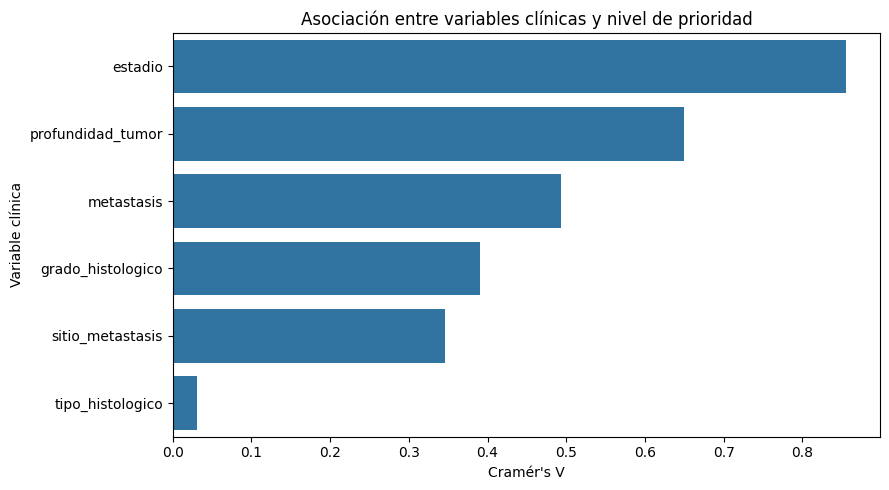

In [114]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=df_cramers_clinicas,
    x="cramers_v",
    y="variable"
)
plt.title("Asociación entre variables clínicas y nivel de prioridad")
plt.xlabel("Cramér's V")
plt.ylabel("Variable clínica")
plt.tight_layout()
plt.savefig("eda_14_cramers_clinicas_prioridad.png", dpi=300, bbox_inches="tight")
plt.show()

## Análisis de la Etapa 14

El análisis bivariado entre variables clínicas y nivel_prioridad muestra una relación clara entre la severidad oncológica y la prioridad de atención.

La variable con mayor asociación fue estadio, con un Cramér’s V = 0.856, lo cual indica una relación muy fuerte con nivel_prioridad. El patrón es clínicamente coherente: los estadios 0 e I se concentran casi totalmente en prioridad baja, el estadio II se concentra principalmente en prioridad media, mientras que los estadios III y IV se concentran en prioridad alta. En particular, el estadio IV aparece con 100% de prioridad alta.

La segunda variable más importante fue profundidad_tumor, con Cramér’s V = 0.650. Se observa que las categorías tempranas como mucosa y submucosa se asocian más con prioridad baja, mientras que serosa, invasion_local y enfermedad_diseminada aumentan claramente la proporción de prioridad alta.

La variable metastasis también presenta una relación fuerte con la prioridad, con Cramér’s V = 0.494. Todos los casos con metástasis se ubican en prioridad alta, lo cual es coherente porque la metástasis representa enfermedad avanzada.

En grado_histologico, el valor de Cramér’s V = 0.390 indica una asociación moderada. Se observa que G1 se asocia principalmente con prioridad baja, mientras que G3 y G4 presentan mayor concentración en prioridad alta. Esto indica que el grado histológico ayuda a complementar el estadio clínico.

La variable sitio_metastasis tiene una asociación moderada con la prioridad, con Cramér’s V = 0.346. Los sitios como hígado, peritoneo, pulmón o múltiples sitios se concentran en prioridad alta, lo cual es esperable porque dependen de la presencia de metástasis.

En cambio, tipo_histologico tiene una asociación muy baja con la prioridad, con Cramér’s V = 0.031. Esto indica que, por sí sola, esta variable no diferencia mucho entre prioridad baja, media o alta.

En la variable numérica ganglios_afectados, se observa un aumento progresivo según la prioridad. Los pacientes de prioridad baja tienen una media de 0.19 ganglios afectados, los de prioridad media 2.52, y los de prioridad alta 7.84. Este comportamiento confirma que la afectación ganglionar es una variable clínica relevante para explicar mayor prioridad.

El análisis bivariado clínico evidencia que las variables más relacionadas con el nivel_prioridad son estadio, profundidad_tumor, metastasis, grado_histologico, sitio_metastasis y ganglios_afectados. Estos resultados confirman que la prioridad de atención está fuertemente asociada con la progresión y severidad del cáncer gástrico. Para el informe y PPT, los gráficos más importantes son: estadio vs prioridad, profundidad del tumor vs prioridad, ganglios afectados vs prioridad y Cramér’s V de variables clínicas.


## 15. Análisis bivariado de síntomas vs nivel_prioridad

In [115]:
orden_prioridad = ["bajo", "medio", "alto"]

variables_sintomas_categoricas_bivariadas = [
    "estado_nutricional",
    "anemia",
    "dolor",
    "vomitos_frecuentes",
    "sangrado_digestivo",
    "fatiga",
    "dificultad_alimentarse",
    "comorbilidades",
    "estado_funcional"
]

variables_sintomas_numericas_bivariadas = [
    "perdida_peso_kg",
    "hemoglobina"
]

print("--- VARIABLES CATEGÓRICAS DE SÍNTOMAS ---")
print(variables_sintomas_categoricas_bivariadas)

print("\n--- VARIABLES NUMÉRICAS DE SÍNTOMAS ---")
print(variables_sintomas_numericas_bivariadas)

--- VARIABLES CATEGÓRICAS DE SÍNTOMAS ---
['estado_nutricional', 'anemia', 'dolor', 'vomitos_frecuentes', 'sangrado_digestivo', 'fatiga', 'dificultad_alimentarse', 'comorbilidades', 'estado_funcional']

--- VARIABLES NUMÉRICAS DE SÍNTOMAS ---
['perdida_peso_kg', 'hemoglobina']


In [116]:
def tabla_cruzada_porcentual(df, variable, objetivo="nivel_prioridad", orden_filas=None):
    serie_variable = df[variable].astype("object").fillna("desconocido")

    tabla = pd.crosstab(
        serie_variable,
        df[objetivo],
        normalize="index"
    ) * 100

    tabla = tabla.reindex(columns=orden_prioridad)

    if orden_filas is not None:
        filas_existentes = [fila for fila in orden_filas if fila in tabla.index]
        tabla = tabla.reindex(filas_existentes)

    return tabla.round(2)


ordenes_sintomas = {
    "estado_nutricional": ["adecuado", "riesgo", "desnutricion"],
    "anemia": ["no", "si"],
    "dolor": ["bajo", "medio", "alto"],
    "vomitos_frecuentes": ["no", "si"],
    "sangrado_digestivo": ["no", "si"],
    "fatiga": ["baja", "media", "alta"],
    "dificultad_alimentarse": ["no", "si"],
    "comorbilidades": ["ninguna", "una", "multiples"],
    "estado_funcional": ["bueno", "limitado", "dependiente", "desconocido"]
}

for col in variables_sintomas_categoricas_bivariadas:
    print(f"\n--- Distribución porcentual de nivel_prioridad según {col} ---")

    orden = ordenes_sintomas.get(col, None)

    display(
        tabla_cruzada_porcentual(
            df=df_eda,
            variable=col,
            objetivo="nivel_prioridad",
            orden_filas=orden
        )
    )


--- Distribución porcentual de nivel_prioridad según estado_nutricional ---


nivel_prioridad,bajo,medio,alto
estado_nutricional,,,
adecuado,55.30,36.23,8.46
riesgo,22.48,41.25,36.26
desnutricion,5.64,22.85,71.51



--- Distribución porcentual de nivel_prioridad según anemia ---


nivel_prioridad,bajo,medio,alto
anemia,,,
no,61.71,31.07,7.21
si,15.36,38.07,46.57



--- Distribución porcentual de nivel_prioridad según dolor ---


...

nivel_prioridad,bajo,medio,alto
dificultad_alimentarse,,,
no,40.59,35.89,23.52
si,14.82,35.66,49.52



--- Distribución porcentual de nivel_prioridad según comorbilidades ---


nivel_prioridad,bajo,medio,alto
comorbilidades,,,
ninguna,30.08,34.64,35.28
una,29.87,37.36,32.77
multiples,32.11,35.47,32.42



--- Distribución porcentual de nivel_prioridad según estado_funcional ---


nivel_prioridad,bajo,medio,alto
estado_funcional,,,
bueno,64.76,30.64,4.61
limitado,12.17,46.50,41.33
dependiente,0.00,11.40,88.60
desconocido,28.33,33.33,38.33


In [118]:
def grafico_bivariado_apilado(df, variable, titulo, nombre_archivo, orden_filas=None):
    serie_variable = df[variable].astype("object").fillna("desconocido")

    tabla = pd.crosstab(
        serie_variable,
        df["nivel_prioridad"],
        normalize="index"
    ) * 100

    tabla = tabla.reindex(columns=orden_prioridad)

    if orden_filas is not None:
        filas_existentes = [fila for fila in orden_filas if fila in tabla.index]
        tabla = tabla.reindex(filas_existentes)

    tabla.plot(
        kind="bar",
        stacked=True,
        figsize=(10, 6)
    )

    plt.title(titulo)
    plt.xlabel(variable)
    plt.ylabel("Porcentaje (%)")
    plt.legend(title="Nivel de prioridad")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig(nombre_archivo, dpi=300, bbox_inches="tight")
    plt.show()

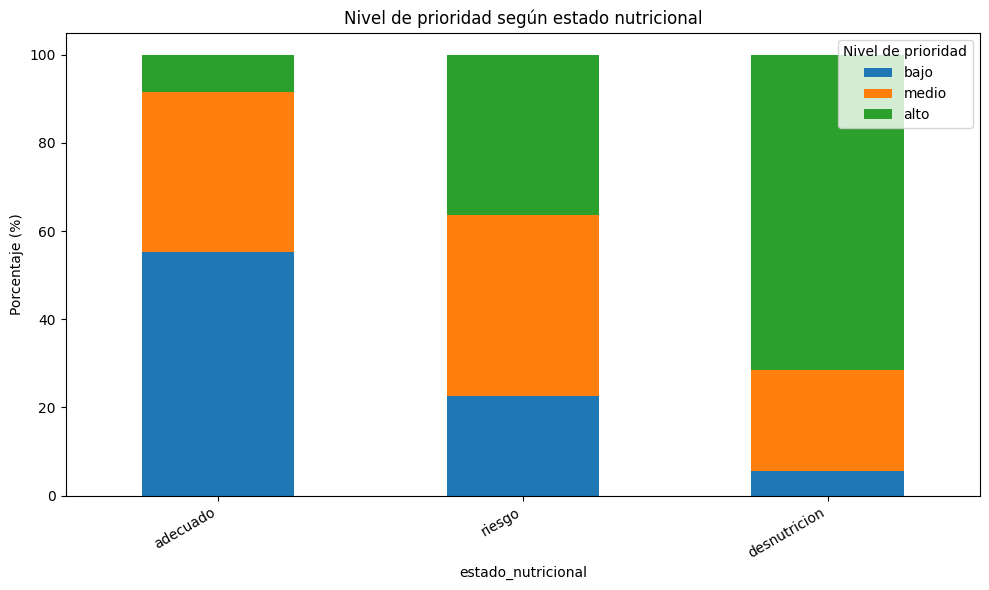

In [119]:
grafico_bivariado_apilado(
    df=df_eda,
    variable="estado_nutricional",
    titulo="Nivel de prioridad según estado nutricional",
    nombre_archivo="eda_15_estado_nutricional_vs_prioridad.png",
    orden_filas=["adecuado", "riesgo", "desnutricion"]
)

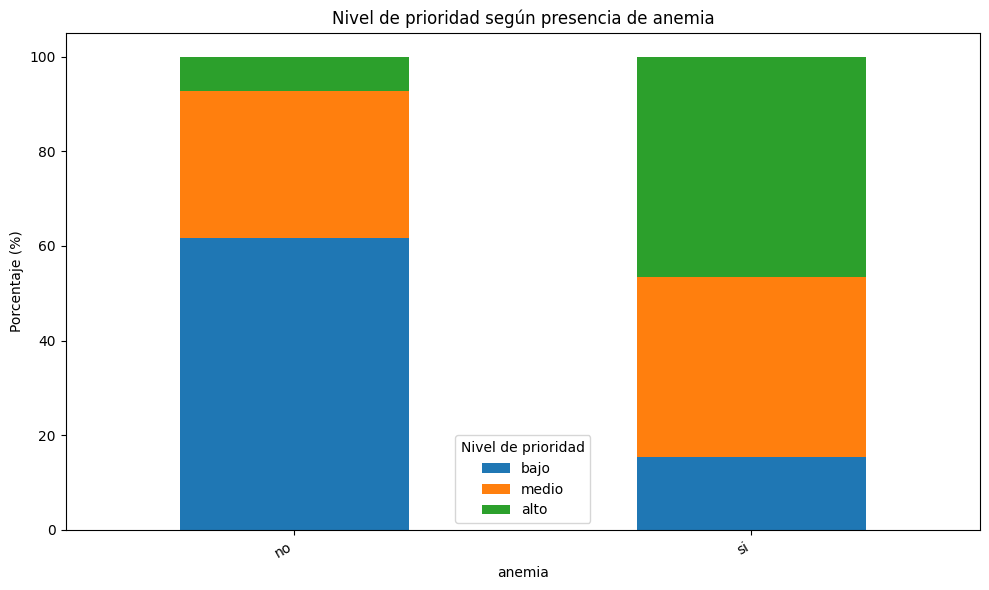

In [120]:
grafico_bivariado_apilado(
    df=df_eda,
    variable="anemia",
    titulo="Nivel de prioridad según presencia de anemia",
    nombre_archivo="eda_15_anemia_vs_prioridad.png",
    orden_filas=["no", "si"]
)

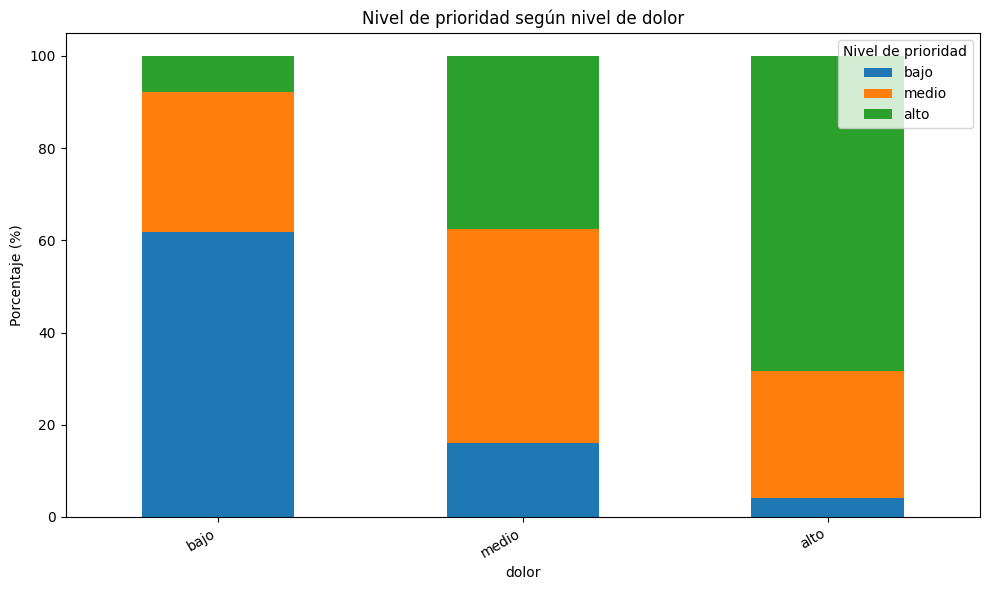

In [121]:
grafico_bivariado_apilado(
    df=df_eda,
    variable="dolor",
    titulo="Nivel de prioridad según nivel de dolor",
    nombre_archivo="eda_15_dolor_vs_prioridad.png",
    orden_filas=["bajo", "medio", "alto"]
)

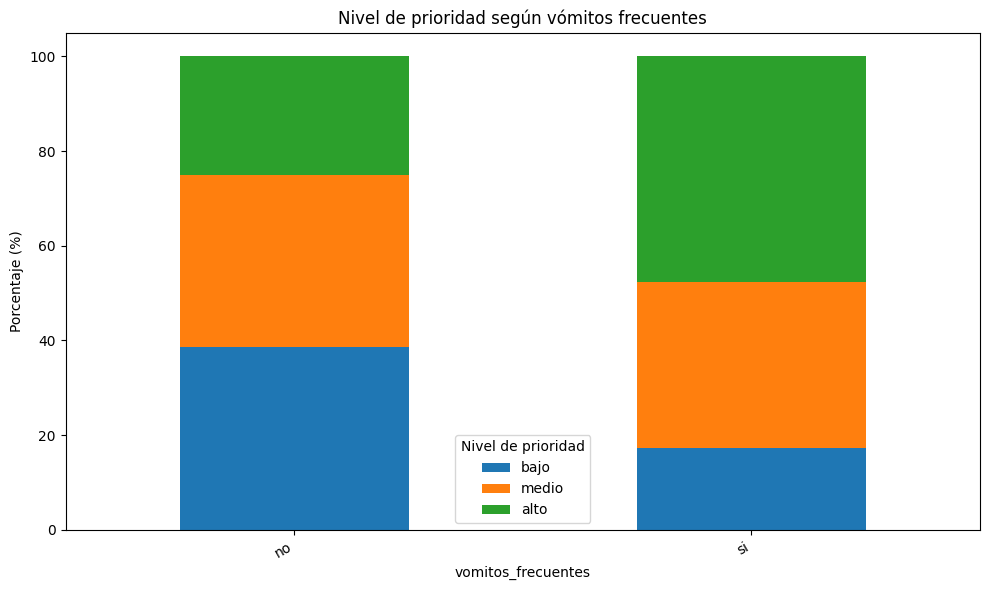

In [122]:
grafico_bivariado_apilado(
    df=df_eda,
    variable="vomitos_frecuentes",
    titulo="Nivel de prioridad según vómitos frecuentes",
    nombre_archivo="eda_15_vomitos_vs_prioridad.png",
    orden_filas=["no", "si"]
)

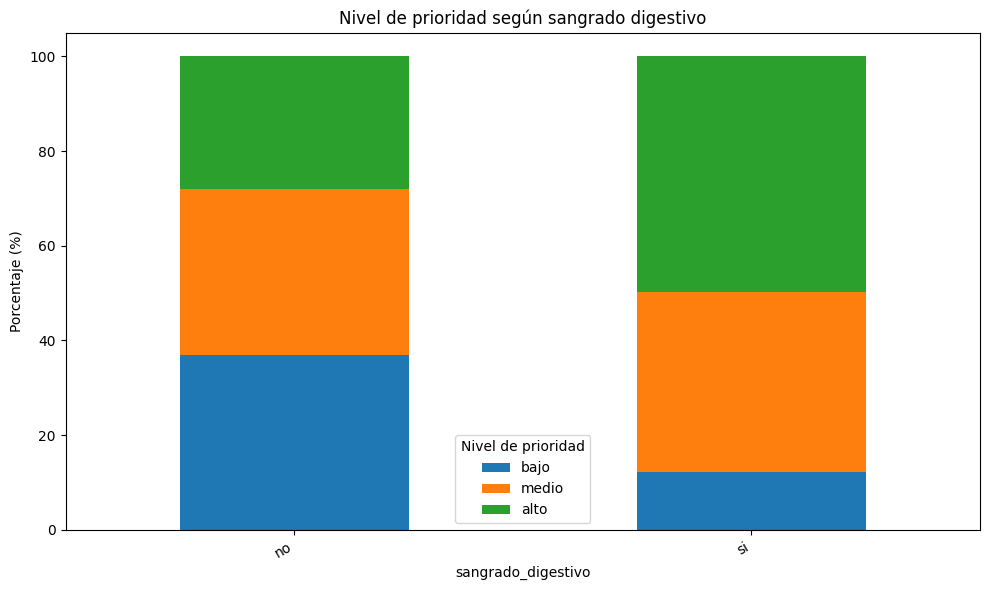

In [123]:
grafico_bivariado_apilado(
    df=df_eda,
    variable="sangrado_digestivo",
    titulo="Nivel de prioridad según sangrado digestivo",
    nombre_archivo="eda_15_sangrado_vs_prioridad.png",
    orden_filas=["no", "si"]
)

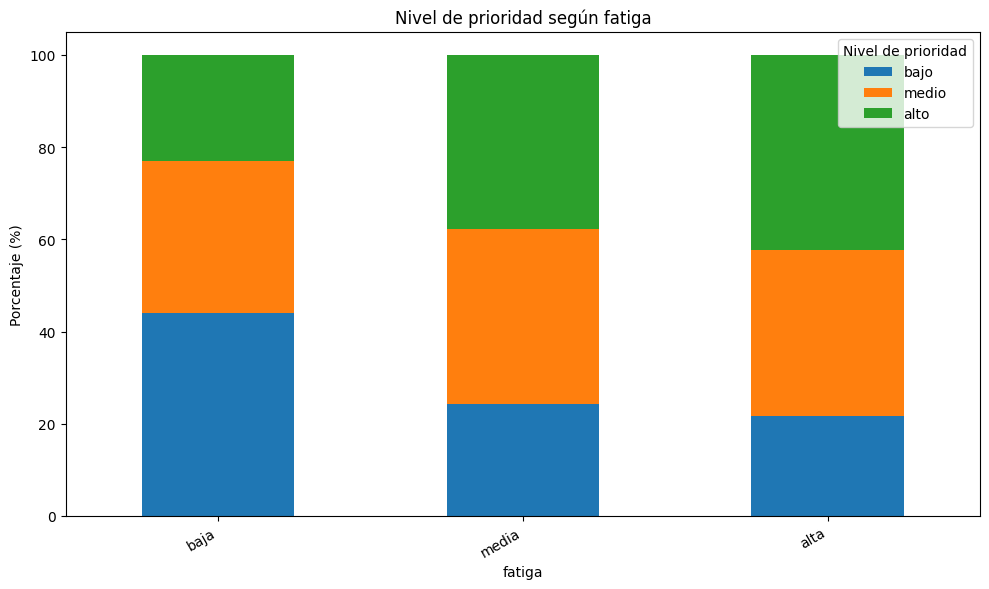

In [124]:
grafico_bivariado_apilado(
    df=df_eda,
    variable="fatiga",
    titulo="Nivel de prioridad según fatiga",
    nombre_archivo="eda_15_fatiga_vs_prioridad.png",
    orden_filas=["baja", "media", "alta"]
)

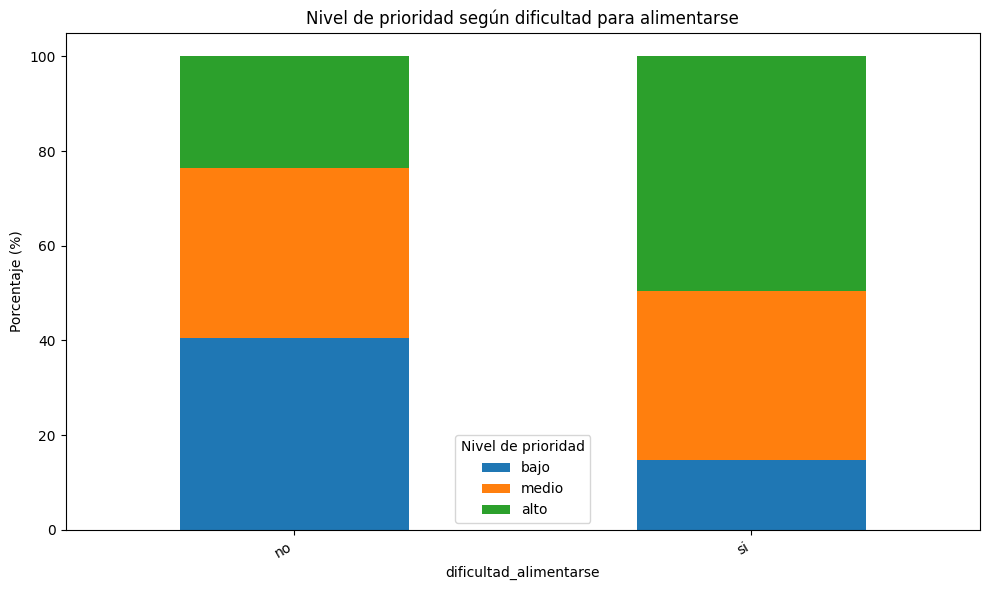

In [125]:
grafico_bivariado_apilado(
    df=df_eda,
    variable="dificultad_alimentarse",
    titulo="Nivel de prioridad según dificultad para alimentarse",
    nombre_archivo="eda_15_dificultad_alimentarse_vs_prioridad.png",
    orden_filas=["no", "si"]
)

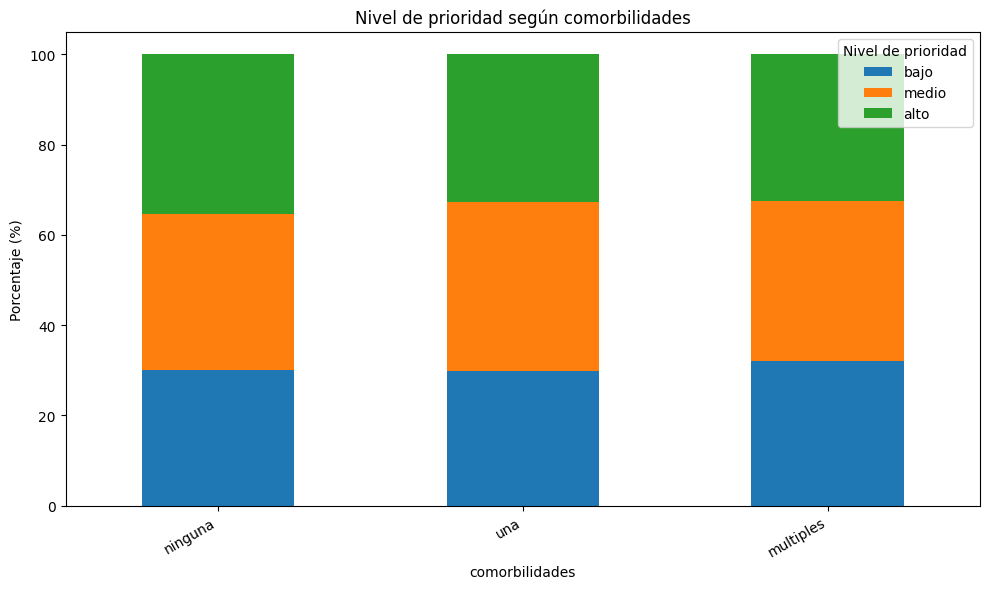

In [126]:
grafico_bivariado_apilado(
    df=df_eda,
    variable="comorbilidades",
    titulo="Nivel de prioridad según comorbilidades",
    nombre_archivo="eda_15_comorbilidades_vs_prioridad.png",
    orden_filas=["ninguna", "una", "multiples"]
)

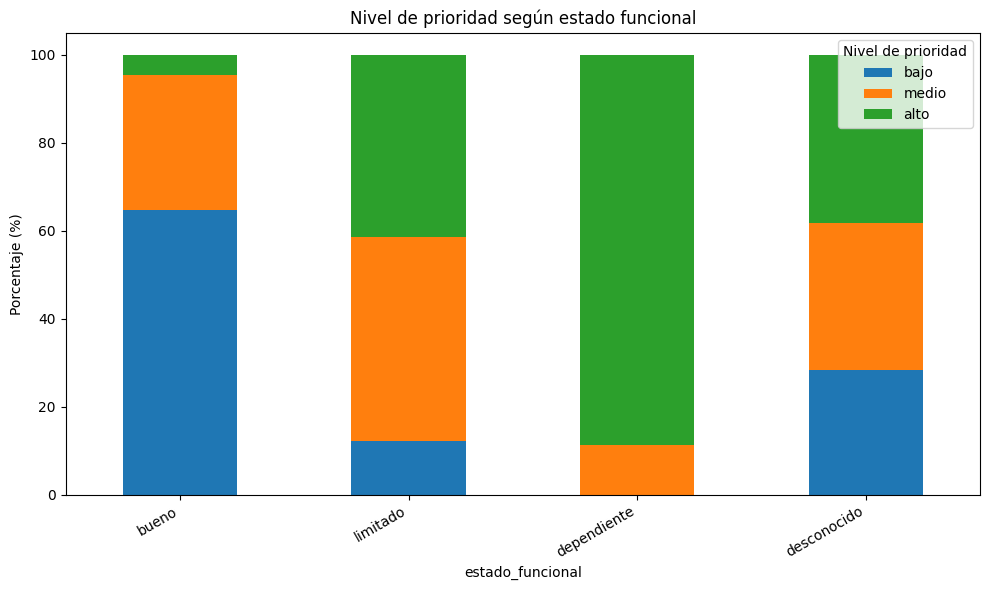

In [127]:
grafico_bivariado_apilado(
    df=df_eda,
    variable="estado_funcional",
    titulo="Nivel de prioridad según estado funcional",
    nombre_archivo="eda_15_estado_funcional_vs_prioridad.png",
    orden_filas=["bueno", "limitado", "dependiente", "desconocido"]
)

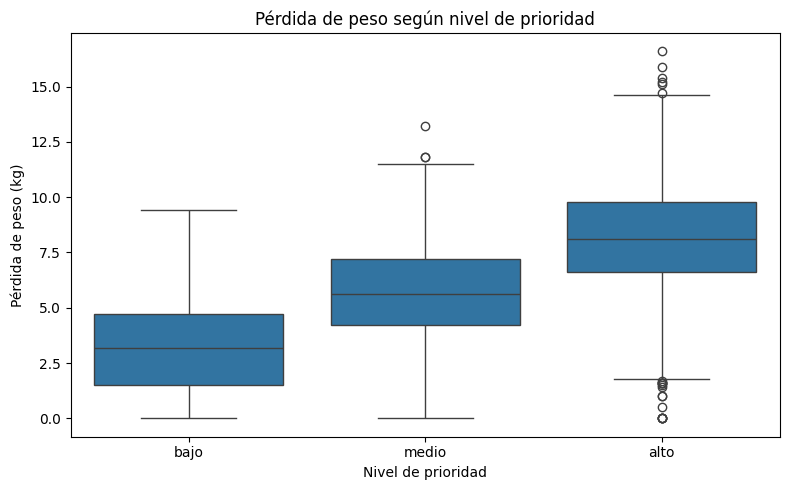

In [128]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_eda,
    x="nivel_prioridad",
    y="perdida_peso_kg",
    order=orden_prioridad
)
plt.title("Pérdida de peso según nivel de prioridad")
plt.xlabel("Nivel de prioridad")
plt.ylabel("Pérdida de peso (kg)")
plt.tight_layout()
plt.savefig("eda_15_perdida_peso_vs_prioridad_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

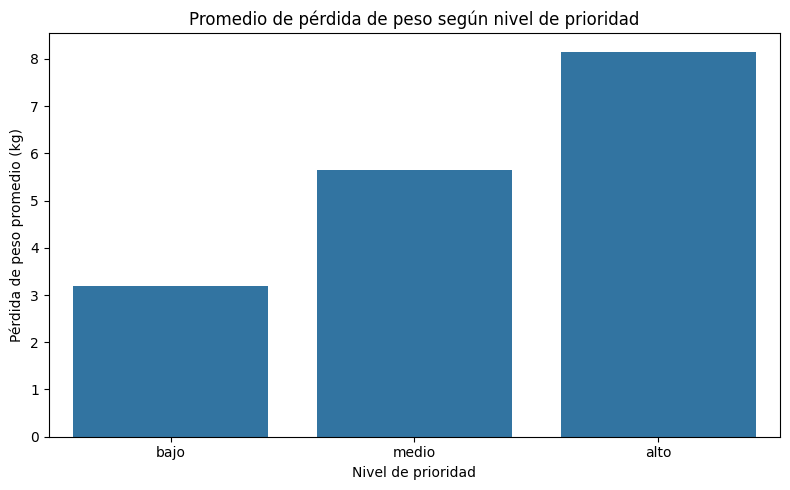

In [129]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=df_eda,
    x="nivel_prioridad",
    y="perdida_peso_kg",
    order=orden_prioridad,
    estimator="mean",
    errorbar=None
)
plt.title("Promedio de pérdida de peso según nivel de prioridad")
plt.xlabel("Nivel de prioridad")
plt.ylabel("Pérdida de peso promedio (kg)")
plt.tight_layout()
plt.savefig("eda_15_promedio_perdida_peso_vs_prioridad.png", dpi=300, bbox_inches="tight")
plt.show()

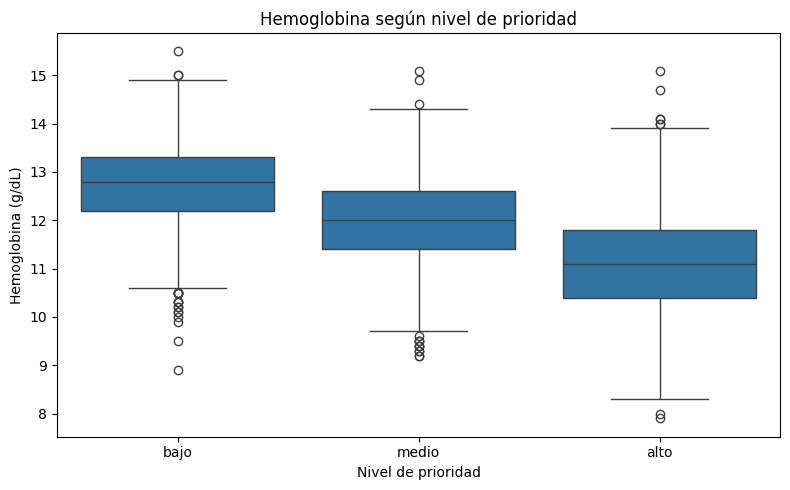

In [130]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_eda,
    x="nivel_prioridad",
    y="hemoglobina",
    order=orden_prioridad
)
plt.title("Hemoglobina según nivel de prioridad")
plt.xlabel("Nivel de prioridad")
plt.ylabel("Hemoglobina (g/dL)")
plt.tight_layout()
plt.savefig("eda_15_hemoglobina_vs_prioridad_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

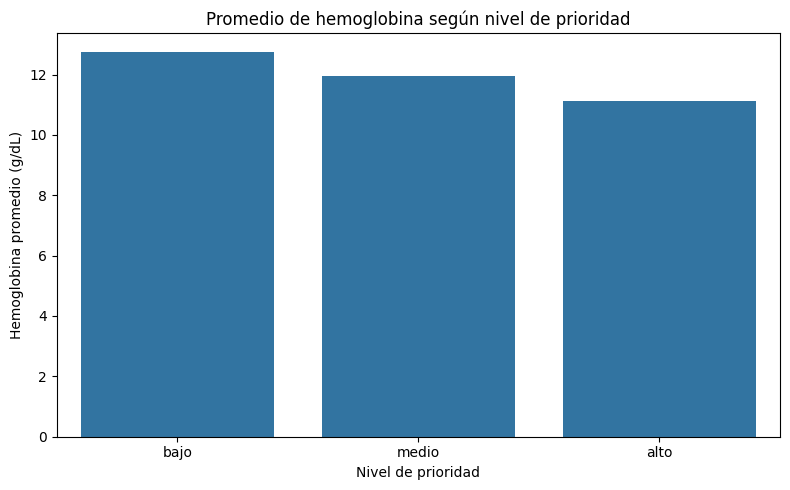

In [131]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=df_eda,
    x="nivel_prioridad",
    y="hemoglobina",
    order=orden_prioridad,
    estimator="mean",
    errorbar=None
)
plt.title("Promedio de hemoglobina según nivel de prioridad")
plt.xlabel("Nivel de prioridad")
plt.ylabel("Hemoglobina promedio (g/dL)")
plt.tight_layout()
plt.savefig("eda_15_promedio_hemoglobina_vs_prioridad.png", dpi=300, bbox_inches="tight")
plt.show()

In [132]:
print("--- Pérdida de peso según nivel de prioridad ---")
resumen_perdida_peso = (
    df_eda
    .groupby("nivel_prioridad")["perdida_peso_kg"]
    .describe()
    .loc[orden_prioridad]
)
display(resumen_perdida_peso)

print("--- Hemoglobina según nivel de prioridad ---")
resumen_hemoglobina = (
    df_eda
    .groupby("nivel_prioridad")["hemoglobina"]
    .describe()
    .loc[orden_prioridad]
)
display(resumen_hemoglobina)

--- Pérdida de peso según nivel de prioridad ---


,count,mean,std,min,25%,50%,75%,max
nivel_prioridad,,,,,,,,
bajo,1483.0,3.192650,2.110572,0.0,1.5,3.2,4.7,9.4
medio,1752.0,5.644863,2.188691,0.0,4.2,5.6,7.2,13.2
alto,1660.0,8.145060,2.403505,0.0,6.6,8.1,9.8,16.6


--- Hemoglobina según nivel de prioridad ---


,count,mean,std,min,25%,50%,75%,max
nivel_prioridad,,,,,,,,
bajo,1479.0,12.743340,0.898801,8.9,12.2,12.8,13.3,15.5
medio,1740.0,11.947874,0.902065,9.2,11.4,12.0,12.6,15.1
alto,1641.0,11.121938,1.043286,7.9,10.4,11.1,11.8,15.1


In [133]:
def cramers_v(x, y):
    tabla = pd.crosstab(x, y)
    chi2 = chi2_contingency(tabla)[0]
    n = tabla.sum().sum()
    r, k = tabla.shape

    if n == 0 or min(k - 1, r - 1) == 0:
        return np.nan

    return np.sqrt((chi2 / n) / min(k - 1, r - 1))


resultados_cramers_sintomas = []

for col in variables_sintomas_categoricas_bivariadas:
    x = df_eda[col].astype("object").fillna("desconocido")
    y = df_eda["nivel_prioridad"]

    valor = cramers_v(x, y)

    resultados_cramers_sintomas.append({
        "variable": col,
        "cramers_v": round(valor, 3)
    })

df_cramers_sintomas = pd.DataFrame(resultados_cramers_sintomas).sort_values(
    by="cramers_v",
    ascending=False
)

display(df_cramers_sintomas)

,variable,cramers_v
1,anemia,0.508
8,estado_funcional,0.499
2,dolor,0.437
0,estado_nutricional,0.378
6,dificultad_alimentarse,0.316
3,vomitos_frecuentes,0.269
4,sangrado_digestivo,0.260
5,fatiga,0.161
7,comorbilidades,0.024


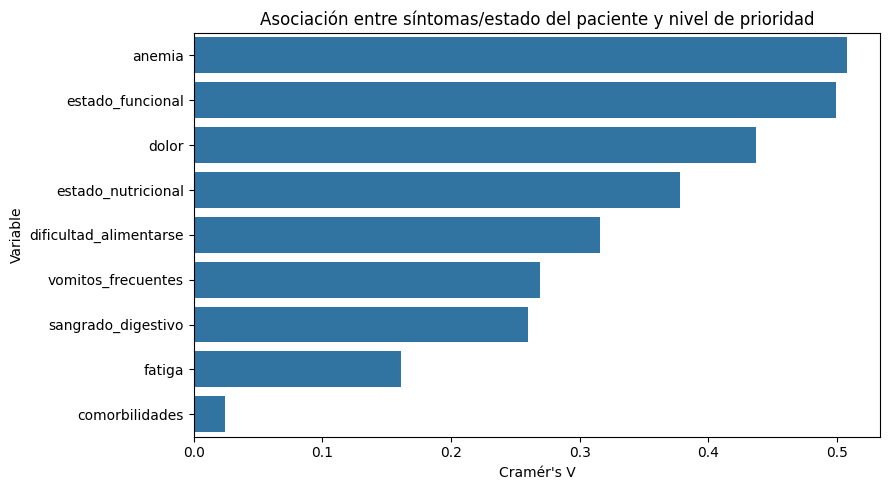

In [134]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=df_cramers_sintomas,
    x="cramers_v",
    y="variable"
)
plt.title("Asociación entre síntomas/estado del paciente y nivel de prioridad")
plt.xlabel("Cramér's V")
plt.ylabel("Variable")
plt.tight_layout()
plt.savefig("eda_15_cramers_sintomas_prioridad.png", dpi=300, bbox_inches="tight")
plt.show()

## Análisis de la Etapa 15

El análisis bivariado muestra que varias variables clínicas del estado del paciente se asocian claramente con la prioridad de atención.

La variable con mayor asociación fue anemia, con Cramér’s V = 0.508. Los pacientes sin anemia se concentran principalmente en prioridad baja, con 61.71%, mientras que los pacientes con anemia presentan mayor proporción de prioridad alta, con 46.57%. Esto indica que la anemia es una variable importante para diferenciar pacientes con mayor riesgo.

La segunda variable más importante fue estado_funcional, con Cramér’s V = 0.499. Los pacientes con estado funcional bueno se concentran en prioridad baja, con 64.76%, mientras que los pacientes dependientes se concentran fuertemente en prioridad alta, con 88.60%. Esto es coherente porque un paciente dependiente requiere más apoyo y vigilancia.

La variable dolor también muestra una asociación relevante, con Cramér’s V = 0.437. Cuando el dolor es bajo, predomina la prioridad baja; en cambio, cuando el dolor es alto, el 68.35% de los casos pertenece a prioridad alta.

En estado_nutricional, el patrón también es claro. Los pacientes con estado nutricional adecuado tienen mayor proporción de prioridad baja, mientras que los pacientes con desnutricion presentan 71.51% de prioridad alta. Esto confirma que el deterioro nutricional es un factor importante en la clasificación.

Las variables dificultad_alimentarse, vomitos_frecuentes y sangrado_digestivo también muestran relación con prioridad alta. Por ejemplo, cuando existe dificultad para alimentarse, la prioridad alta sube a 49.52%. Cuando hay vómitos frecuentes, la prioridad alta llega a 47.74%, y cuando hay sangrado digestivo, llega a 49.70%.

En las variables numéricas, la relación es bastante clara. La pérdida de peso promedio aumenta según la prioridad: prioridad baja tiene 3.19 kg, prioridad media 5.64 kg y prioridad alta 8.15 kg. Esto indica que los pacientes de mayor prioridad tienden a presentar mayor deterioro nutricional.

En cambio, la hemoglobina promedio disminuye conforme aumenta la prioridad: prioridad baja tiene 12.74 g/dL, prioridad media 11.95 g/dL y prioridad alta 11.12 g/dL. Esto refuerza la relación entre anemia, deterioro clínico y prioridad alta.

La única variable con asociación muy baja fue comorbilidades, con Cramér’s V = 0.024. Esto significa que, en este dataset, tener ninguna, una o múltiples comorbilidades no cambia mucho la distribución del nivel de prioridad.

El análisis bivariado de síntomas y estado del paciente confirma que variables como anemia, estado_funcional, dolor, estado_nutricional, dificultad_alimentarse, vomitos_frecuentes, sangrado_digestivo, perdida_peso_kg y hemoglobina tienen una relación importante con el nivel_prioridad. Estas variables serán relevantes para el modelado porque ayudan a diferenciar pacientes de prioridad baja, media y alta. En cambio, comorbilidades presenta una asociación muy débil, por lo que probablemente tendrá menor aporte predictivo.

## 16. Análisis bivariado de tratamiento vs nivel_prioridad

In [135]:
orden_prioridad = ["bajo", "medio", "alto"]

variables_tratamiento_bivariadas = [
    "requiere_cirugia",
    "requiere_quimioterapia",
    "requiere_soporte_nutricional",
    "requiere_cuidados_paliativos",
    "tratamiento_principal"
]

print("--- VARIABLES DE TRATAMIENTO PARA ANÁLISIS BIVARIADO ---")
print(variables_tratamiento_bivariadas)

--- VARIABLES DE TRATAMIENTO PARA ANÁLISIS BIVARIADO ---
['requiere_cirugia', 'requiere_quimioterapia', 'requiere_soporte_nutricional', 'requiere_cuidados_paliativos', 'tratamiento_principal']


In [136]:
def tabla_cruzada_porcentual(df, variable, objetivo="nivel_prioridad", orden_filas=None):
    serie_variable = df[variable].astype("object").fillna("desconocido")

    tabla = pd.crosstab(
        serie_variable,
        df[objetivo],
        normalize="index"
    ) * 100

    tabla = tabla.reindex(columns=orden_prioridad)

    if orden_filas is not None:
        filas_existentes = [fila for fila in orden_filas if fila in tabla.index]
        tabla = tabla.reindex(filas_existentes)

    return tabla.round(2)


ordenes_tratamiento = {
    "requiere_cirugia": ["no", "si"],
    "requiere_quimioterapia": ["no", "si"],
    "requiere_soporte_nutricional": ["no", "si"],
    "requiere_cuidados_paliativos": ["no", "si"],
    "tratamiento_principal": [
        "seguimiento",
        "cirugia",
        "cirugia_quimioterapia",
        "quimioterapia",
        "soporte_nutricional",
        "cuidados_paliativos"
    ]
}

for col in variables_tratamiento_bivariadas:
    print(f"\n--- Distribución porcentual de nivel_prioridad según {col} ---")

    display(
        tabla_cruzada_porcentual(
            df=df_eda,
            variable=col,
            objetivo="nivel_prioridad",
            orden_filas=ordenes_tratamiento.get(col)
        )
    )


--- Distribución porcentual de nivel_prioridad según requiere_cirugia ---


nivel_prioridad,bajo,medio,alto
requiere_cirugia,,,
no,14.33,29.05,56.62
si,41.27,40.36,18.37



--- Distribución porcentual de nivel_prioridad según requiere_quimioterapia ---


nivel_prioridad,bajo,medio,alto
requiere_quimioterapia,,,
no,53.90,29.77,16.33
si,5.15,42.28,52.57



--- Distribución porcentual de nivel_prioridad según requiere_soporte_nutricional ---


nivel_prioridad,bajo,medio,alto
requiere_soporte_nutricional,,,
no,55.66,35.94,8.40
si,19.20,35.74,45.06



--- Distribución porcentual de nivel_prioridad según requiere_cuidados_paliativos ---


nivel_prioridad,bajo,medio,alto
requiere_cuidados_paliativos,,,
no,35.16,38.14,26.69
si,0.00,20.83,79.17



--- Distribución porcentual de nivel_prioridad según tratamiento_principal ---


nivel_prioridad,bajo,medio,alto
tratamiento_principal,,,
seguimiento,60.54,34.53,4.93
cirugia,65.19,29.69,5.12
cirugia_quimioterapia,9.53,59.24,31.23
quimioterapia,2.85,34.91,62.24
soporte_nutricional,30.26,30.50,39.24
cuidados_paliativos,0.00,20.83,79.17


In [137]:
def grafico_bivariado_apilado(df, variable, titulo, nombre_archivo, orden_filas=None):
    serie_variable = df[variable].astype("object").fillna("desconocido")

    tabla = pd.crosstab(
        serie_variable,
        df["nivel_prioridad"],
        normalize="index"
    ) * 100

    tabla = tabla.reindex(columns=orden_prioridad)

    if orden_filas is not None:
        filas_existentes = [fila for fila in orden_filas if fila in tabla.index]
        tabla = tabla.reindex(filas_existentes)

    tabla.plot(
        kind="bar",
        stacked=True,
        figsize=(10, 6)
    )

    plt.title(titulo)
    plt.xlabel(variable)
    plt.ylabel("Porcentaje (%)")
    plt.legend(title="Nivel de prioridad")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig(nombre_archivo, dpi=300, bbox_inches="tight")
    plt.show()

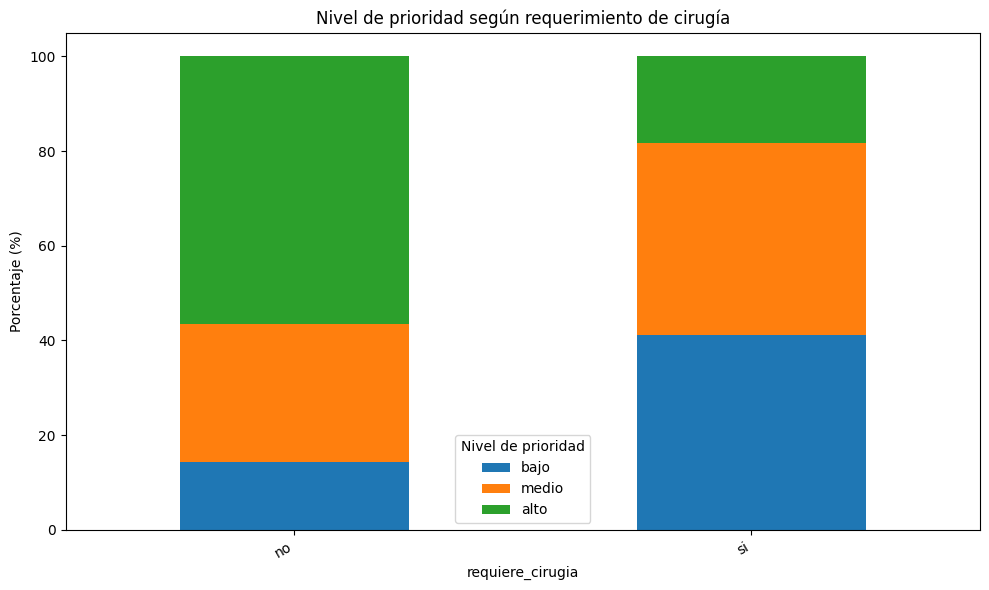

In [138]:
grafico_bivariado_apilado(
    df=df_eda,
    variable="requiere_cirugia",
    titulo="Nivel de prioridad según requerimiento de cirugía",
    nombre_archivo="eda_16_cirugia_vs_prioridad.png",
    orden_filas=["no", "si"]
)

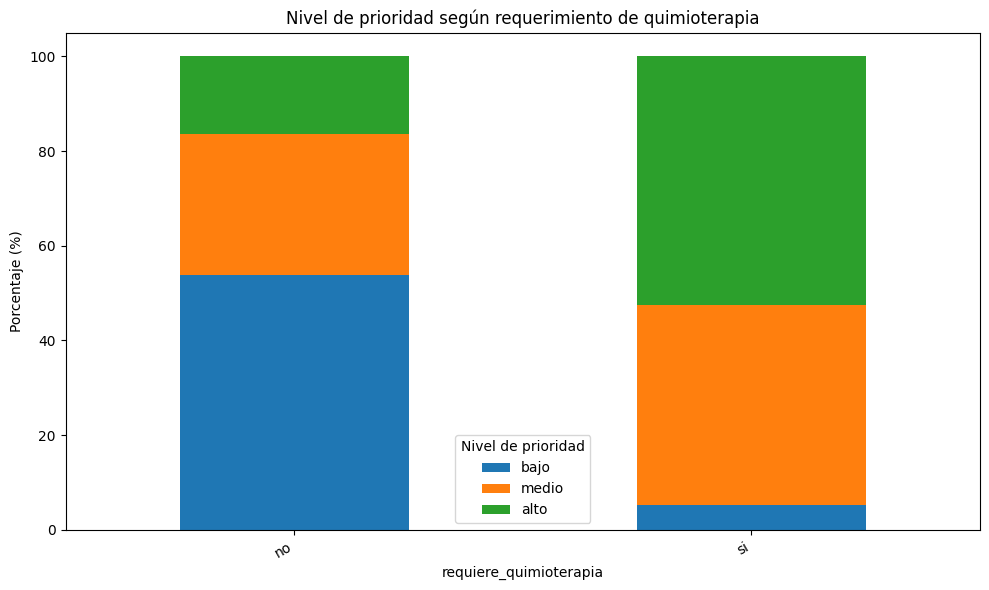

In [139]:
grafico_bivariado_apilado(
    df=df_eda,
    variable="requiere_quimioterapia",
    titulo="Nivel de prioridad según requerimiento de quimioterapia",
    nombre_archivo="eda_16_quimioterapia_vs_prioridad.png",
    orden_filas=["no", "si"]
)

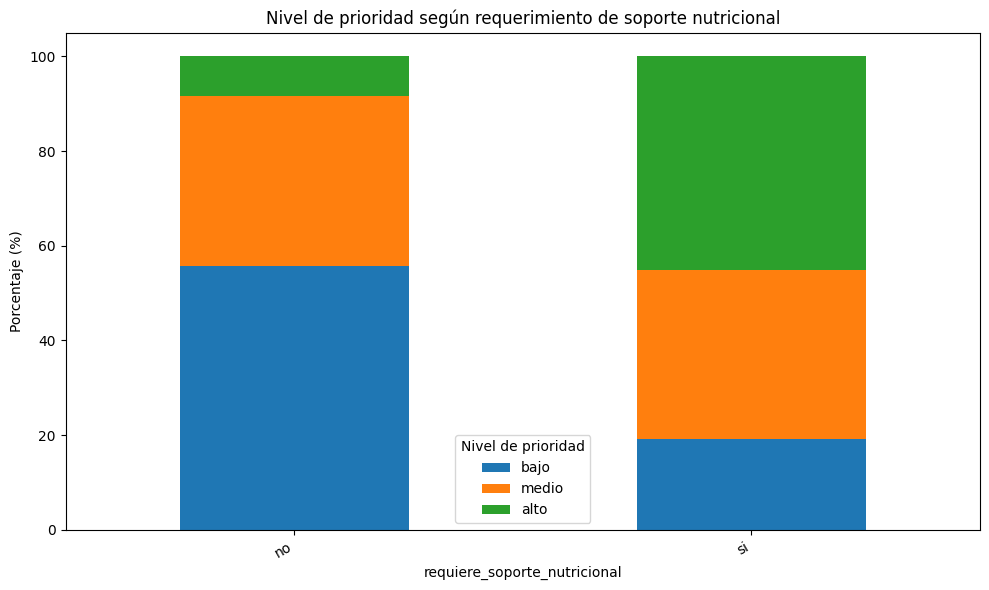

In [140]:
grafico_bivariado_apilado(
    df=df_eda,
    variable="requiere_soporte_nutricional",
    titulo="Nivel de prioridad según requerimiento de soporte nutricional",
    nombre_archivo="eda_16_soporte_nutricional_vs_prioridad.png",
    orden_filas=["no", "si"]
)

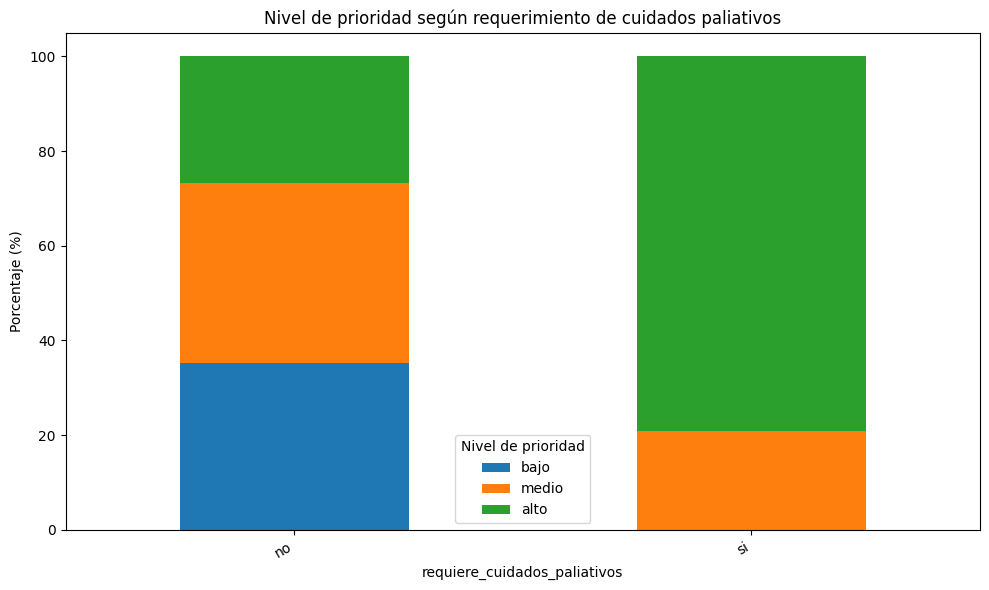

In [141]:
grafico_bivariado_apilado(
    df=df_eda,
    variable="requiere_cuidados_paliativos",
    titulo="Nivel de prioridad según requerimiento de cuidados paliativos",
    nombre_archivo="eda_16_cuidados_paliativos_vs_prioridad.png",
    orden_filas=["no", "si"]
)

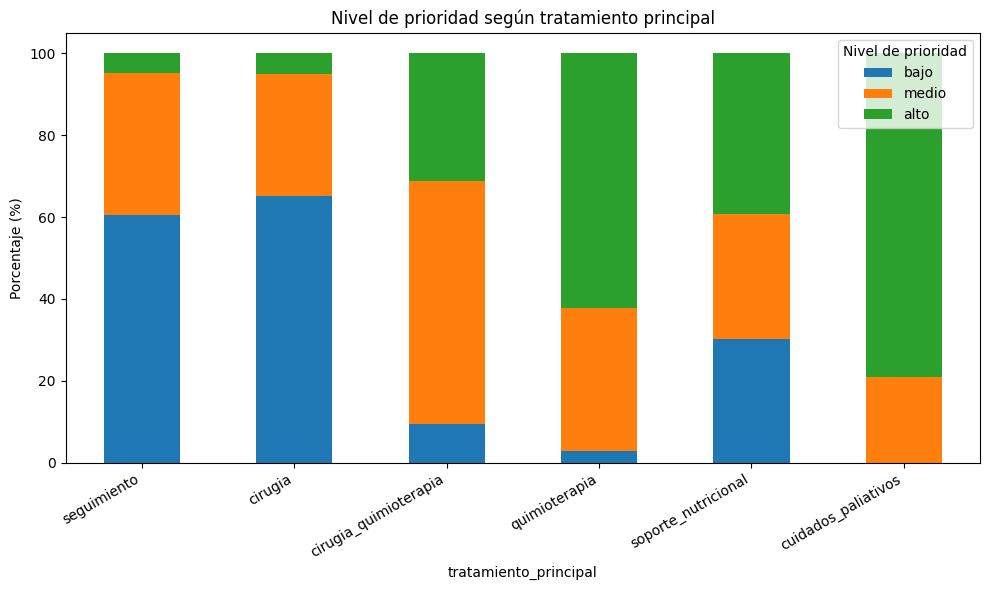

In [142]:
grafico_bivariado_apilado(
    df=df_eda,
    variable="tratamiento_principal",
    titulo="Nivel de prioridad según tratamiento principal",
    nombre_archivo="eda_16_tratamiento_principal_vs_prioridad.png",
    orden_filas=[
        "seguimiento",
        "cirugia",
        "cirugia_quimioterapia",
        "quimioterapia",
        "soporte_nutricional",
        "cuidados_paliativos"
    ]
)

In [143]:
def cramers_v(x, y):
    tabla = pd.crosstab(x, y)
    chi2 = chi2_contingency(tabla)[0]
    n = tabla.sum().sum()
    r, k = tabla.shape

    if n == 0 or min(k - 1, r - 1) == 0:
        return np.nan

    return np.sqrt((chi2 / n) / min(k - 1, r - 1))


resultados_cramers_tratamiento = []

for col in variables_tratamiento_bivariadas:
    x = df_eda[col].astype("object").fillna("desconocido")
    y = df_eda["nivel_prioridad"]

    valor = cramers_v(x, y)

    resultados_cramers_tratamiento.append({
        "variable": col,
        "cramers_v": round(valor, 3)
    })

df_cramers_tratamiento = pd.DataFrame(resultados_cramers_tratamiento).sort_values(
    by="cramers_v",
    ascending=False
)

display(df_cramers_tratamiento)

,variable,cramers_v
1,requiere_quimioterapia,0.551
4,tratamiento_principal,0.517
2,requiere_soporte_nutricional,0.422
0,requiere_cirugia,0.413
3,requiere_cuidados_paliativos,0.391


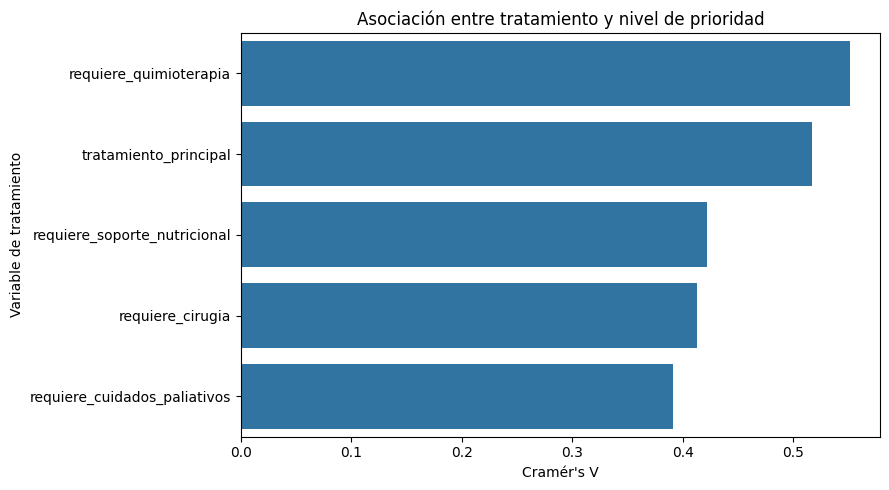

In [144]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=df_cramers_tratamiento,
    x="cramers_v",
    y="variable"
)
plt.title("Asociación entre tratamiento y nivel de prioridad")
plt.xlabel("Cramér's V")
plt.ylabel("Variable de tratamiento")
plt.tight_layout()
plt.savefig("eda_16_cramers_tratamiento_prioridad.png", dpi=300, bbox_inches="tight")
plt.show()

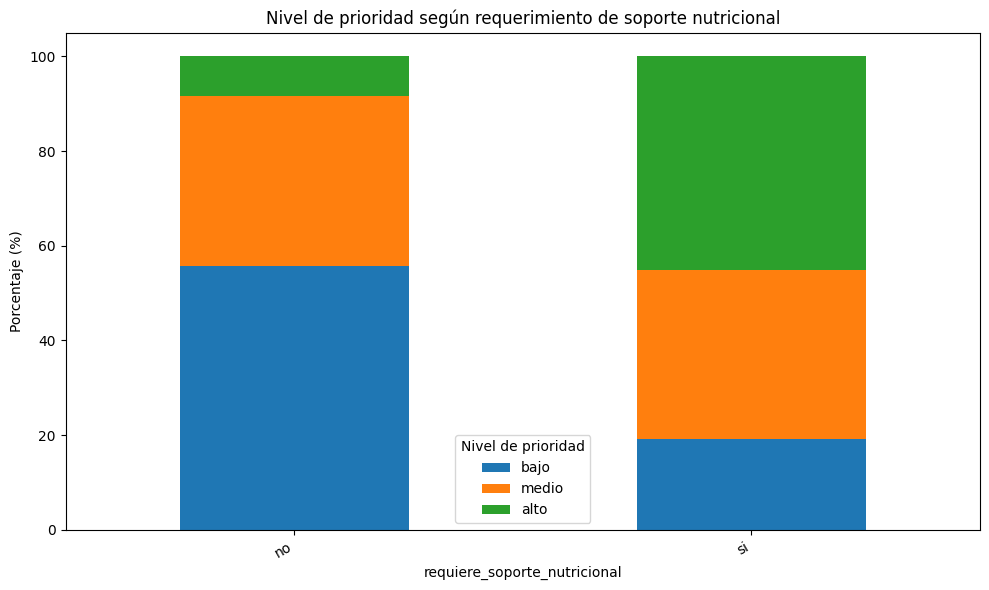

In [145]:
grafico_bivariado_apilado(
    df=df_eda,
    variable="requiere_soporte_nutricional",
    titulo="Nivel de prioridad según requerimiento de soporte nutricional",
    nombre_archivo="eda_16_soporte_nutricional_vs_prioridad.png",
    orden_filas=["no", "si"]
)

## Análisis de la Etapa 16

El análisis bivariado de tratamiento muestra que las variables asociadas al manejo clínico tienen una relación importante con nivel_prioridad.

La variable con mayor asociación fue requiere_quimioterapia, con Cramér’s V = 0.551. Esto indica una relación fuerte. Los pacientes que no requieren quimioterapia se concentran principalmente en prioridad baja (53.90%), mientras que quienes sí la requieren tienen mayor presencia de prioridad alta (52.57%) y media (42.28%).

tratamiento_principal también presenta una asociación fuerte, con Cramér’s V = 0.517. Los casos de cirugia y seguimiento se relacionan más con prioridad baja, mientras que quimioterapia y cuidados_paliativos se asocian más con prioridad alta. Por ejemplo, en cuidados_paliativos, el 79.17% corresponde a prioridad alta.

requiere_soporte_nutricional tiene una asociación moderada-fuerte, con Cramér’s V = 0.422. Cuando el paciente no requiere soporte nutricional, predomina la prioridad baja (55.66%). En cambio, cuando sí lo requiere, la prioridad alta sube a 45.06%.

requiere_cirugia tiene Cramér’s V = 0.413. Esto es interesante: los pacientes que sí requieren cirugía tienen más prioridad baja o media, mientras que los que no requieren cirugía tienen mayor proporción de prioridad alta (56.62%). Esto tiene sentido porque muchos casos avanzados o paliativos ya no son candidatos principales a cirugía curativa.

requiere_cuidados_paliativos presenta Cramér’s V = 0.391. Los pacientes con cuidados paliativos no tienen prioridad baja y se concentran principalmente en prioridad alta (79.17%).

Las variables de tratamiento tienen una relación clara con el nivel_prioridad, especialmente requiere_quimioterapia, tratamiento_principal, requiere_soporte_nutricional, requiere_cirugia y requiere_cuidados_paliativos. Esto confirma que la prioridad no solo depende del estadio clínico, sino también del tipo de intervención que el paciente necesita.

## 17. Análisis bivariado demográfico-social vs nivel_prioridad

In [146]:

orden_prioridad = ["bajo", "medio", "alto"]

variables_sociales_bivariadas = [
    "grupo_edad",
    "sexo",
    "zona_procedencia",
    "viaja_desde_provincia",
    "acompanante",
    "nivel_vulnerabilidad",
    "dificultad_acceso_salud"
]

print("--- VARIABLES DEMOGRÁFICAS Y SOCIALES PARA ANÁLISIS BIVARIADO ---")
print(variables_sociales_bivariadas)

--- VARIABLES DEMOGRÁFICAS Y SOCIALES PARA ANÁLISIS BIVARIADO ---
['grupo_edad', 'sexo', 'zona_procedencia', 'viaja_desde_provincia', 'acompanante', 'nivel_vulnerabilidad', 'dificultad_acceso_salud']


In [147]:
def tabla_cruzada_porcentual(df, variable, objetivo="nivel_prioridad", orden_filas=None):
    serie_variable = df[variable].astype("object").fillna("desconocido")

    tabla = pd.crosstab(
        serie_variable,
        df[objetivo],
        normalize="index"
    ) * 100

    tabla = tabla.reindex(columns=orden_prioridad)

    if orden_filas is not None:
        filas_existentes = [fila for fila in orden_filas if fila in tabla.index]
        tabla = tabla.reindex(filas_existentes)

    return tabla.round(2)


ordenes_sociales = {
    "grupo_edad": ["nino_adolescente", "adulto_joven", "adulto", "adulto_mayor"],
    "sexo": ["femenino", "masculino"],
    "zona_procedencia": ["costa", "sierra", "selva"],
    "viaja_desde_provincia": ["no", "si"],
    "acompanante": ["no", "si"],
    "nivel_vulnerabilidad": ["medio", "alto", "muy_alto"],
    "dificultad_acceso_salud": ["baja", "media", "alta"]
}

for col in variables_sociales_bivariadas:
    print(f"\n--- Distribución porcentual de nivel_prioridad según {col} ---")
    display(
        tabla_cruzada_porcentual(
            df=df_eda,
            variable=col,
            objetivo="nivel_prioridad",
            orden_filas=ordenes_sociales.get(col)
        )
    )


--- Distribución porcentual de nivel_prioridad según grupo_edad ---


nivel_prioridad,bajo,medio,alto
grupo_edad,,,
nino_adolescente,21.95,40.24,37.80
adulto_joven,30.78,32.52,36.70
adulto,30.73,37.74,31.53
adulto_mayor,30.40,35.89,33.71



--- Distribución porcentual de nivel_prioridad según sexo ---


nivel_prioridad,bajo,medio,alto
sexo,,,
femenino,30.17,36.84,32.98
masculino,30.61,34.85,34.54



--- Distribución porcentual de nivel_prioridad según zona_procedencia ---


...

nivel_prioridad,bajo,medio,alto
acompanante,,,
no,26.78,37.13,36.09
si,31.06,35.56,33.38



--- Distribución porcentual de nivel_prioridad según nivel_vulnerabilidad ---


nivel_prioridad,bajo,medio,alto
nivel_vulnerabilidad,,,
medio,34.87,30.50,34.62
alto,29.16,36.87,33.97
muy_alto,28.58,38.74,32.68



--- Distribución porcentual de nivel_prioridad según dificultad_acceso_salud ---


nivel_prioridad,bajo,medio,alto
dificultad_acceso_salud,,,
baja,33.87,32.12,34.01
media,32.58,34.21,33.21
alta,27.30,38.41,34.29


In [148]:
def grafico_bivariado_apilado(df, variable, titulo, nombre_archivo, orden_filas=None):
    serie_variable = df[variable].astype("object").fillna("desconocido")

    tabla = pd.crosstab(
        serie_variable,
        df["nivel_prioridad"],
        normalize="index"
    ) * 100

    tabla = tabla.reindex(columns=orden_prioridad)

    if orden_filas is not None:
        filas_existentes = [fila for fila in orden_filas if fila in tabla.index]
        tabla = tabla.reindex(filas_existentes)

    tabla.plot(kind="bar", stacked=True, figsize=(10, 6))

    plt.title(titulo)
    plt.xlabel(variable)
    plt.ylabel("Porcentaje (%)")
    plt.legend(title="Nivel de prioridad")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig(nombre_archivo, dpi=300, bbox_inches="tight")
    plt.show()

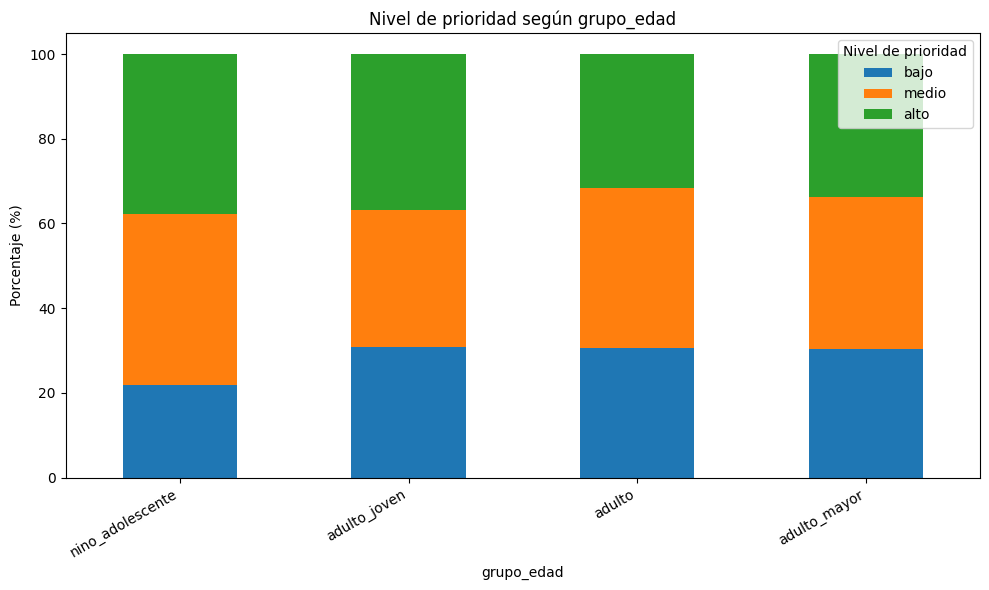

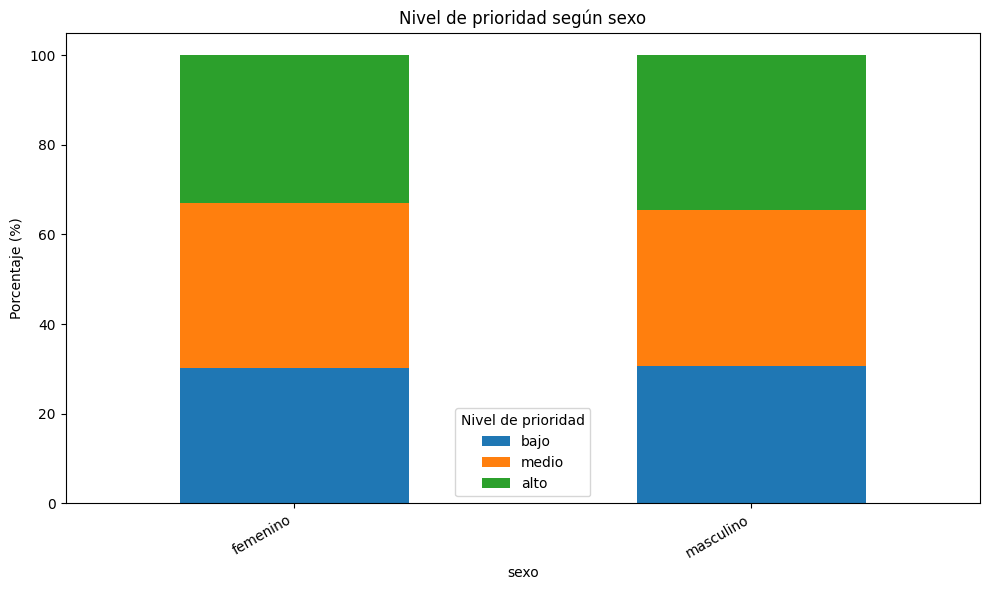

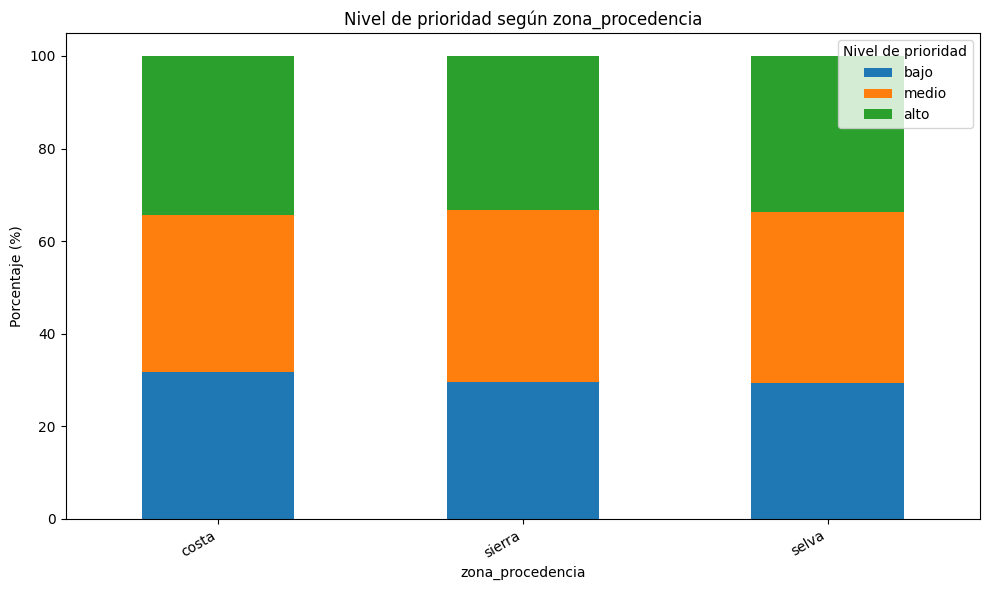

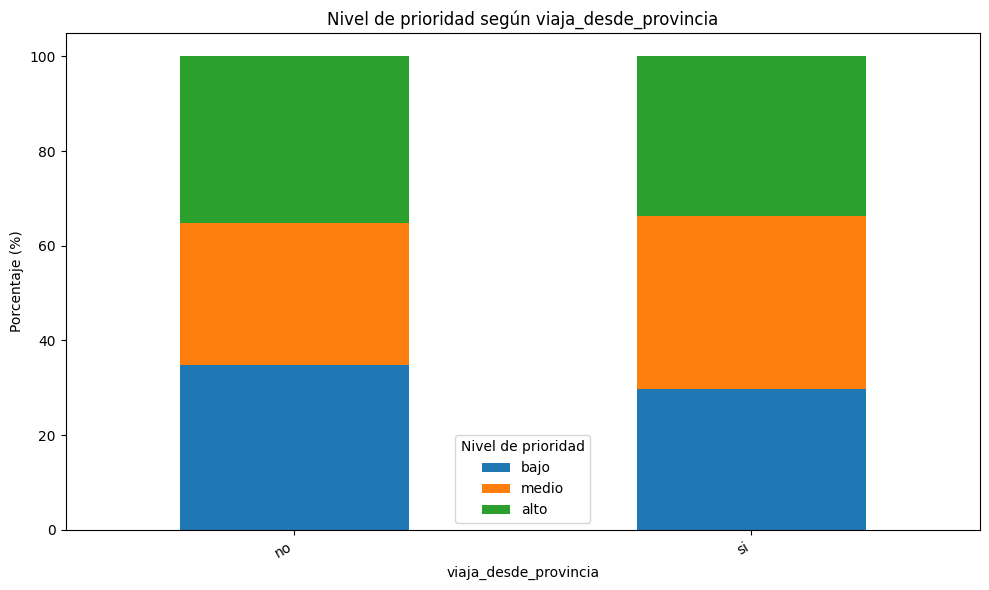

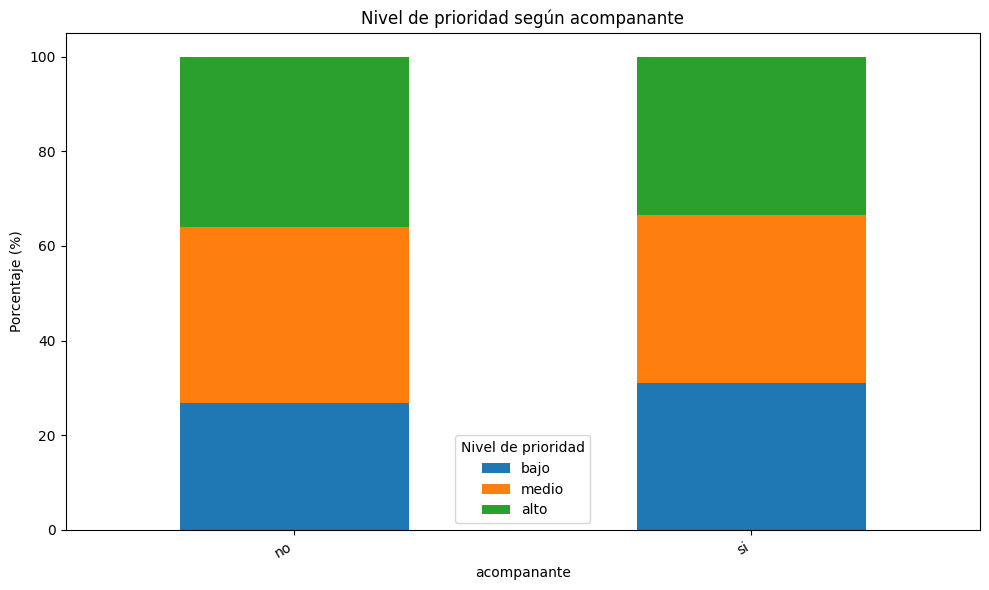

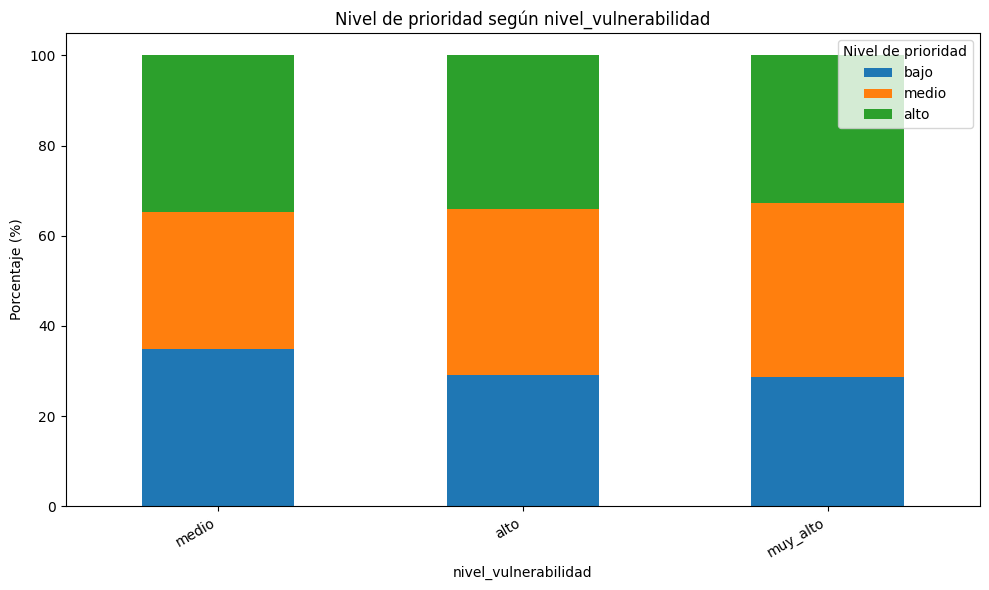

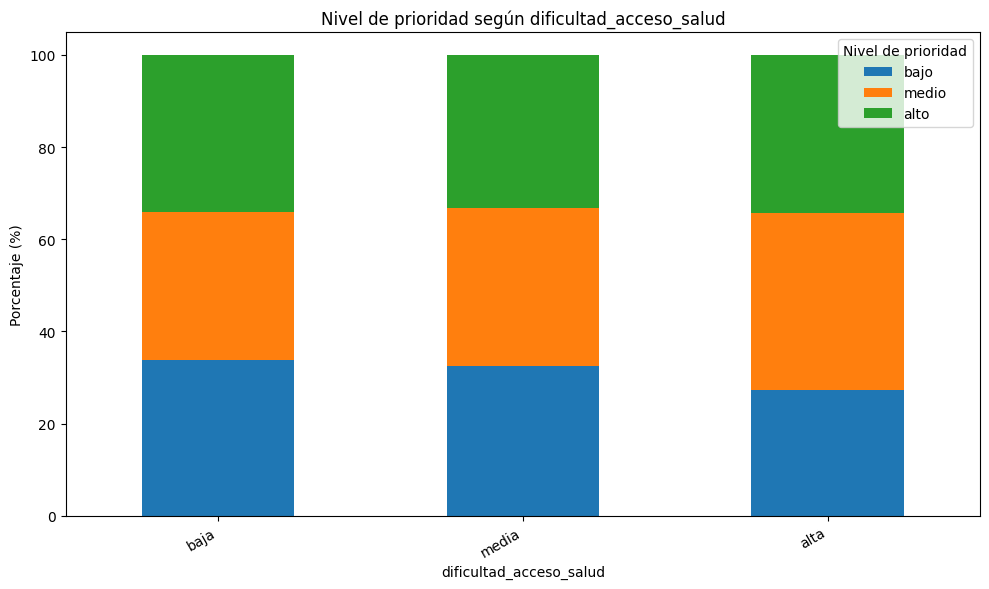

In [149]:
for col in variables_sociales_bivariadas:
    grafico_bivariado_apilado(
        df=df_eda,
        variable=col,
        titulo=f"Nivel de prioridad según {col}",
        nombre_archivo=f"eda_17_{col}_vs_prioridad.png",
        orden_filas=ordenes_sociales.get(col)
    )

In [150]:
def cramers_v(x, y):
    tabla = pd.crosstab(x, y)
    chi2 = chi2_contingency(tabla)[0]
    n = tabla.sum().sum()
    r, k = tabla.shape

    if n == 0 or min(k - 1, r - 1) == 0:
        return np.nan

    return np.sqrt((chi2 / n) / min(k - 1, r - 1))


resultados_cramers_sociales = []

for col in variables_sociales_bivariadas:
    x = df_eda[col].astype("object").fillna("desconocido")
    y = df_eda["nivel_prioridad"]

    resultados_cramers_sociales.append({
        "variable": col,
        "cramers_v": round(cramers_v(x, y), 3)
    })

df_cramers_sociales = pd.DataFrame(resultados_cramers_sociales).sort_values(
    by="cramers_v",
    ascending=False
)

display(df_cramers_sociales)

,variable,cramers_v
5,nivel_vulnerabilidad,0.050
3,viaja_desde_provincia,0.048
6,dificultad_acceso_salud,0.047
4,acompanante,0.034
0,grupo_edad,0.032
2,zona_procedencia,0.024
1,sexo,0.022


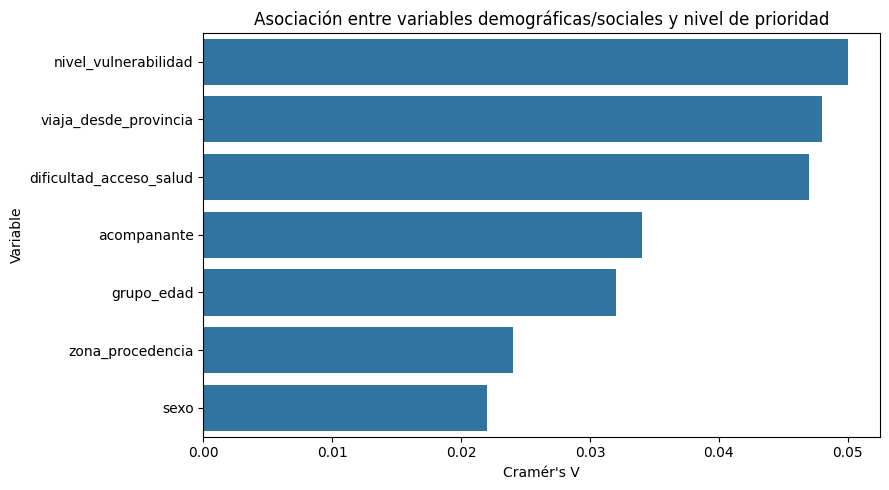

In [151]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=df_cramers_sociales,
    x="cramers_v",
    y="variable"
)
plt.title("Asociación entre variables demográficas/sociales y nivel de prioridad")
plt.xlabel("Cramér's V")
plt.ylabel("Variable")
plt.tight_layout()
plt.savefig("eda_17_cramers_sociales_prioridad.png", dpi=300, bbox_inches="tight")
plt.show()

## Análisis de la Etapa 17

El análisis bivariado demográfico-social muestra que las distribuciones de nivel_prioridad son muy parecidas entre categorías. Por ejemplo, en sexo, tanto femenino como masculino tienen porcentajes similares de prioridad baja, media y alta. Lo mismo ocurre con zona_procedencia, donde costa, sierra y selva presentan proporciones bastante cercanas.

La variable social con mayor asociación fue nivel_vulnerabilidad, con Cramér’s V = 0.050, seguida por viaja_desde_provincia con 0.048 y dificultad_acceso_salud con 0.047. Sin embargo, estos valores son muy bajos, por lo que la asociación se considera débil o casi nula.

Esto no significa que las variables sociales no importen para ALDIMI. Sí importan para entender el contexto de vulnerabilidad del paciente, pero en este dataset no son las que más explican la prioridad clínica. La prioridad está mucho más relacionada con variables como estadio, metástasis, anemia, estado funcional, dolor, quimioterapia y tratamiento principal.

El análisis bivariado entre las variables demográficas/sociales y el nivel de prioridad evidenció asociaciones débiles. Los valores de Cramér’s V fueron bajos en todas las variables evaluadas, siendo los más altos nivel_vulnerabilidad (0.050), viaja_desde_provincia (0.048) y dificultad_acceso_salud (0.047). Esto indica que, dentro del dataset sintético, la prioridad de atención no está determinada principalmente por características demográficas o sociales, sino por variables clínicas, síntomas, estado del paciente y tratamiento requerido.

Este resultado es importante porque permite diferenciar el rol de las variables sociales: estas ayudan a contextualizar la vulnerabilidad y la situación del paciente atendido por ALDIMI, pero no dominan la clasificación del nivel de prioridad. Por tanto, para el modelo predictivo, estas variables pueden mantenerse como variables complementarias, mientras que las variables clínicas y de tratamiento deben considerarse como predictores principales.

## 18. Ranking global de variables asociadas al nivel de prioridad

In [152]:
orden_prioridad = ["bajo", "medio", "alto"]

def cramers_v(x, y):
    tabla = pd.crosstab(x, y)
    chi2 = chi2_contingency(tabla)[0]
    n = tabla.sum().sum()
    r, k = tabla.shape

    if n == 0 or min(k - 1, r - 1) == 0:
        return np.nan

    return np.sqrt((chi2 / n) / min(k - 1, r - 1))

In [153]:
variables_clinicas_cat = [
    "tipo_histologico",
    "estadio",
    "grado_histologico",
    "profundidad_tumor",
    "metastasis",
    "sitio_metastasis"
]

variables_sintomas_cat = [
    "estado_nutricional",
    "anemia",
    "dolor",
    "vomitos_frecuentes",
    "sangrado_digestivo",
    "fatiga",
    "dificultad_alimentarse",
    "comorbilidades",
    "estado_funcional"
]

variables_tratamiento_cat = [
    "requiere_cirugia",
    "requiere_quimioterapia",
    "requiere_soporte_nutricional",
    "requiere_cuidados_paliativos",
    "tratamiento_principal"
]

variables_sociales_cat = [
    "grupo_edad",
    "sexo",
    "zona_procedencia",
    "viaja_desde_provincia",
    "acompanante",
    "nivel_vulnerabilidad",
    "dificultad_acceso_salud"
]

In [154]:
resultados_cramers_global = []

grupos_variables = {
    "Clínico-oncológicas": variables_clinicas_cat,
    "Síntomas y estado del paciente": variables_sintomas_cat,
    "Tratamiento": variables_tratamiento_cat,
    "Demográficas y sociales": variables_sociales_cat
}

for grupo, variables in grupos_variables.items():
    for col in variables:
        x = df_eda[col].astype("object").fillna("desconocido")
        y = df_eda["nivel_prioridad"]

        resultados_cramers_global.append({
            "grupo": grupo,
            "variable": col,
            "cramers_v": round(cramers_v(x, y), 3)
        })

df_cramers_global = pd.DataFrame(resultados_cramers_global).sort_values(
    by="cramers_v",
    ascending=False
)

display(df_cramers_global)

,grupo,variable,cramers_v
1,Clínico-oncológicas,estadio,0.856
3,Clínico-oncológicas,profundidad_tumor,0.650
16,Tratamiento,requiere_quimioterapia,0.551
19,Tratamiento,tratamiento_principal,0.517
7,Síntomas y estado del paciente,anemia,0.508
14,Síntomas y estado del paciente,estado_funcional,0.499
4,Clínico-oncológicas,metastasis,0.494
8,Síntomas y estado del paciente,dolor,0.437
17,Tratamiento,requiere_soporte_nutricional,0.422
15,Tratamiento,requiere_cirugia,0.413


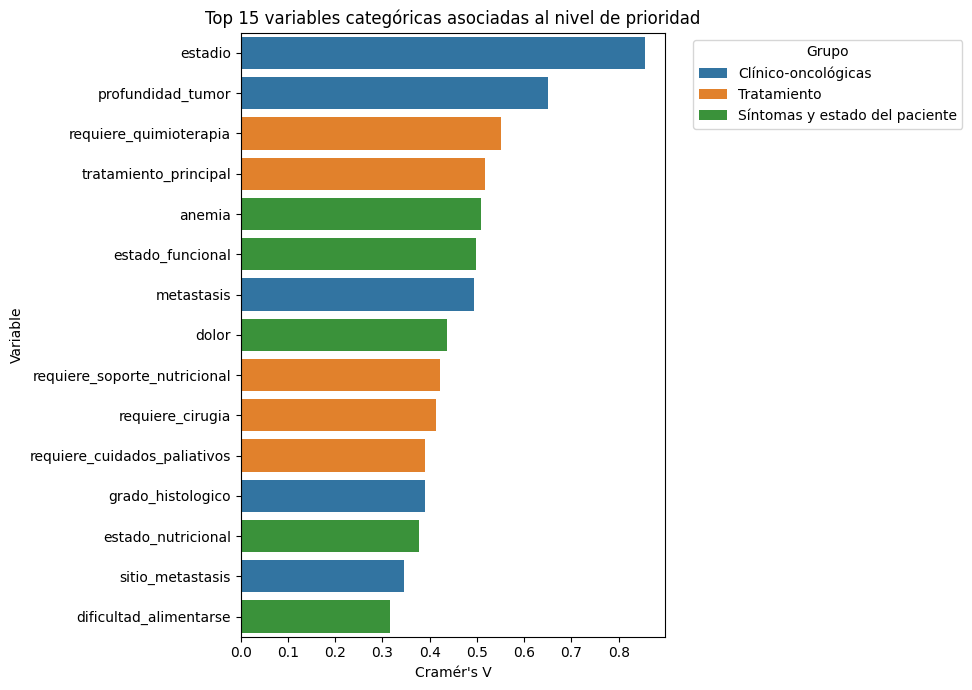

In [155]:
top_cramers = df_cramers_global.head(15)

plt.figure(figsize=(10, 7))
sns.barplot(
    data=top_cramers,
    x="cramers_v",
    y="variable",
    hue="grupo"
)

plt.title("Top 15 variables categóricas asociadas al nivel de prioridad")
plt.xlabel("Cramér's V")
plt.ylabel("Variable")
plt.legend(title="Grupo", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("eda_18_top_variables_categoricas_cramers.png", dpi=300, bbox_inches="tight")
plt.show()

In [156]:
def eta_squared_numeric_target(df, numeric_col, target_col):
    temp = df[[numeric_col, target_col]].dropna()

    grand_mean = temp[numeric_col].mean()

    ss_between = 0
    for clase, grupo in temp.groupby(target_col):
        n_grupo = len(grupo)
        mean_grupo = grupo[numeric_col].mean()
        ss_between += n_grupo * (mean_grupo - grand_mean) ** 2

    ss_total = ((temp[numeric_col] - grand_mean) ** 2).sum()

    if ss_total == 0:
        return np.nan

    return ss_between / ss_total

In [157]:
variables_numericas = [
    "dias_desde_diagnostico",
    "dias_en_albergue",
    "edad",
    "ganglios_afectados",
    "perdida_peso_kg",
    "hemoglobina"
]

resultados_eta = []

for col in variables_numericas:
    resultados_eta.append({
        "variable": col,
        "eta_squared": round(eta_squared_numeric_target(df_eda, col, "nivel_prioridad"), 3)
    })

df_eta_numericas = pd.DataFrame(resultados_eta).sort_values(
    by="eta_squared",
    ascending=False
)

display(df_eta_numericas)

,variable,eta_squared
3,ganglios_afectados,0.561
4,perdida_peso_kg,0.439
5,hemoglobina,0.318
1,dias_en_albergue,0.005
0,dias_desde_diagnostico,0.002
2,edad,0.000


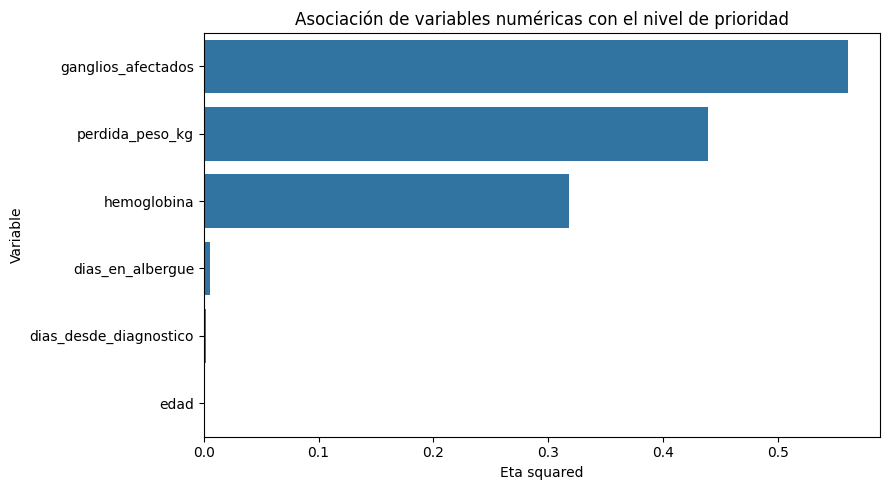

In [158]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=df_eta_numericas,
    x="eta_squared",
    y="variable"
)

plt.title("Asociación de variables numéricas con el nivel de prioridad")
plt.xlabel("Eta squared")
plt.ylabel("Variable")
plt.tight_layout()
plt.savefig("eda_18_variables_numericas_eta_squared.png", dpi=300, bbox_inches="tight")
plt.show()

In [159]:
df_cramers_global.to_csv("eda_18_cramers_global.csv", index=False)
df_eta_numericas.to_csv("eda_18_eta_numericas.csv", index=False)

print("Archivos generados:")
print("- eda_18_cramers_global.csv")
print("- eda_18_eta_numericas.csv")
print("- eda_18_top_variables_categoricas_cramers.png")
print("- eda_18_variables_numericas_eta_squared.png")

Archivos generados:
- eda_18_cramers_global.csv
- eda_18_eta_numericas.csv
- eda_18_top_variables_categoricas_cramers.png
- eda_18_variables_numericas_eta_squared.png


## Interpretación de la Etapa 18

El ranking global confirma que las variables más relacionadas con `nivel_prioridad` son principalmente **clínico-oncológicas**, de **tratamiento** y de **estado del paciente**. En las variables categóricas, la asociación más alta fue `estadio` con **Cramér’s V = 0.856**, seguida por `profundidad_tumor` con **0.650**, `requiere_quimioterapia` con **0.551**, `tratamiento_principal` con **0.517**, `anemia` con **0.508**, `estado_funcional` con **0.499** y `metastasis` con **0.494**. Esto confirma que la prioridad de atención está dominada por el avance clínico de la enfermedad, el deterioro funcional y los requerimientos terapéuticos.

En las variables numéricas, las más relevantes fueron:

| Variable numérica        | Eta squared | Interpretación                |
| ------------------------ | ----------: | ----------------------------- |
| `ganglios_afectados`     |       0.561 | Asociación alta con prioridad |
| `perdida_peso_kg`        |       0.439 | Asociación moderada-alta      |
| `hemoglobina`            |       0.318 | Asociación moderada           |
| `dias_en_albergue`       |       0.005 | Asociación casi nula          |
| `dias_desde_diagnostico` |       0.002 | Asociación casi nula          |
| `edad`                   |       0.000 | Sin asociación relevante      |

Esto significa que los pacientes con mayor prioridad tienden a presentar **más ganglios afectados**, **mayor pérdida de peso** y **menor nivel de hemoglobina**. En cambio, la edad y los días desde el diagnóstico casi no explican el nivel de prioridad en este dataset.

